# Install packages

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the four methods

In [17]:
from math import isnan
# moving average vrossover
def moving_avarage_cross_over(data_frame, name, short_window=25, long_window=100):
    data_frame = data_frame.copy()

    # windows
    long_window_text = "_" + str(long_window)
    short_window_text = "_" + str(short_window)

    # string to add after each key in frame for just thishyperparameters
    combine_str = short_window_text + long_window_text

    # windows
    data_frame[name + '_MA_short' + combine_str] = data_frame[name].rolling(window=short_window).mean()
    data_frame[name + '_MA_long' + combine_str] = data_frame[name].rolling(window=long_window).mean()

    # buy or sell signal
    data_frame[name + '_signal' + combine_str] = 0

    # trade can be valid
    valid = data_frame[name + '_MA_long' + combine_str].notna()

    # buy signal
    data_frame.loc[valid & (data_frame[name+'_MA_short' + combine_str] >= data_frame[name+'_MA_long' + combine_str]), name + '_signal' + combine_str] = 1

    # sell signal
    data_frame.loc[valid & (data_frame[name+'_MA_short' + combine_str] < data_frame[name+'_MA_long' + combine_str]), name + '_signal' + combine_str] = -1

    # position is the difference
    data_frame[name+'_position' + combine_str] = data_frame[name+'_signal' + combine_str].diff()

    # drop some columns to decrease the size
    data_frame = data_frame.drop(columns=[name + '_MA_short' + combine_str,  name + '_MA_long' + combine_str])

    #return the new frame
    return data_frame

# a version of channal breakout that weren't used
def channal_breakout(data_frame, name, c = 0.05, d = 3, k = 5, x = 0.03, j = 20, combine_str = "_none"):
    data_frame = data_frame.copy()

    # look at the high and low in a window of j days that is at least d days ago
    high = data_frame[name].shift(d).rolling(window= j).max()
    low = data_frame[name].shift(d).rolling(window= j).min()

    # check if channal exist and then add channals
    channal_exist = (high <= low * (1 + c))
    upper = high * (1 + x)
    lower = low * (1 - x)

    # look at max and min prices in the last d days
    lag_min = data_frame[name].rolling(window = d).min()
    lag_max = data_frame[name].rolling(window = d).max()

    # defune if long signal or short signal
    _long = (lag_min > upper) & channal_exist
    _short = (lag_max < lower) & channal_exist

    # frame with nans as true
    nan_Frame = data_frame[name].isna().fillna(False)

    # check so frame dosn't contain nans
    bad = nan_Frame.rolling(window = d + j, min_periods=1).max()
    _valid_breakouts = bad.eq(0).fillna(False)

    # create signal and convert arrays to np arrays
    _signal = np.zeros(len(data_frame[name]))
    nan_Frame = nan_Frame.to_numpy()
    _valid_breakouts = _valid_breakouts.to_numpy()
    _long = _long.to_numpy()
    _short = _short.to_numpy()

    # loop throught all values and set signal to -1 if not nan
    for i in range(d + j, len(data_frame[name])):
      if not (nan_Frame[i] == True):
        _signal[i] = -1
    ld = len(data_frame[name])

    # if signal poitive set the next k days (including this) to a buy signal and if short signal sell imediate
    for i in range(d + j, len(data_frame[name]) - 1):
      if _valid_breakouts[i]:
        if _long[i]:
          _signal[i: min(i + k, ld)] = 1
          if i + k < ld:
            _signal[i + k] = -1
        elif _short[i]:
          _signal[i: min(i + k, ld)] = -1
          #if i + k < ld:
          #  _signal[i + k] = 1

    # set if nan net to -1 and 0 if nan
    for i in range(d + j, len(data_frame[name]) - 1):
      if nan_Frame[i]:
        _signal[i] = 0
      elif nan_Frame[i + 1]:
        _signal[i] = -1

    # set the last signal as that one before
    _signal[-1] = _signal[-2]
    #for i in range(_signal.shape[0]):
    #  print(i, _signal[i])


    _signal = _signal.astype(int)

    data_frame[name + '_signal' + combine_str] = _signal

    # get the values of buy and sell signals
    vc = data_frame[name + '_signal' + combine_str].value_counts()
    print(vc.get(-1, 0), vc.get(1, 0))

    #data_frame = data_frame.drop(columns=[name + '_channal_short' + combine_str,  name + '_channal_long' + combine_str, name + '_valid_break_outs' + combine_str])
    return data_frame,  vc.get(1, 0)

# the buy and hold with rebalancing i.e. Constant Mix
def buy_and_hold_signal(data_frame, names, combine_str = "buy_and_hold"):

    # obs
    data_frame = data_frame.copy()
    for name in names:

      # convert to numpy and add a signal
      _signal = np.zeros(len(data_frame[name]))
      _price = data_frame[name].to_numpy()

      _signal[0] = -1

      # add signals to buy if price has been nan and sell if price will be nan
      for i in range(1, len(data_frame) - 1):
        if np.isnan(_price[i]):
          _signal[i] = 0
        elif np.isnan(_price[i + 1]):
          _signal[i] = -1
        elif np.isnan(_price[i - 1]):
          _signal[i] = -1
        else:
          _signal[i] = 1
      _signal[-1] = _signal[-2]
      data_frame[name + '_signal' + combine_str] = _signal

    return data_frame

# buy dip using mean reversion (got very similar but here "binary" signal is used)
def buy_dip(data_frame, names, d, k, max_k, combine_str = "dipen", shift_v = 0):

    data_frame = data_frame.copy()
    for name in  names:

      # check so o unvalid values are in window before of d dats
      # (shift_v=0 but was used to see if we had some data leakage)
      _valid = data_frame[name].shift(shift_v).isna().rolling(window=d).sum().to_numpy() == 0

      # price window before of d days
      _rolling = data_frame[name].shift(shift_v+1).rolling(window=d)

      # prices (observe they are the same but was used to check for data leakage)
      _price = data_frame[name].to_numpy()
      _price1 = data_frame[name].shift(shift_v).to_numpy()

      # set valid false if price now or next dosn't exist
      for i in range(0, len(data_frame) - 1):
        if np.isnan(_price[i]) or np.isnan(_price[i+1]):
          _valid[i] = False

      # get mean and std of the window before of d days
      _avg =  _rolling.mean().to_numpy()
      _std = _rolling.std().to_numpy()

      # set signal if price is below mean - k * std where k is the streangth parameter
      _signal = np.where((_price1 < _avg - k * _std) & _valid, 1, -1)

      print(np.sum(_signal == 1))

      # loop to ckeck continus signal if buy
      buy_now = False
      day_since_buy = 0
      for i in range(0, len(data_frame) - 1):
        # if signal is 1 we have a buy now bool and reset days since buy
        if _signal[i] == 1:
          buy_now = True
          day_since_buy = 0
        else:
          # if any valid is false for this time set signal to 0 and buy now false
          if _valid[i] == False or _valid[i] == False:
            _signal[i] = 0
            buy_now = False
            day_since_buy = 0

          # if price greater than mean in the rolling window set buy sell signal if above mean value
          elif _price1[i] >= _avg[i]:
              _signal[i] = -1
              buy_now = False
              day_since_buy = 0

          # else if we have had a buy signal before but not a new sell signaö
          elif buy_now:
            day_since_buy += 1

            # limit maximum day to held asset if no new buy signal to max_k days
            if day_since_buy > max_k:
              _signal[i] = -1
              buy_now = False
              day_since_buy = 0

            # else set signal to buy
            else:
              _signal[i] = 1

          else:
            # else sell
            _signal[i] = -1

      # add last day and print the amount of days the asset is held
      _signal[-1] = _signal[-2]
      print(np.sum(_signal == 1))
      data_frame[name + '_signal' + combine_str] = _signal

    # return dataframe
    return data_frame

# function to remove the five peaks of 1000
def remove_1000(data_frame, name):
    data_frame = data_frame.copy()
    mask = data_frame[name] == 1000
    idx = np.where(mask)[0]  # positional indices

    # avoid boundary issues
    valid = (idx > 0) & (idx < len(data_frame) - 1)
    idx = idx[valid]

    before = data_frame[name].iloc[idx - 1].to_numpy()
    after  = data_frame[name].iloc[idx + 1].to_numpy()
    print(before, after)
    data_frame.iloc[idx, data_frame.columns.get_loc(name)] = (before + before) / 2

    return data_frame

# function to remove the last 200 days with nans
def remove_last_days(data_frame):
    data_frame = data_frame.copy()
    nan_indicies = data_frame.iloc[5000:]["gurkor"].isna().to_numpy().nonzero()[0]
    nan_first = nan_indicies.min() + 5000
    data_frame = data_frame.iloc[:nan_first]
    return data_frame

# split into training and testing
def training_test_split(data_frame, part_slit=0.8):
    nan_max = len(data_frame)
    nan_min = 0

    split_idx = int(nan_min + (nan_max - nan_min) * part_slit)
    data_frame = data_frame.copy()
    train_df = data_frame.iloc[:split_idx].copy()
    test_df = data_frame.iloc[split_idx:].copy()

    return train_df, test_df

# the trading portfolio algorithms by signal

In [18]:
def get_log_returns(df, names):
  for name in names:
    df[name + "_daily-log-return"] = np.log(df[name]/df[name].shift(1))
  return df

# returns buy, sell and unvalid orders by signal from an asset
def stocks_positions(df, names, combine_str):
  for name in names:
    str_signal = name + "_signal" + combine_str

    str_pos_buy = name + "buy" + combine_str
    str_pos_sell = name + "sell" + combine_str
    str_unvalid_next = name + "unvalid" + combine_str

    signal = df[str_signal]
    pos = signal - signal.shift(1)

    df[str_pos_buy] = np.where(pos == 2, True, False)
    df[str_pos_sell] = np.where(pos == -2, True, False)
    df[str_unvalid_next] = np.where((pos== 1) | (pos == -1), True, False)

  return df

# trading of several stocks
def several_stock_trade(df, names, combine_str, relative_money = 100., rebalancing_interval = None, blanka = False, interest = 1.03, replacing_weight = 1.5, maximum_in_one_stock = 0.5):
  df = df.copy()

  if rebalancing_interval == None:
    rebalancing_interval = len(df)

  # dayly interest of risk free
  interest_per_day = (1.03)**(1/252)

  stocks = len(names)

  prices = df[names].to_numpy()

  buy_days =  df[[name + "buy" + combine_str for name in names]].to_numpy(dtype = np.bool)
  sell_days = df[[name + "sell" + combine_str for name in names]].to_numpy(dtype = np.bool)

  # we dont use shorting here
  if blanka:
    buy_short = df[[name + "buy_short" + combine_str for name in names]].to_numpy(dtype = np.bool)
    sell_short = df[[name + "sell_short" + combine_str for name in names]].to_numpy(dtype = np.bool)

  unvalid_days = df[[name + "unvalid" + combine_str for name in names]].to_numpy(dtype = np.bool)

  value_now = np.zeros(unvalid_days.shape[0])

  # matrix of [day,asset] of values held and last asset is risk free money
  stocks_hold = np.zeros((unvalid_days.shape[0], 1 + stocks))
  stocks_hold[0, stocks] = relative_money

  # trade first day
  stocks_have_now_as_bool = buy_days[0]
  n_stocks_holding = np.sum(stocks_have_now_as_bool.astype(int))

  if n_stocks_holding > 0:
    for j in range(stocks):
      if buy_days[0, j]:
        stocks_hold[1, j] = relative_money/ n_stocks_holding
    stocks_hold[1, stocks] = 0.
  else:
    stocks_hold[1, stocks] = relative_money

  value_now[0] = relative_money

  for i in range(1, len(df) - 1):
    # bool arrays
    stocks_bought = (buy_days[i] & (~unvalid_days[i + 1])) & (~stocks_have_now_as_bool)
    stocks_sold = (sell_days[i] | unvalid_days[i + 1]) & stocks_have_now_as_bool
    stocks_unchanged = (~stocks_bought) & (~stocks_sold) & stocks_have_now_as_bool
    stocks_have_now_as_bool = stocks_bought | stocks_unchanged

    # set as list for assets sold, bought or keept in the portfolio for each day
    stocks_bought_b = stocks_bought.nonzero()[0]
    stocks_sold_b = stocks_sold.nonzero()[0]
    stocks_unchanged_b = stocks_unchanged.nonzero()[0]

    # number of bought, sold annd keept stock in the portfolio and total in portfolio after that day
    n_bought_stocks = len(stocks_bought_b)
    n_sold_stocks = len(stocks_sold_b)
    n_stocks_unchanged = len(stocks_unchanged_b)
    n_stocks_holding = n_stocks_unchanged + n_bought_stocks

    # set the value now at day i to sum of each value from that thay of the assets in the portfolio
    value_now[i] = np.sum(stocks_hold[i, :])
    #print(value_now[i], stocks_bought_b, stocks_sold_b, stocks_unchanged_b, stocks_hold[i])

    # variables to track how much is sold or bought for each day
    value_sold = 0.
    value_bought = 0.

    if n_stocks_holding > 0:
      # if money exist and we hold stocks sell all money
      if stocks_hold[i, stocks] > 0:
        value_sold += stocks_hold[i, stocks]
        stocks_hold[i + 1, stocks] = 0.

      # buy stocks for procentual part
      if n_bought_stocks > 0:
        for j in stocks_bought_b:
            stocks_hold[i + 1, j] = value_now[i] / n_stocks_holding
            value_bought += stocks_hold[i + 1, j]

      #sell socks if signal or to much value of portfolie
      if n_sold_stocks > 0:
        for j in stocks_sold_b:
            value_sold += stocks_hold[i, j]
            stocks_hold[i + 1, j] = 0.

      # maximum value for an asset before rebalancing
      maximum_value_hold = replacing_weight * value_now[i] / n_stocks_holding

      if n_stocks_unchanged > 0:
        for j in stocks_unchanged_b:
          # if money above limit for assets in the portfolio add them to the sell pot
          if stocks_hold[i, j] > maximum_value_hold:
            value_sold += stocks_hold[i, j] - maximum_value_hold
            stocks_hold[i + 1, j] = maximum_value_hold
          else:
            stocks_hold[i + 1, j] = stocks_hold[i, j]

      # the left money add equaly or sell per procent
      rest_money = value_sold - value_bought

      #  if money is left add equal betwween assets
      if rest_money > 0:
        for j in stocks_unchanged_b:
          stocks_hold[i + 1, j] += rest_money / n_stocks_unchanged
      # if money missing remove it betwwen assets by portion of worth
      else:
        capital = 0.
        for j in stocks_unchanged_b:
          capital += stocks_hold[i, j]

        for j in stocks_unchanged_b:
          stocks_hold[i + 1, j] += rest_money * stocks_hold[i, j] / capital

      # rebalancing portfolio folly at intervall rebalancing intervall
      if i % rebalancing_interval == 0:
        for j in range(stocks):
          if stocks_hold[i + 1, j] > 0:
            stocks_hold[i + 1, j] = value_now[i] / n_stocks_holding
          elif stocks_hold[i + 1, j] == 0:
            stocks_hold[i + 1, j] = 0.
          else:
            print("error sss")

        if n_stocks_holding > 0:
          stocks_hold[i + 1, stocks] = 0.
        else:
          stocks_hold[i + 1, stocks] = value_now[i]
    else:
      # have no stocks
      for j in range(stocks):
        stocks_hold[i + 1, j] = 0.
      stocks_hold[i + 1, stocks] = value_now[i]

    # if one stock is overrepresented
    stocks_avalible = np.where(stocks_hold[i + 1, :] > 0, 1, 0).nonzero()[0]
    money_left = 0
    for j in stocks_avalible:
      if stocks_hold[i + 1, j] > maximum_in_one_stock * value_now[i]:
        money_left += stocks_hold[i + 1, j] - maximum_in_one_stock * value_now[i]
        stocks_hold[i + 1, j] = maximum_in_one_stock * value_now[i]

    if money_left > 0:
        stocks_hold[i + 1, stocks] += money_left

    # add interests and returns
    for j in range(stocks):
      if stocks_hold[i + 1, j] < 0:
        print("error")
        stocks_hold[i + 1, j] = 0.
      if (np.isnan(prices[i + 1, j])) or (np.isnan(prices[i, j])):
        stocks_hold[i + 1, stocks] += stocks_hold[i + 1, j]
        stocks_hold[i + 1, j] = 0.
      else:
        stocks_hold[i + 1, j] *= prices[i + 1, j] / prices[i, j]
    stocks_hold[i + 1, stocks] *= interest_per_day

  # sum value at end day
  value_now[-1] = np.sum(stocks_hold[-1, :])

  # add how much many of each stock is held at each time
  for j, name in enumerate(names):
    df[name + "_portfolie_stock" + combine_str] = stocks_hold[:, j]

  # add riskfree money and total value
  df["portfolie_money" + combine_str] = stocks_hold[:, stocks]
  df["portfolie_value" + combine_str] = value_now

  return df

# sharp ratios

In [19]:
# get real sharp ratio (annual if intervall = 252)
def get_sharpe_ratio(df, intervall=252, combine_str = None, weighting = "equal", renta = 1.03):
  df = df.copy()

  values = df["portfolie_value" + combine_str]
  cost_rent = 1.03 ** (intervall/252) - 1
  returns = (values/values.shift(intervall)).dropna() - 1 - cost_rent

  print("\t\t\t", np.mean(returns), np.std(returns))

  return np.mean(returns) / np.std(returns)

# same but with mean and std outputs also
def get_sharpe_ratio_v2(df, intervall=252, combine_str = None, weighting = "equal", renta = 1.03):
  df = df.copy()

  values = df["portfolie_value" + combine_str]
  cost_rent = 1.03 ** (intervall/252) - 1
  returns = (values/values.shift(intervall)).dropna() - 1 - cost_rent

  print("\t\t\t", np.mean(returns), np.std(returns))

  return np.mean(returns) / np.std(returns), np.mean(returns), np.std(returns)

# sharp ratio but for one stock and remove onvalid days
def get_sharpe_ratio_one_stock(df, name, intervall=252, combine_str = None, weighting = "equal", renta = 1.03):
  df = df.copy()
  unvalid = df[name + "unvalid" + combine_str]
  ok = ~(unvalid | unvalid.shift(intervall))

  values = df[name + "_portfolie_ind_value" + combine_str]

  cost_rent = 1.03 ** (intervall/252) - 1

  returns = (values[ok]/values[ok].shift(intervall)).dropna() - 1 - cost_rent

  print("\t\t\t", np.mean(returns), np.std(returns))#, returns)

  return np.mean(returns) / np.std(returns)

# One asset (stock) trading

In [20]:
def one_stock_trade(df, name, combine_str, relative_money = 100., rebalancing_interval = None, balnka = False, interest = 1.03):
  df = df.copy()
  if rebalancing_interval == None:
    rebalancing_interval = len(df)

  interest_per_day = (1.03)**(1/252)

  prices = df[name].to_numpy()

  buy_days =  df[name + "buy" + combine_str].to_numpy(dtype = np.bool)
  sell_days = df[name + "sell" + combine_str].to_numpy(dtype = np.bool)

  unvalid_days = df[name + "unvalid" + combine_str].to_numpy(dtype = np.bool)

  value_now = np.zeros(unvalid_days.shape[0])

  stocks_hold = np.zeros((unvalid_days.shape[0], 1 + 1))

  stocks_hold[0, 1] = relative_money

  if buy_days[0]:
    stocks_hold[1, 0] = relative_money
    stocks_hold[1, 1] = 0
  else:
    stocks_hold[1, 1] = relative_money

  value_now[0] = relative_money

  for i in range(1, len(df) - 1):
    stocks_bought = buy_days[i] and (not unvalid_days[i + 1])
    stocks_sold = (sell_days[i] or unvalid_days[i + 1])

    value_now[i] = stocks_hold[i, 0] + stocks_hold[i, 1]

    # change position in portfolio according to signals
    if stocks_sold:
      stocks_hold[i + 1, 1] = value_now[i]
      stocks_hold[i + 1, 0] = 0
    if stocks_bought:
      stocks_hold[i + 1, 0] = value_now[i]
      stocks_hold[i + 1, 1] = 0
    else:
      stocks_hold[i + 1, 0] = stocks_hold[i, 0]
      stocks_hold[i + 1, 1] = stocks_hold[i, 1]

    # add interests and returns
    if stocks_hold[i + 1, 0] < 0:
        print("error")
        stocks_hold[i + 1, 0] = 0
    if (np.isnan(prices[i + 1])) or (np.isnan(prices[i])):
      stocks_hold[i + 1, 1] = value_now[i]
      stocks_hold[i + 1, 0] = 0
    else:
      stocks_hold[i + 1, 0] *= prices[i + 1] / prices[i]

    stocks_hold[i + 1, 1] *= interest_per_day

  value_now[-1] = stocks_hold[-1, 0] + stocks_hold[-1, 1]

  df[name + "_portfolie_ind_stock" + combine_str] = stocks_hold[:, 0]
  df[name + "_portfolie_ind_money" + combine_str] = stocks_hold[:, 1]
  df[name + "_portfolie_ind_value" + combine_str] = value_now

  return df

# code for plotting the timeseries

In [21]:
def plot_time_series(days, data, sharp_ratio = 0, average_return = 0, avg_std=0, title_s="s", dec=True):
  fig = plt.figure(figsize=(14,5))
  gs = fig.add_gridspec(1,1,height_ratios = [3], hspace = 0.4)

  fig.suptitle(title_s, fontsize=18)
  if dec:
    sharp_text = (f"Trading on 1052 days after training on the first 4204 days.\n Allowing shorting = False. Sharpe-ratio (annualized): {sharp_ratio:.4f}.\n Average return (annulized): {0.03+average_return:.2%}. Average standard deviation (annulized): {avg_std:.2%}.")
  else:
    sharp_text = (f"Trading on the last 1052 days.\n Allowing shorting = False. Sharpe-ratio (annualized): {sharp_ratio:.4f}.\n Average return (annulized): {0.03+average_return:.2%}. Average standard deviation (annulized): {avg_std:.2%}.")

  fig.text(0.5, 0.9, sharp_text, fontsize = 12, ha = "center", va = "top", multialignment = "center", bbox = dict(facecolor = "lightblue",edgecolor = "black", boxstyle = "round,pad=0.5"))

  ax = fig.add_subplot(gs[0])
  ax.set_position([0.06, 0.08, 0.91, 0.55])
  ax.plot(days, data, label = "Strategy portfolio value", linewidth = 2)
  risk_free = data[0] * np.exp(0.03/252 * (days-days[0]))
  ax.plot(days, risk_free, label = "Risk - free asset", linestyle = "--", linewidth = 2)
  ax.set_title("Portfolio value against risk-free asset")
  ax.legend()
  ax.grid(True)
  ax.set_xlabel("Days")
  ax.set_ylabel("Value")
  plt.show()
def plot_time_series_v2(days_v, data_v, days_t, data_t, sharp_ratio = 0, average_return = 0, avg_std=0, title_s="s"):
  fig = plt.figure(figsize=(14,5))
  gs = fig.add_gridspec(1,1,height_ratios = [3], hspace = 0.4)

  fig.suptitle(title_s, fontsize=18)
  sharp_text = (f"Visualize both Training and Trading. Trading on 1052 days, after training on the first 4204 days.\n Allowing shorting = False. Sharpe-ratio (annualized): {sharp_ratio:.4f}.\n Average return (annulized): {0.03+average_return:.2%}. Average standard deviation (annulized): {avg_std:.2%}.")

  fig.text(0.5, 0.9, sharp_text, fontsize = 12, ha = "center", va = "top", multialignment = "center", bbox = dict(facecolor = "lightblue",edgecolor = "black", boxstyle = "round,pad=0.5"))

  ax = fig.add_subplot(gs[0])
  ax.set_position([0.06, 0.08, 0.91, 0.55])
  ax.plot(days_v, data_v, label = "Strategy portfolio value training", color="tab:blue", linewidth = 2)
  risk_free = data_v[0] * np.exp(0.03/252 * (np.arange(days_v[0], days_t[-1], 1)-days_v[0]))

  ax.plot(np.arange(days_v[0], days_t[-1], 1), risk_free, label = "Risk - free asset", linestyle = "--", color="tab:orange", linewidth = 2)
  ax.plot(days_t, data_v[-1]* data_t, label = "Strategy portfolio value trading", color="tab:red", linewidth = 2)

  ax.set_title("Portfolio value against risk-free asset")
  ax.legend()
  ax.grid(True)
  ax.set_xlabel("Days")
  ax.set_ylabel("Value")
  plt.show()

# Code for all the methods
with names of assets and split training and trading romve spikes, remove last nans and to get the methods

In [5]:
finance_data = pd.read_csv('spiff_data-2.csv')
finance_names = finance_data.keys()[2:].to_list()
print(finance_data)

      Unnamed: 0   day    gurkor   guitars  slingshots     stocks     sugar  \
0              0     1  6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2  6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3  6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4  6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5  6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...       ...       ...         ...        ...       ...   
5451        5451  5452       NaN       NaN         NaN        NaN       NaN   
5452        5452  5453       NaN       NaN         NaN        NaN       NaN   
5453        5453  5454       NaN       NaN         NaN        NaN       NaN   
5454        5454  5455       NaN       NaN         NaN        NaN       NaN   
5455        5455  5456       NaN       NaN         NaN        NaN       NaN   

         water  tranquillity  
0     3.896149      

In [6]:
finance_data = remove_last_days(finance_data)

for name in finance_names:
  finance_data = remove_1000(finance_data, name)

print(finance_data)

[ 6.31581555  6.825179    9.27880519  9.05006504 11.37014512] [ 6.26452498  6.85266821  9.181506    9.04200502 11.46444389]
[2.83043642 5.74900107 4.85888389 6.81445677 5.05114593] [2.85406559 5.41987344 4.85304529 6.82222064 4.90162681]
[2.05786636 3.39560267 3.81753475 4.92829802 3.06994825] [2.07016982 3.44239554 3.88330984 4.92515297 3.00913931]
[9.10307757 8.68991977 6.27277201 5.13249983 4.63075894] [8.83745388 8.8367195  6.20489274 5.0972318  4.54038977]
[3.57234686 3.39488235 2.07917243 3.30055146 1.760932  ] [3.64148906 3.23149229 2.07161867 3.30825403 1.72400296]
[3.97410653 4.69767736 5.89565424 6.21961548 6.6929798 ] [3.99621039 4.704141   5.88280296 6.20774392 6.7114342 ]
[ 7.46344565 10.34647171 10.41322314 18.65861411 10.20343293] [ 7.40623013 10.29561348 10.40686586 19.16719644  9.89192626]
      Unnamed: 0   day     gurkor   guitars  slingshots     stocks     sugar  \
0              0     1   6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2

In [7]:
training_data, test_data = training_test_split(finance_data)

In [8]:
print(training_data, test_data)

      Unnamed: 0   day     gurkor   guitars  slingshots     stocks     sugar  \
0              0     1   6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2   6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3   6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4   6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5   6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...        ...       ...         ...        ...       ...   
4199        4199  4200  11.192388  4.746119    2.948472   4.640011  1.771908   
4200        4200  4201  11.206871  4.892829    3.055226   4.570905  1.771908   
4201        4201  4202  11.211216  4.853407    3.052194   4.641266  1.771908   
4202        4202  4203  11.225699  4.913787    3.063112   4.647142  1.771908   
4203        4203  4204  11.147491  4.805002    2.995784   4.586083  1.836662   

         water  tranquillity  
0     3.

#Moving Avarge

First grid search

In [9]:
short_windows = [4, 9, 14, 25, 35, 50]
long_windows = [15, 25, 50, 100, 150, 200]
periods = []

for short_window in short_windows:
  for long_window in long_windows:
    if short_window * 1.5 < long_window:
      periods.append([short_window, long_window])

In [16]:
sharp_ratios_moving_avarge = {}

for short_window, long_window in periods:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_local = training_data.copy()
  for i, name in enumerate(finance_names):
    finance_data_local = moving_avarage_cross_over(finance_data_local, name, short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge[combine_str]}")

short window 4, long window 15 checked
			 -0.008105964010485214 0.08934227783956421
	 sharp ratio portfolie: -0.09072931882307102
short window 4, long window 25 checked
			 0.0010908524873230682 0.08260295464008667
	 sharp ratio portfolie: 0.013205974193974953
short window 4, long window 50 checked
			 0.030058897123313874 0.08001165902810743
	 sharp ratio portfolie: 0.3756814630322118
short window 4, long window 100 checked
			 0.01959328206063385 0.09887391570162485
	 sharp ratio portfolie: 0.19816431787491007
short window 4, long window 150 checked
			 0.022941223696234664 0.10777749595734776
	 sharp ratio portfolie: 0.21285727129264076
short window 4, long window 200 checked
			 0.024626108042040858 0.1083980393902269
	 sharp ratio portfolie: 0.22718222746989217
short window 9, long window 15 checked
			 0.015788220651126384 0.08552966050100558
	 sharp ratio portfolie: 0.18459351479526523
short window 9, long window 25 checked
			 0.012815213742454958 0.08473150401591005
	 sharp r

Order of best parameters by sharp ratios

In [17]:
sorted_d = dict(sorted(sharp_ratios_moving_avarge.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)


_14_50 0.4775674800457968
_9_100 0.42075658093811197
_9_50 0.4147494091563059
_14_200 0.38580598149025974
_14_150 0.37642344608914124
_4_50 0.3756814630322118
_25_100 0.3667369086002207
_9_150 0.36465997126314587
_25_200 0.35416550209312747
_14_100 0.34252409692324426
_25_50 0.3280099527527087
_25_150 0.32387314390655947
_9_200 0.29540781752258355
_14_25 0.2856413857114374
_35_150 0.2805964372615655
_50_150 0.27150513907797214
_50_200 0.27099788140746517
_35_200 0.23710904405813424
_4_200 0.22718222746989217
_35_100 0.22516819043752923
_4_150 0.21285727129264076
_4_100 0.19816431787491007
_9_15 0.18459351479526523
_9_25 0.151244969522182
_50_100 0.13832638073713746
_4_25 0.013205974193974953
_4_15 -0.09072931882307102


second grid search

In [18]:
short_windows_1 = [10, 15, 20, 25, 30]
long_windows_1 = [35, 40, 50, 60, 70, 80, 90, 100]

periods_1 = []
for short_window in short_windows_1:
  for long_window in long_windows_1:
      periods_1.append([short_window, long_window])

In [19]:
sharp_ratios_moving_avarge_1 = {}

for short_window, long_window in periods_1:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_local = training_data.copy()
  for i, name in enumerate(finance_names):
    finance_data_local = moving_avarage_cross_over(finance_data_local, name, short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_1[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_1[combine_str]}")
#  for name in finance_names:


short window 10, long window 35 checked
			 0.027775745289938338 0.08824312290623776
	 sharp ratio portfolie: 0.31476385212988556
short window 10, long window 40 checked
			 0.03580401794605191 0.09103662740882443
	 sharp ratio portfolie: 0.39329244684410763
short window 10, long window 50 checked
			 0.049613556255472535 0.09031656868624359
	 sharp ratio portfolie: 0.5493295081639803
short window 10, long window 60 checked
			 0.04688057535673851 0.0852339505497301
	 sharp ratio portfolie: 0.5500223215558434
short window 10, long window 70 checked
			 0.04700232249310187 0.09414186540827933
	 sharp ratio portfolie: 0.49927120404147246
short window 10, long window 80 checked
			 0.04146036293327131 0.10063978835042474
	 sharp ratio portfolie: 0.4119679066584238
short window 10, long window 90 checked
			 0.03438702466840963 0.09999839208595429
	 sharp ratio portfolie: 0.34387577591099694
short window 10, long window 100 checked
			 0.043740991765672865 0.09754870948943228
	 sharp ratio

In [20]:
sorted_d = dict(sorted(sharp_ratios_moving_avarge_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)


_10_60 0.5500223215558434
_10_50 0.5493295081639803
_15_50 0.519214219064125
_10_70 0.49927120404147246
_25_35 0.47659017895400807
_15_90 0.4539173479436476
_10_100 0.4484015421076529
_15_40 0.4458122141375478
_25_40 0.44398016337308277
_20_40 0.4431131582629226
_15_60 0.4363078753030307
_20_50 0.4289113868381038
_15_35 0.41319225502865414
_10_80 0.4119679066584238
_30_40 0.40492518821294987
_10_40 0.39329244684410763
_15_70 0.3820115923992974
_30_35 0.3802240703402387
_15_80 0.3675502664283748
_25_100 0.3667369086002207
_10_90 0.34387577591099694
_15_100 0.34311729088444304
_20_35 0.34311490889114565
_20_80 0.33769049229300985
_25_50 0.3280099527527087
_25_90 0.3269456338432122
_20_90 0.3216224556588036
_10_35 0.31476385212988556
_20_100 0.30948215747418434
_20_60 0.30746651056865393
_30_100 0.28172898265889174
_25_70 0.27465079684849736
_30_80 0.26461089035652335
_25_60 0.25356831295895793
_30_90 0.23278897274063584
_25_80 0.23028011458788286
_30_50 0.22635736608916984
_20_70 0.22456

Third gridserach

In [55]:
short_windows_1 = [10, 12, 15, 18, 20]
long_windows_1 = [50, 52, 55, 57, 60]

periods_1 = []
for short_window in short_windows_1:
  for long_window in long_windows_1:
      periods_1.append([short_window, long_window])

In [56]:
sharp_ratios_moving_avarge_1 = {}

for short_window, long_window in periods_1:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_local = training_data.copy()
  for i, name in enumerate(finance_names):
    finance_data_local = moving_avarage_cross_over(finance_data_local, name, short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_1[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_1[combine_str]}")
#  for name in finance_names:


short window 10, long window 50 checked
			 0.049613556255472535 0.09031656868624359
	 sharp ratio portfolie: 0.5493295081639803
short window 10, long window 52 checked
			 0.043715526861102846 0.08949892466633423
	 sharp ratio portfolie: 0.48844750955479144
short window 10, long window 55 checked
			 0.03837637403405334 0.0875608003865798
	 sharp ratio portfolie: 0.43828258609585735
short window 10, long window 57 checked
			 0.04000890219072338 0.08339728884002093
	 sharp ratio portfolie: 0.47973864315267517
short window 10, long window 60 checked
			 0.04688057535673851 0.0852339505497301
	 sharp ratio portfolie: 0.5500223215558434
short window 12, long window 50 checked
			 0.03933857285250955 0.09459083532045227
	 sharp ratio portfolie: 0.41588144051418297
short window 12, long window 52 checked
			 0.04212245352255509 0.08695800875398842
	 sharp ratio portfolie: 0.4843999319455794
short window 12, long window 55 checked
			 0.0435872689019017 0.0887045700219564
	 sharp ratio port

In [57]:
sorted_d = dict(sorted(sharp_ratios_moving_avarge_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)


_15_55 0.5563997288099063
_10_60 0.5500223215558434
_10_50 0.5493295081639803
_18_50 0.5477879685652999
_15_50 0.519214219064125
_15_52 0.5095347844705712
_12_55 0.49137568550428523
_10_52 0.48844750955479144
_12_52 0.4843999319455794
_10_57 0.47973864315267517
_15_57 0.45946573580364203
_10_55 0.43828258609585735
_15_60 0.4363078753030307
_20_50 0.4289113868381038
_18_55 0.42648841044392805
_12_60 0.4184961721709402
_12_50 0.41588144051418297
_18_52 0.4015801518567225
_12_57 0.3915695512616042
_20_52 0.38056401789582883
_20_57 0.3745329095934123
_18_57 0.37148211839873657
_20_55 0.36597665242305377
_18_60 0.34255517900976884
_20_60 0.30746651056865393


Image over grid search

[10, 12, 15, 18, 20]
[50, 52, 55, 57, 60]


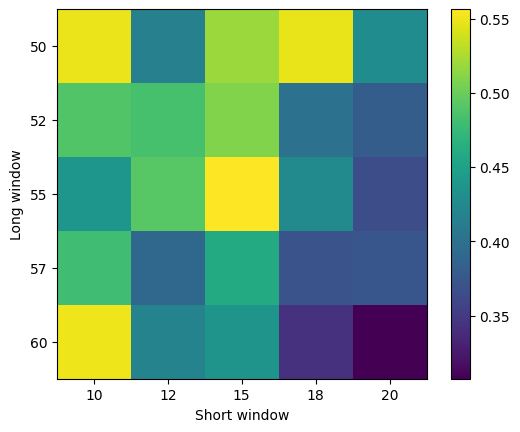

In [58]:
print(short_windows_1)
print(long_windows_1)
M = np.array([[sharp_ratios_moving_avarge_1[f"_{s}_{ss}"] for s in short_windows_1] for ss in long_windows_1])

plt.xticks(range(len(short_windows_1)), short_windows_1)
plt.yticks(range(len(long_windows_1)), long_windows_1)
plt.xlabel("Short window")
plt.ylabel("Long window")
plt.imshow(M, interpolation='nearest')
plt.colorbar()
plt.show()

Forth grid search

In [65]:
short_windows_1 = [10, 12, 15, 18, 20, 22, 25]
long_windows_1 = [45, 47, 50, 52, 55, 57, 60, 62]

periods_1 = []
for short_window in short_windows_1:
  for long_window in long_windows_1:
      periods_1.append([short_window, long_window])

In [66]:
sharp_ratios_moving_avarge_1 = {}

for short_window, long_window in periods_1:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_local = training_data.copy()
  for i, name in enumerate(finance_names):
    finance_data_local = moving_avarage_cross_over(finance_data_local, name, short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_1[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_1[combine_str]}")
#  for name in finance_names:


short window 10, long window 45 checked
			 0.044551549627043455 0.09902163265044076
	 sharp ratio portfolie: 0.4499173406311752
short window 10, long window 47 checked
			 0.04613075594613674 0.09232610747735809
	 sharp ratio portfolie: 0.499650177036325
short window 10, long window 50 checked
			 0.049613556255472535 0.09031656868624359
	 sharp ratio portfolie: 0.5493295081639803
short window 10, long window 52 checked
			 0.043715526861102846 0.08949892466633423
	 sharp ratio portfolie: 0.48844750955479144
short window 10, long window 55 checked
			 0.03837637403405334 0.0875608003865798
	 sharp ratio portfolie: 0.43828258609585735
short window 10, long window 57 checked
			 0.04000890219072338 0.08339728884002093
	 sharp ratio portfolie: 0.47973864315267517
short window 10, long window 60 checked
			 0.04688057535673851 0.0852339505497301
	 sharp ratio portfolie: 0.5500223215558434
short window 10, long window 62 checked
			 0.0436706481090558 0.08637220271238354
	 sharp ratio port

In [67]:
sorted_d = dict(sorted(sharp_ratios_moving_avarge_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)


_15_55 0.5563997288099063
_10_60 0.5500223215558434
_10_50 0.5493295081639803
_18_50 0.5477879685652999
_18_45 0.5476494404024744
_18_47 0.5386302208453699
_20_47 0.5197120789670396
_15_50 0.519214219064125
_15_52 0.5095347844705712
_10_62 0.5056099848984696
_10_47 0.499650177036325
_12_45 0.497217369545911
_20_45 0.4931373848009844
_12_55 0.49137568550428523
_10_52 0.48844750955479144
_22_45 0.48571116183250634
_12_52 0.4843999319455794
_10_57 0.47973864315267517
_12_47 0.4786760249111538
_25_45 0.4680180373169454
_22_47 0.46737152645305247
_15_47 0.46683529562445336
_22_50 0.465094586509437
_15_45 0.4642892755029093
_15_57 0.45946573580364203
_10_45 0.4499173406311752
_10_55 0.43828258609585735
_15_60 0.4363078753030307
_20_50 0.4289113868381038
_18_55 0.42648841044392805
_12_62 0.423883715853295
_15_62 0.42027817561773745
_12_60 0.4184961721709402
_12_50 0.41588144051418297
_18_52 0.4015801518567225
_12_57 0.3915695512616042
_20_52 0.38056401789582883
_25_47 0.3791395906976597
_20_5

[10, 12, 15, 18, 20, 22, 25]
[45, 47, 50, 52, 55, 57, 60, 62]


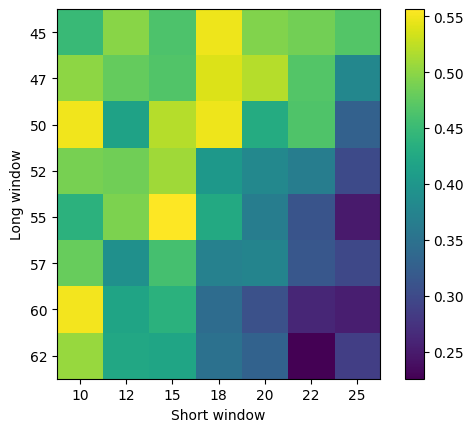

In [68]:
print(short_windows_1)
print(long_windows_1)
M = np.array([[sharp_ratios_moving_avarge_1[f"_{s}_{ss}"] for s in short_windows_1] for ss in long_windows_1])

plt.xticks(range(len(short_windows_1)), short_windows_1)
plt.yticks(range(len(long_windows_1)), long_windows_1)
plt.xlabel("Short window")
plt.ylabel("Long window")

plt.imshow(M, interpolation='nearest')
plt.colorbar()
plt.show()

In [69]:
best_period = [15, 55]


In [70]:
best_moving_avg = [15, 55]

Run for every individual asset also

In [71]:

for short_window, long_window in [best_moving_avg]:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_local = training_data.copy()
  for i, name in enumerate(finance_names):
    finance_data_local = moving_avarage_cross_over(finance_data_local, name, short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_222 = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_222}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    #print(finance_data_local.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


short window 15, long window 55 checked
			 0.0482428702677388 0.08670541657330849
	 sharp ratio portfolie: 0.5563997288099063
			 0.00839395938829302 0.05608240826002183
	 sharp ratio gurkor: 0.14967187837895735
			 0.04268712155102951 0.25792086105538453
	 sharp ratio guitars: 0.16550472643569186
			 0.005733398857632275 0.18182501752899324
	 sharp ratio slingshots: 0.031532508207887534
			 -0.030225486260237872 0.22680581239211595
	 sharp ratio stocks: -0.1332659244551554
			 -0.03428668189949211 0.21751305868797138
	 sharp ratio sugar: -0.15763045265561423
			 -0.0013334567907304941 0.05033103744232924
	 sharp ratio water: -0.02649372749883027
			 0.03214387724381313 0.21028381542062669
	 sharp ratio tranquillity: 0.15285949220350767


# testar

In [75]:
for short_window, long_window in [best_moving_avg]:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_local = test_data.copy()
  for i, name in enumerate(finance_names):
    finance_data_local = moving_avarage_cross_over(finance_data_local, name, short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_222 = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_222}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    #print(finance_data_local.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


short window 15, long window 55 checked
			 0.029090510602236986 0.05210738543422757
	 sharp ratio portfolie: 0.5582799896754831
			 0.04107051335452674 0.03361057630225993
	 sharp ratio gurkor: 1.2219520720257693
			 0.06362631879541207 0.1535303410562894
	 sharp ratio guitars: 0.4144217902315772
			 0.1014328944026293 0.11858938475815058
	 sharp ratio slingshots: 0.8553286165493651
			 -0.01794705004266834 0.17525497164847276
	 sharp ratio stocks: -0.10240536901096658
			 -0.003525101126522286 0.1733107288067046
	 sharp ratio sugar: -0.020339774408622276
			 0.04957775544878456 0.04947046436626715
	 sharp ratio water: 1.002168790689391
			 -0.033024225772336685 0.15752433632911783
	 sharp ratio tranquillity: -0.2096452303302437


Plotar

short window 15, long window 55 checked
			 0.029090510602236986 0.05210738543422757


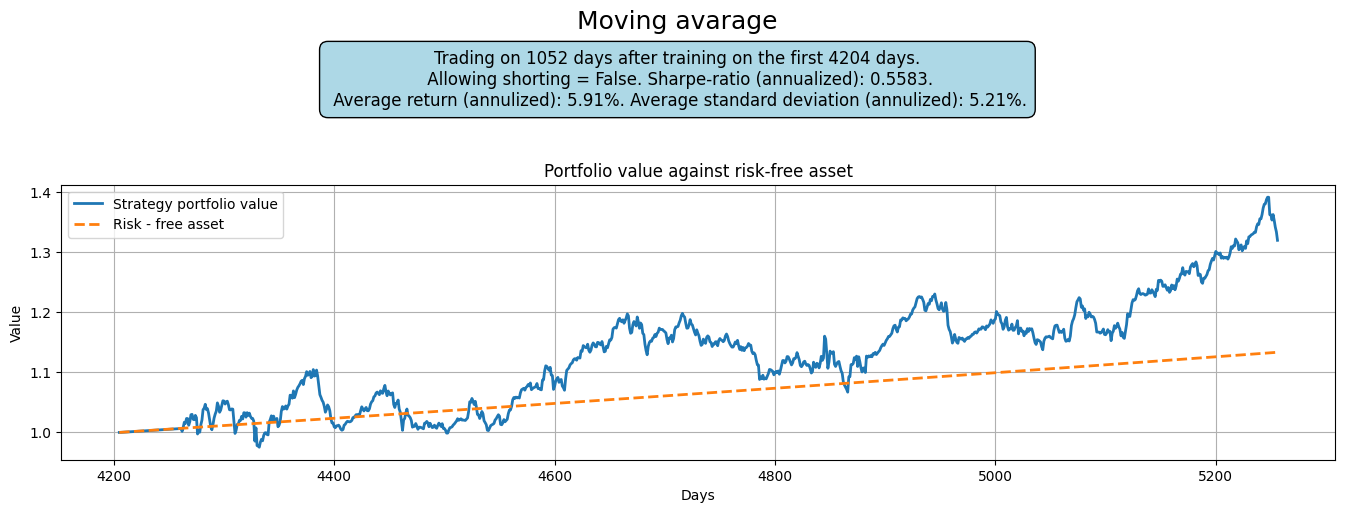

	 sharp ratio portfolie: 0.5582799896754831
			 0.04107051335452674 0.03361057630225993
	 sharp ratio gurkor: 1.2219520720257693
			 0.06362631879541207 0.1535303410562894
	 sharp ratio guitars: 0.4144217902315772
			 0.1014328944026293 0.11858938475815058
	 sharp ratio slingshots: 0.8553286165493651
			 -0.01794705004266834 0.17525497164847276
	 sharp ratio stocks: -0.10240536901096658
			 -0.003525101126522286 0.1733107288067046
	 sharp ratio sugar: -0.020339774408622276
			 0.04957775544878456 0.04947046436626715
	 sharp ratio water: 1.002168790689391
			 -0.033024225772336685 0.15752433632911783
	 sharp ratio tranquillity: -0.2096452303302437


In [76]:
for short_window, long_window in [best_moving_avg]:
  combine_str = f"_{short_window}_{long_window}"
  finance_data_local = test_data.copy()
  for i, name in enumerate(finance_names):
    finance_data_local = moving_avarage_cross_over(finance_data_local, name, short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_moving_avarge_2, mean_v, std_v = get_sharpe_ratio_v2(finance_data_local, 252, combine_str = combine_str)
  title_v = "Moving avarage"
  plot_time_series(finance_data_local['day'].to_numpy(), finance_data_local["portfolie_value"+combine_str].to_numpy()*1e-2, sharp_ratios_moving_avarge_2 , mean_v , std_v, title_v)

  print(f"\t sharp ratio portfolie: {sharp_ratios_moving_avarge_2}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    #print(finance_data_local.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


Plotar with initial days also

			 0.042454013825209753 0.08211001886226113


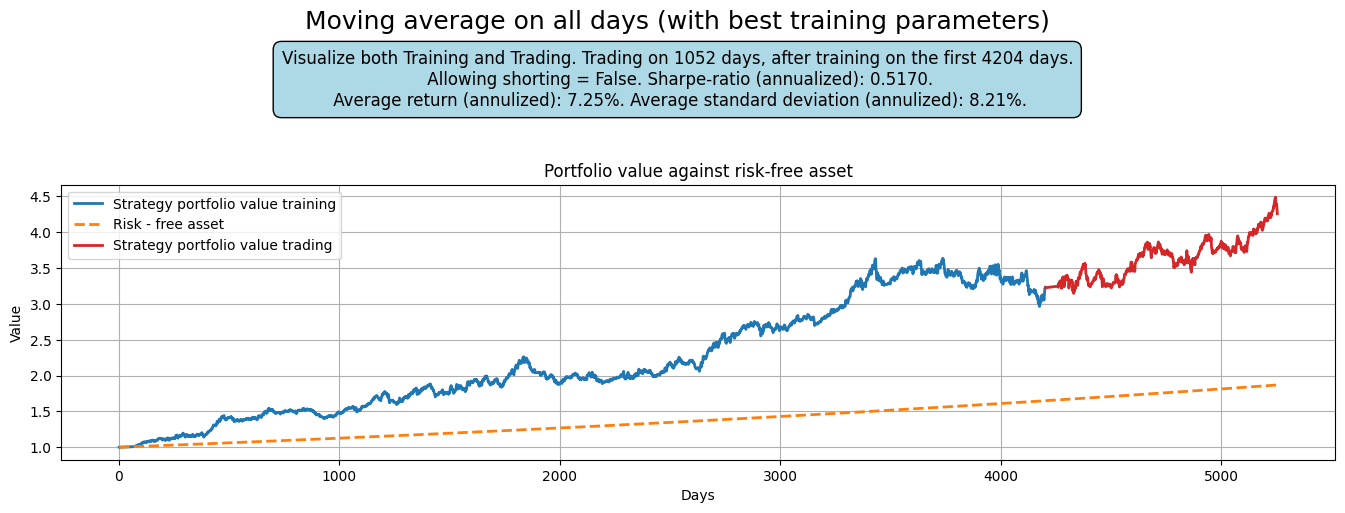

	 sharp ratio portfolie: 0.5170381691962098
			 0.013802964742914276 0.05395940862452933
	 sharp ratio gurkor: 0.2558027431130816
			 0.04776856321458627 0.24552126587303033
	 sharp ratio guitars: 0.19455977894513407
			 0.030531463003329096 0.19302675496233543
	 sharp ratio slingshots: 0.1581721819303577
			 -0.020824257807296714 0.21371760139058502
	 sharp ratio stocks: -0.09743819728370812
			 -0.02508403304979449 0.2140344167897985
	 sharp ratio sugar: -0.11719625948956293
			 0.008369813354913658 0.05317200726199479
	 sharp ratio water: 0.15741014465888076
			 0.025491880500092212 0.223705101701014
	 sharp ratio tranquillity: 0.11395305831765332


In [77]:
#print(best_bd_hps)
for s1, l1 in [best_moving_avg]: #8, 1.5, 5
  combine_str = f"_{s1}_{l1}"

  finance_data_local0 = training_data.copy()
  cs = 0

  #for name in finance_names:
  for i, name in enumerate(finance_names):
    finance_data_local0 = moving_avarage_cross_over(finance_data_local0, name, s1, l1)
  finance_data_local0 = stocks_positions(finance_data_local0, finance_names, combine_str)

  finance_data_local0 = several_stock_trade(finance_data_local0, finance_names, combine_str = combine_str)

  finance_data_local1 = test_data.copy()
  cs = 0

  #for name in finance_names:
  for i, name in enumerate(finance_names):
    finance_data_local1 = moving_avarage_cross_over(finance_data_local1, name, s1, l1)
  finance_data_local1 = stocks_positions(finance_data_local1, finance_names, combine_str)

  finance_data_local1 = several_stock_trade(finance_data_local1, finance_names, combine_str = combine_str)


  finance_data_local2 = finance_data.copy()
  cs = 0

  #for name in finance_names:
  for i, name in enumerate(finance_names):
    finance_data_local2 = moving_avarage_cross_over(finance_data_local2, name, s1, l1)
  finance_data_local2 = stocks_positions(finance_data_local2, finance_names, combine_str)

  finance_data_local2 = several_stock_trade(finance_data_local2, finance_names, combine_str = combine_str)

  sharp_ratios_bd2, mean_v, std_v = get_sharpe_ratio_v2(finance_data_local2, 252, combine_str = combine_str)
  plot_time_series_v2(finance_data_local0['day'].to_numpy(), finance_data_local0["portfolie_value"+combine_str].to_numpy()*1e-2, finance_data_local1['day'].to_numpy(), finance_data_local1["portfolie_value"+combine_str].to_numpy()*1e-2, sharp_ratios_bd2 , mean_v , std_v, "Moving average on all days (with best training parameters)")

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd2}")
  for name in finance_names:
    finance_data_local2 = one_stock_trade(finance_data_local2, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local2, name, 252, combine_str = combine_str)}")


In [79]:
stringen = """0.029090510602236986 0.05210738543422757
	 sharp ratio portfolie: 0.5582799896754831
			 0.04107051335452674 0.03361057630225993
	 sharp ratio gurkor: 1.2219520720257693
			 0.06362631879541207 0.1535303410562894
	 sharp ratio guitars: 0.4144217902315772
			 0.1014328944026293 0.11858938475815058
	 sharp ratio slingshots: 0.8553286165493651
			 -0.01794705004266834 0.17525497164847276
	 sharp ratio stocks: -0.10240536901096658
			 -0.003525101126522286 0.1733107288067046
	 sharp ratio sugar: -0.020339774408622276
			 0.04957775544878456 0.04947046436626715
	 sharp ratio water: 1.002168790689391
			 -0.033024225772336685 0.15752433632911783
	 sharp ratio tranquillity: -0.2096452303302437"""
stringen = "".join(stringen.split("\t\t\t "))
stringen = "".join(stringen.split(":"))
stringen = "".join(stringen.split("sharp ratio "))
stringen = "".join(stringen.split("\t "))
stringen = stringen.split("\n")
stringen = [stringen[i*2].split(" ") + stringen[2 * i + 1].split(" ") for i in range(len(stringen)//2)]
stringen.append(stringen[0])
stringen.pop(0)
stringen_out = ""
for i in range(len(stringen)):
  print(stringen[i])
  stringen_out += stringen[i][2]+f" & ${float(stringen[i][3]):.2f}$ & ${float(stringen[i][0])*100 + 3:.2f} \\%$ & ${100*float(stringen[i][1]):.2f} \\%$ \\\\ \n"
print(stringen_out)

['0.04107051335452674', '0.03361057630225993', 'gurkor', '1.2219520720257693']
['0.06362631879541207', '0.1535303410562894', 'guitars', '0.4144217902315772']
['0.1014328944026293', '0.11858938475815058', 'slingshots', '0.8553286165493651']
['-0.01794705004266834', '0.17525497164847276', 'stocks', '-0.10240536901096658']
['-0.003525101126522286', '0.1733107288067046', 'sugar', '-0.020339774408622276']
['0.04957775544878456', '0.04947046436626715', 'water', '1.002168790689391']
['-0.033024225772336685', '0.15752433632911783', 'tranquillity', '-0.2096452303302437']
['0.029090510602236986', '0.05210738543422757', 'portfolie', '0.5582799896754831']
gurkor & $1.22$ & $7.11 \%$ & $3.36 \%$ \\ 
guitars & $0.41$ & $9.36 \%$ & $15.35 \%$ \\ 
slingshots & $0.86$ & $13.14 \%$ & $11.86 \%$ \\ 
stocks & $-0.10$ & $1.21 \%$ & $17.53 \%$ \\ 
sugar & $-0.02$ & $2.65 \%$ & $17.33 \%$ \\ 
water & $1.00$ & $7.96 \%$ & $4.95 \%$ \\ 
tranquillity & $-0.21$ & $-0.30 \%$ & $15.75 \%$ \\ 
portfolie & $0.56$ & 

# Constant-Mix

Hyperparameters to be otimize

short window regulice the driftbased rebalancing
long window regulice the time-based rebalancing

In [ ]:
#maximum_in_one_stock = [0]
short_windows_b = [1., 1.25, 1.5, 2., 2.5, 3.]
long_windows_b = [5, 10, 22, 63, 126, 252, 504, 1016]

periods_b = []
for short_window in short_windows_b:
  for long_window in long_windows_b:
      periods_b.append([short_window, long_window])

In [ ]:
sharp_ratios_buy_and_hold_1 = {}

for short_window, long_window in periods_b:
  combine_str = f"_{short_window}_{long_window}_bah"
  finance_data_local = training_data.copy()
  finance_data_local = buy_and_hold_signal(finance_data_local, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, replacing_weight=short_window, rebalancing_interval=long_window, maximum_in_one_stock=1.)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_buy_and_hold_1[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_buy_and_hold_1[combine_str]}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    #print(finance_data_local.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


short window 1.0, long window 5 checked
			 0.00045799584133019675 0.10040742633330937
	 sharp ratio portfolie: 0.004561374173757307
			 0.004278987638797251 0.06067945067153716
	 sharp ratio gurkor: 0.07051790336665639
			 0.04467123995405056 0.2577223188125787
	 sharp ratio guitars: 0.17333089411839597
			 0.008376737265805978 0.1825840675276257
	 sharp ratio slingshots: 0.045878796431887706
			 -0.03601386856261093 0.23023453429645097
	 sharp ratio stocks: -0.15642253093204217
			 -0.0409580457639878 0.22128420594011575
	 sharp ratio sugar: -0.18509249492063581
			 0.000998290377045158 0.052792023345325644
	 sharp ratio water: 0.018909871487877903
			 0.024905092147140467 0.2136825070759252
	 sharp ratio tranquillity: 0.11655185297077801
short window 1.0, long window 10 checked
			 0.00035154070366031796 0.1003650868374313
	 sharp ratio portfolie: 0.003502619434084028
			 0.004278987638797251 0.06067945067153716
	 sharp ratio gurkor: 0.07051790336665639
			 0.04467123995405056 0.257

In [ ]:
sorted_d = dict(sorted(sharp_ratios_buy_and_hold_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_1.5_504_bah 0.015023961421667552
_2.0_504_bah 0.014510191789878503
_2.5_504_bah 0.014510191789878503
_3.0_504_bah 0.014510191789878503
_1.25_504_bah 0.011613692942868875
_1.0_5_bah 0.004561374173757307
_1.0_10_bah 0.003502619434084028
_1.0_63_bah 2.2369669797021397e-05
_1.0_126_bah -0.0005531991784176646
_1.0_252_bah -0.0007206241315465606
_1.0_504_bah -0.000955729485824608
_1.0_22_bah -0.0009648112132953855
_1.0_1016_bah -0.0010406941333831814
_1.5_126_bah -0.0023322169815393843
_2.0_126_bah -0.0023322169815393843
_2.5_126_bah -0.0023322169815393843
_3.0_126_bah -0.0023322169815393843
_1.25_126_bah -0.0031773806817354654
_1.25_5_bah -0.004377932278267009
_1.5_5_bah -0.004377932278267009
_2.0_5_bah -0.004377932278267009
_2.5_5_bah -0.004377932278267009
_3.0_5_bah -0.004377932278267009
_1.25_252_bah -0.006073314237768296
_2.0_252_bah -0.007523989663054568
_2.5_252_bah -0.007523989663054568
_3.0_252_bah -0.007523989663054568
_1.25_63_bah -0.008155768288213948
_1.5_252_bah -0.00815765195

Bester resolution

In [ ]:
#maximum_in_one_stock = [0]
short_windows_b = [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9]
long_windows_b = [63, 126, 252, 126*3, 504, 126*5, 126*6]

periods_b = []
for short_window in short_windows_b:
  for long_window in long_windows_b:
      periods_b.append([short_window, long_window])

In [ ]:
sharp_ratios_buy_and_hold_1 = {}

for short_window, long_window in periods_b:
  combine_str = f"_{short_window}_{long_window}_bah"
  finance_data_local = training_data.copy()
  finance_data_local = buy_and_hold_signal(finance_data_local, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, replacing_weight=short_window, rebalancing_interval=long_window, maximum_in_one_stock=1.)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_buy_and_hold_1[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_buy_and_hold_1[combine_str]}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    #print(finance_data_local.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


short window 1.1, long window 63 checked
			 -0.0012619548380771474 0.0998290574584513
	 sharp ratio portfolie: -0.012641157496677468
			 0.004278987638797251 0.06067945067153716
	 sharp ratio gurkor: 0.07051790336665639
			 0.04467123995405056 0.2577223188125787
	 sharp ratio guitars: 0.17333089411839597
			 0.008376737265805978 0.1825840675276257
	 sharp ratio slingshots: 0.045878796431887706
			 -0.03601386856261093 0.23023453429645097
	 sharp ratio stocks: -0.15642253093204217
			 -0.0409580457639878 0.22128420594011575
	 sharp ratio sugar: -0.18509249492063581
			 0.000998290377045158 0.052792023345325644
	 sharp ratio water: 0.018909871487877903
			 0.024905092147140467 0.2136825070759252
	 sharp ratio tranquillity: 0.11655185297077801
short window 1.1, long window 126 checked
			 -0.0006761221443999911 0.10005906282182939
	 sharp ratio portfolie: -0.006757230433028651
			 0.004278987638797251 0.06067945067153716
	 sharp ratio gurkor: 0.07051790336665639
			 0.04467123995405056 0

In [ ]:
sorted_d = dict(sorted(sharp_ratios_buy_and_hold_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_1.2_378_bah 0.020582266948809567
_1.1_756_bah 0.018135574281973675
_1.3_378_bah 0.01772372563482113
_1.1_378_bah 0.01745543098376431
_1.5_378_bah 0.016966435905371065
_1.7_378_bah 0.016818171073813913
_1.8_378_bah 0.016818171073813913
_1.9_378_bah 0.016818171073813913
_1.6_378_bah 0.016815382651925368
_1.4_378_bah 0.01646688631727517
_1.6_504_bah 0.016217098736724854
_1.7_504_bah 0.015703865955458005
_1.5_504_bah 0.015023961421667552
_1.8_504_bah 0.014570565919783828
_1.9_504_bah 0.014510191789878503
_1.4_504_bah 0.013292783704179398
_1.3_504_bah 0.011795686007332516
_1.2_504_bah 0.011369930716439046
_1.1_504_bah 0.007873869558970195
_1.5_630_bah 0.00785784944135161
_1.7_630_bah 0.007841965638971212
_1.8_630_bah 0.007841965638971212
_1.9_630_bah 0.007841965638971212
_1.6_630_bah 0.007624192788492764
_1.2_630_bah 0.006966358558022057
_1.4_630_bah 0.006719552252105755
_1.2_756_bah 0.0063077054721438226
_1.3_630_bah 0.006304544524847824
_1.1_630_bah 0.005350047568540807
_1.3_756_bah 0.00

Testing

In [ ]:
for short_window, long_window in [[1.2, 378]]:
  finance_data_local = test_data.copy()
  combine_str = f"_{short_window}_{long_window}_bah"
  finance_data_local = buy_and_hold_signal(finance_data_local, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, replacing_weight=short_window, rebalancing_interval=long_window, maximum_in_one_stock=1.)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_buy_and_hold_1[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_buy_and_hold_1[combine_str]}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    #print(finance_data_local.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


short window 1.2, long window 378 checked
			 0.03829216432318973 0.07657688468352
	 sharp ratio portfolie: 0.5000486045031096
			 0.041645467961696665 0.033889735488017395
	 sharp ratio gurkor: 1.2288519624598875
			 0.06918405110234829 0.15698687658508878
	 sharp ratio guitars: 0.440699583349247
			 0.12143346237723601 0.12792321254126435
	 sharp ratio slingshots: 0.9492683928498518
			 0.00931033694693779 0.15093811988948985
	 sharp ratio stocks: 0.06168313845272753
			 0.001921635545397029 0.1727363959312623
	 sharp ratio sugar: 0.011124670831743608
			 0.05080900121739822 0.049856535301367175
	 sharp ratio water: 1.0191041336962885
			 -0.013191846115471195 0.17669869260270787
	 sharp ratio tranquillity: -0.07465729327795283


# Plotar

short window 1.2, long window 378 checked
			 0.03829216432318973 0.07657688468352


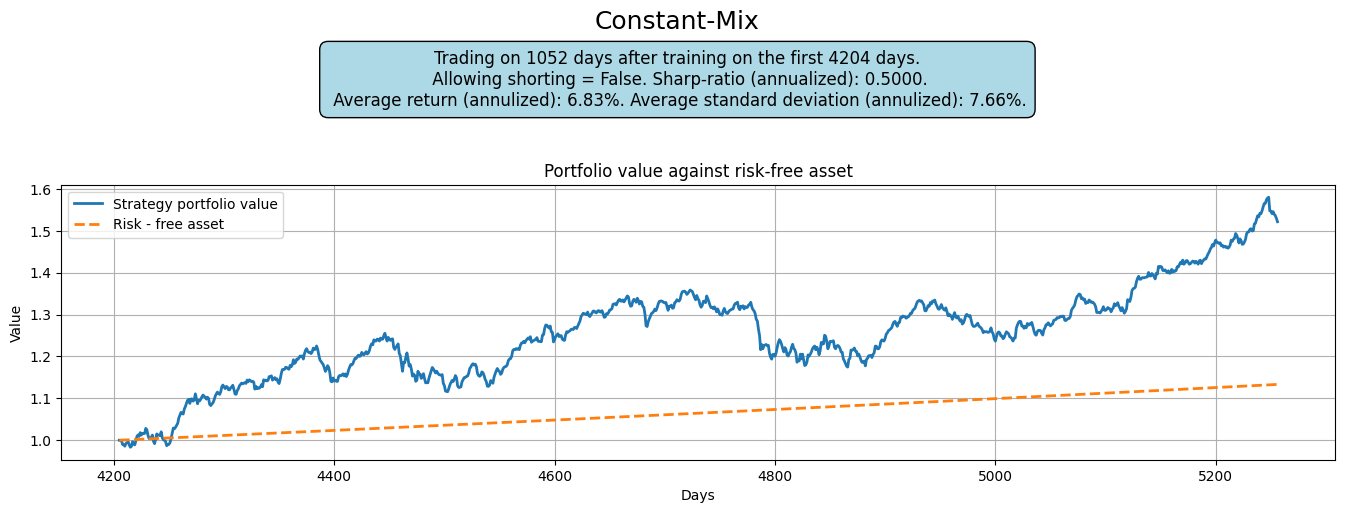

	 sharp ratio portfolie: 0.5000486045031096
			 0.041645467961696665 0.033889735488017395
	 sharp ratio gurkor: 1.2288519624598875
			 0.06918405110234829 0.15698687658508878
	 sharp ratio guitars: 0.440699583349247
			 0.12143346237723601 0.12792321254126435
	 sharp ratio slingshots: 0.9492683928498518
			 0.00931033694693779 0.15093811988948985
	 sharp ratio stocks: 0.06168313845272753
			 0.001921635545397029 0.1727363959312623
	 sharp ratio sugar: 0.011124670831743608
			 0.05080900121739822 0.049856535301367175
	 sharp ratio water: 1.0191041336962885
			 -0.013191846115471195 0.17669869260270787
	 sharp ratio tranquillity: -0.07465729327795283
short window 100000.0, long window None checked
			 0.036424454315034153 0.07888599733833157


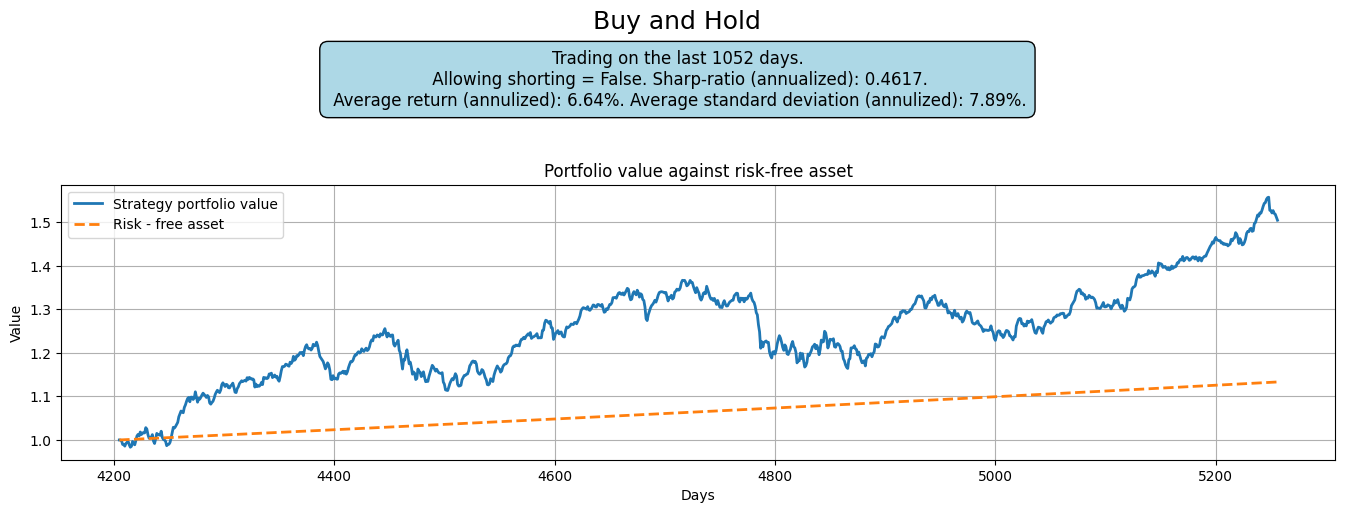

	 sharp ratio portfolie: 0.46173535917679415
			 0.041645467961696665 0.033889735488017395
	 sharp ratio gurkor: 1.2288519624598875
			 0.06918405110234829 0.15698687658508878
	 sharp ratio guitars: 0.440699583349247
			 0.12143346237723601 0.12792321254126435
	 sharp ratio slingshots: 0.9492683928498518
			 0.00931033694693779 0.15093811988948985
	 sharp ratio stocks: 0.06168313845272753
			 0.001921635545397029 0.1727363959312623
	 sharp ratio sugar: 0.011124670831743608
			 0.05080900121739822 0.049856535301367175
	 sharp ratio water: 1.0191041336962885
			 -0.013191846115471195 0.17669869260270787
	 sharp ratio tranquillity: -0.07465729327795283


In [ ]:
for short_window, long_window in [[1.2, 378], [100000.0, None]]:
  finance_data_local = test_data.copy()
  combine_str = f"_{short_window}_{long_window}_bah"
  finance_data_local = buy_and_hold_signal(finance_data_local, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, replacing_weight=short_window, rebalancing_interval=long_window, maximum_in_one_stock=1.)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_bd2, mean_v, std_v = get_sharpe_ratio_v2(finance_data_local, 252, combine_str = combine_str)
  title_v = "Buy and Hold" if short_window != 1.2 else "Constant-Mix"
  plot_time_series(finance_data_local['day'].to_numpy(), finance_data_local["portfolie_value"+combine_str].to_numpy()*1e-2, sharp_ratios_bd2 , mean_v , std_v, title_v, short_window==1.2)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd2}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    #print(finance_data_local.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


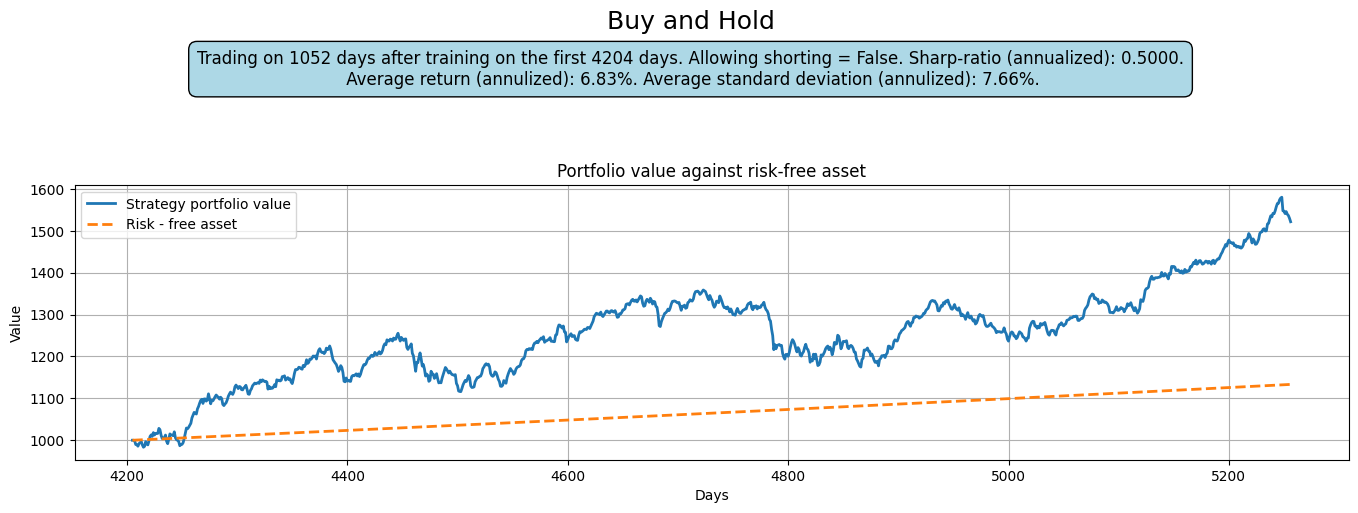

In [ ]:
#plot_time_series(finance_data_local['day'].to_numpy(), finance_data_local["portfolie_value"+combine_str].to_numpy()*10, 0.500, 0.0382921, 0.076576, "Buy and Hold")

In [ ]:
"""
for short_window, long_window in [[10., None]]:
  finance_data_local = test_data.copy()
  combine_str = f"_{short_window}_{long_window}_bah"
  finance_data_local = buy_and_hold_signal(finance_data_local, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, replacing_weight=short_window, rebalancing_interval=long_window, maximum_in_one_stock=1.)

  print(f"short window {short_window}, long window {long_window} checked")
  sharp_ratios_buy_and_hold2 = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_buy_and_hold2}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    #print(finance_data_local.keys())
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")
"""

short window 10.0, long window None checked
			 0.036424454315034153 0.07888599733833157
	 sharp ratio portfolie: 0.46173535917679415
			 0.041645467961696665 0.033889735488017395
	 sharp ratio gurkor: 1.2288519624598875
			 0.06918405110234829 0.15698687658508878
	 sharp ratio guitars: 0.440699583349247
			 0.12143346237723601 0.12792321254126435
	 sharp ratio slingshots: 0.9492683928498518
			 0.00931033694693779 0.15093811988948985
	 sharp ratio stocks: 0.06168313845272753
			 0.001921635545397029 0.1727363959312623
	 sharp ratio sugar: 0.011124670831743608
			 0.05080900121739822 0.049856535301367175
	 sharp ratio water: 1.0191041336962885
			 -0.013191846115471195 0.17669869260270787
	 sharp ratio tranquillity: -0.07465729327795283


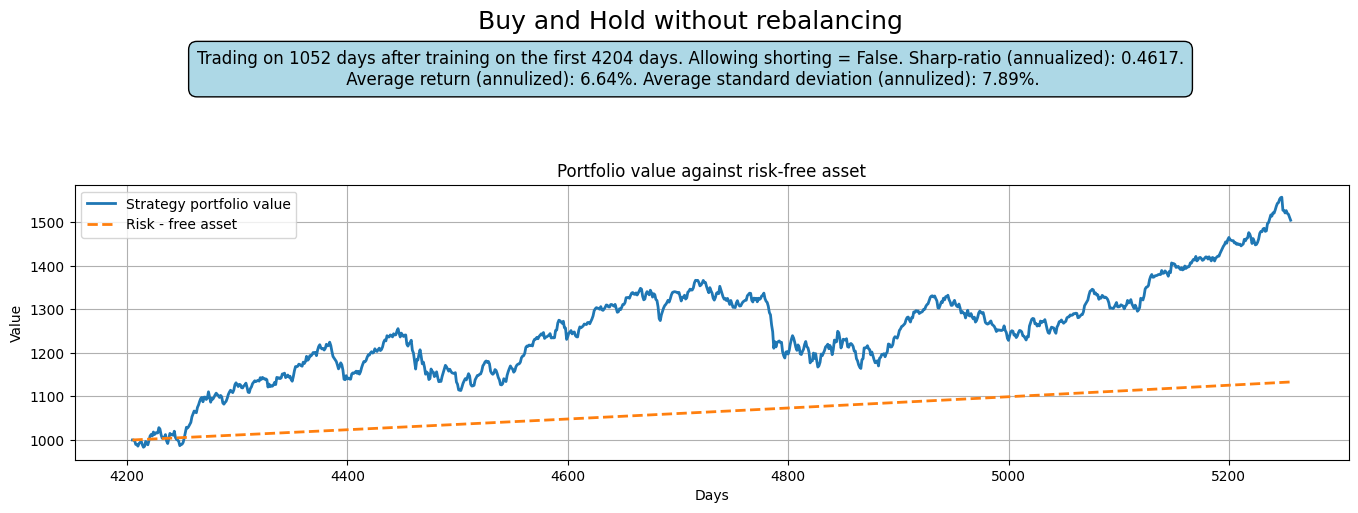

In [ ]:
#plot_time_series(finance_data_local['day'].to_numpy(), finance_data_local["portfolie_value"+combine_str].to_numpy()*10, 0.46173535917679415, 0.036424454315034153 , 0.07888599733833157, "Buy and Hold without rebalancing")

			 0.012263146858598306 0.10482635180814869


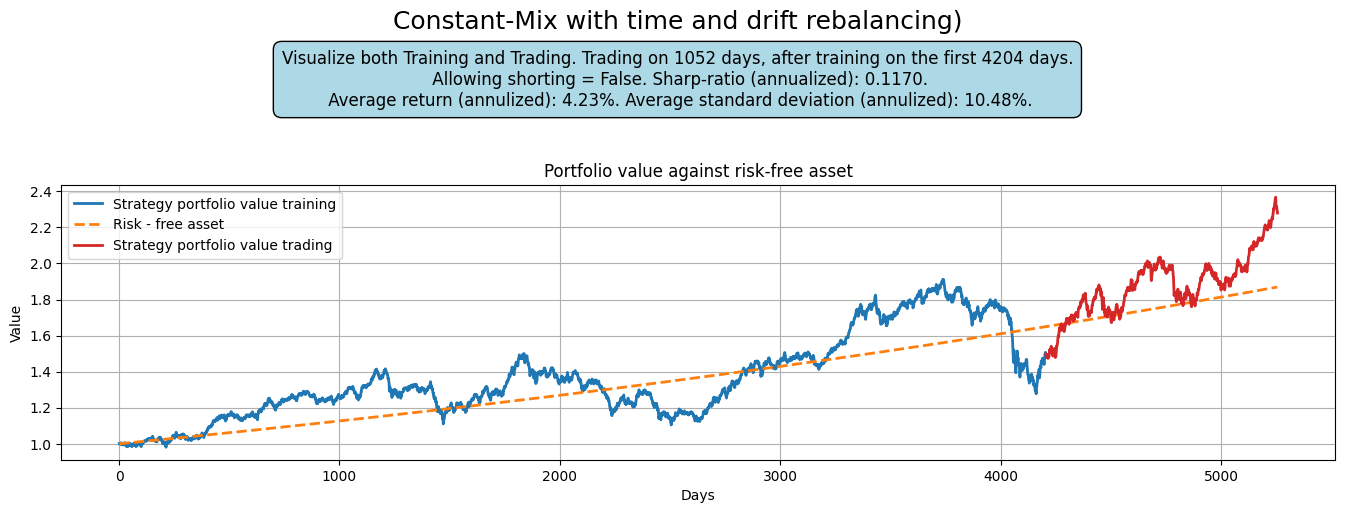

	 sharp ratio portfolie: 0.1169853443058106
			 0.01055161944737052 0.058081810704585964
	 sharp ratio gurkor: 0.18166822486023834
			 0.04933319052894618 0.24533059546605077
	 sharp ratio guitars: 0.20108861854441218
			 0.032608723784764856 0.19332353105383945
	 sharp ratio slingshots: 0.16867436471395467
			 -0.025398524964631613 0.2168095416888824
	 sharp ratio stocks: -0.11714671211785511
			 -0.030355423016740143 0.21730688117815664
	 sharp ratio sugar: -0.1396891936977071
			 0.010207079610531144 0.05470610384898218
	 sharp ratio water: 0.18658026970277555
			 0.01977879658645694 0.22607988146198452
	 sharp ratio tranquillity: 0.08748587648999966


In [ ]:
#print(best_bd_hps)
for s1, l1 in [[1.2, 378]]:#, [100000., None]]: #8, 1.5, 5
  combine_str = f"_{s1}_{l1}_bah"

  finance_data_local0 = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local0 = buy_and_hold_signal(finance_data_local0, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_local0 = stocks_positions(finance_data_local0, finance_names, combine_str)

  finance_data_local0 = several_stock_trade(finance_data_local0, finance_names, combine_str = combine_str, replacing_weight=s1, rebalancing_interval=l1, maximum_in_one_stock=1.)


  finance_data_local1 = test_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local1 = buy_and_hold_signal(finance_data_local1, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_local1 = stocks_positions(finance_data_local1, finance_names, combine_str)

  finance_data_local1 = several_stock_trade(finance_data_local1, finance_names, combine_str = combine_str, replacing_weight=s1, rebalancing_interval=l1, maximum_in_one_stock=1.)


  finance_data_local2 = finance_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local2 = buy_and_hold_signal(finance_data_local2, finance_names, combine_str=combine_str)#short_window, long_window)
  finance_data_local2 = stocks_positions(finance_data_local2, finance_names, combine_str)

  finance_data_local2 = several_stock_trade(finance_data_local2, finance_names, combine_str = combine_str, replacing_weight=s1, rebalancing_interval=l1, maximum_in_one_stock=1.)

  sharp_ratios_bd2, mean_v, std_v = get_sharpe_ratio_v2(finance_data_local2, 252, combine_str = combine_str)
  plot_time_series_v2(finance_data_local0['day'].to_numpy(), finance_data_local0["portfolie_value"+combine_str].to_numpy()*1e-2, finance_data_local1['day'].to_numpy(), finance_data_local1["portfolie_value"+combine_str].to_numpy()*1e-2, sharp_ratios_bd2 , mean_v , std_v, "Constant-Mix with time and drift rebalancing)")

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd2}")
  for name in finance_names:
    finance_data_local2 = one_stock_trade(finance_data_local2, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local2, name, 252, combine_str = combine_str)}")


# channal breakout
This channal breakout will be ignored in the report another version was used

In [ ]:
#maximum_in_one_stock = [0]
channal_size = [0.01, 0.01, 0.05, 0.1]
days_above = [2, 3, 4]
sell_after = [5, 10, 25]
above_value = [0.001, 0.005, 0.01, 0.05]
look_back = [5, 10, 15, 20, 25, 50]


periods_c = []
for i1 in channal_size:
  for i2 in days_above:
    for i3 in sell_after:
      for i4 in above_value:
        for i5 in look_back:
          periods_c.append([i1, i2, i3, i4, i5])

In [ ]:
sharp_ratios_chan_1 = {}

for channal_size, days_above, sell_after, above_value, look_back in periods_c:
  combine_str = f"_{channal_size}_{days_above}_{sell_after}_{above_value}_{look_back}"
  finance_data_local = training_data.copy()
  cs = 0
  for name in finance_names:
    finance_data_local, cs_1 = channal_breakout(finance_data_local, name, c = channal_size, d = days_above, k = sell_after, x = above_value, j = look_back, combine_str = combine_str)
    cs += cs_1
  if cs == 0:
    print("no found")
    sharp_ratios_chan_1[combine_str] = -999.
    continue
  print("\t\t\tsa")
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, maximum_in_one_stock=0.5)

  print(f"params {channal_size}, {days_above}, {sell_after}, {above_value}, {look_back} checked", combine_str)
  sharp_ratios_chan_1[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_chan_1[combine_str]}")
  #for name in finance_names:
  #  finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


Utdata för streaming har trunkerats till de sista 5000 raderna.
4135 0
4135 0
4075 60
4135 0
			sa
params 0.01, 4, 10, 0.005, 15 checked _0.01_4_10_0.005_15
			 -0.0006161397323182358 0.0042551653698119215
	 sharp ratio portfolie: -0.14479806982107235
4090 40
4130 0
4130 0
4130 0
4130 0
4100 30
4130 0
			sa
params 0.01, 4, 10, 0.005, 20 checked _0.01_4_10_0.005_20
			 -0.00037651902924473545 0.0026475262101632755
	 sharp ratio portfolie: -0.14221541142798172
4105 20
4125 0
4125 0
4125 0
4125 0
4125 0
4125 0
			sa
params 0.01, 4, 10, 0.005, 25 checked _0.01_4_10_0.005_25
			 -0.0002641844104406976 0.0015661843471535494
	 sharp ratio portfolie: -0.1686802775936547
4100 0
4100 0
4100 0
4100 0
4100 0
4100 0
4100 0
no found
4085 60
3916 229
4065 80
4115 30
3999 146
4135 10
3895 250
			sa
params 0.01, 4, 10, 0.01, 5 checked _0.01_4_10_0.01_5
			 -0.005419909248621483 0.029190716854464276
	 sharp ratio portfolie: -0.18567235863522794
4120 20
4130 10
4140 0
4140 0
4130 10
4140 0
4120 20
			sa


In [ ]:
sorted_d = dict(sorted(sharp_ratios_chan_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_0.05_2_25_0.001_15 0.599724173712704
_0.05_4_10_0.001_25 0.46611444510719924
_0.05_3_25_0.001_15 0.46176294944686846
_0.05_4_10_0.001_20 0.43544008845188426
_0.01_2_10_0.001_25 0.43254975362347825
_0.01_2_5_0.001_20 0.4235057569769714
_0.1_2_5_0.05_5 0.4070829938540872
_0.1_2_10_0.05_5 0.40184677692137916
_0.1_4_10_0.001_50 0.39965075538275724
_0.01_3_5_0.01_10 0.38735204223352343
_0.1_3_25_0.001_25 0.3821018122822607
_0.05_3_5_0.05_5 0.38070987615969
_0.1_2_25_0.05_5 0.37655318467746807
_0.01_2_10_0.01_15 0.37175749602884234
_0.1_3_5_0.05_5 0.3707643967826792
_0.05_4_25_0.001_20 0.36781161445472205
_0.05_2_25_0.005_15 0.3675496279399401
_0.1_2_10_0.05_10 0.3633468847398535
_0.1_2_10_0.05_15 0.3633468847398535
_0.05_4_25_0.001_25 0.36248958894865196
_0.1_2_5_0.05_10 0.36215332457241933
_0.1_2_5_0.05_15 0.36215332457241933
_0.05_4_25_0.001_15 0.3549212114677803
_0.05_2_25_0.01_15 0.35405700889879654
_0.1_4_10_0.005_50 0.3537659469015692
_0.01_2_5_0.01_10 0.35362968170495535
_0.01_2_10_

In [ ]:
#maximum_in_one_stock = [0]
channal_size = [0.01, 0.05, 0.1]
days_above = [2, 3, 4]
sell_after = [5, 10, 25]
above_value = [0.001, 0.01, 0.05]
look_back = [5, 10, 15, 20, 25]


periods_c2 = []
for i1 in channal_size:
  for i2 in days_above:
    for i3 in sell_after:
      for i4 in above_value:
        for i5 in look_back:
          periods_c2.append([i1, i2, i3, i4, i5])

In [ ]:
sharp_ratios_chan_2 = {}

for channal_size, days_above, sell_after, above_value, look_back in periods_c2:
  combine_str = f"_{channal_size}_{days_above}_{sell_after}_{above_value}_{look_back}"
  finance_data_local = training_data.copy()
  cs = 0
  for name in finance_names:
    finance_data_local, cs_1 = channal_breakout(finance_data_local, name, c = channal_size, d = days_above, k = sell_after, x = above_value, j = look_back, combine_str = combine_str)
    cs += cs_1
  if cs == 0:
    print("no found")
    sharp_ratios_chan_2[combine_str] = -999.
    continue
  print("\t\t\tsa")
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, maximum_in_one_stock=0.5)

  print(f"params {channal_size}, {days_above}, {sell_after}, {above_value}, {look_back} checked", combine_str)
  sharp_ratios_chan_2[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_chan_2[combine_str]}")
  #for name in finance_names:
  #  finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


2556 1591
3666 481
3674 473
4051 96
3841 306
2487 1660
3629 518
			sa
params 0.01, 2, 5, 0.001, 5 checked _0.01_2_5_0.001_5
			 -0.01761162510861801 0.0480443395962461
	 sharp ratio portfolie: -0.36657024025352775
3494 648
4126 16
4101 41
4142 0
4127 15
3237 905
4126 16
			sa
params 0.01, 2, 5, 0.001, 10 checked _0.01_2_5_0.001_10
			 -0.0006237118144547896 0.017739507438910954
	 sharp ratio portfolie: -0.03515947760120446
3884 253
4137 0
4132 5
4137 0
4137 0
3721 416
4132 5
			sa
params 0.01, 2, 5, 0.001, 15 checked _0.01_2_5_0.001_15
			 -0.0001403771750730059 0.008969740294379722
	 sharp ratio portfolie: -0.015650082440063925
4036 96
4132 0
4132 0
4132 0
4132 0
3990 142
4132 0
			sa
params 0.01, 2, 5, 0.001, 20 checked _0.01_2_5_0.001_20
			 0.0014355305234521043 0.003389636385816977
	 sharp ratio portfolie: 0.4235057569769714
4079 48
4127 0
4127 0
4127 0
4127 0
4081 46
4127 0
			sa
params 0.01, 2, 5, 0.001, 25 checked _0.01_2_5_0.001_25
			 0.0009585722639138528 0.00317938842399906

In [ ]:
sorted_d = dict(sorted(sharp_ratios_chan_2.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_0.05_2_25_0.001_15 0.599724173712704
_0.05_4_10_0.001_25 0.46611444510719924
_0.05_3_25_0.001_15 0.46176294944686846
_0.05_4_10_0.001_20 0.43544008845188426
_0.01_2_10_0.001_25 0.43254975362347825
_0.01_2_5_0.001_20 0.4235057569769714
_0.1_2_5_0.05_5 0.4070829938540872
_0.1_2_10_0.05_5 0.40184677692137916
_0.01_3_5_0.01_10 0.38735204223352343
_0.1_3_25_0.001_25 0.3821018122822607
_0.05_3_5_0.05_5 0.38070987615969
_0.1_2_25_0.05_5 0.37655318467746807
_0.01_2_10_0.01_15 0.37175749602884234
_0.1_3_5_0.05_5 0.3707643967826792
_0.05_4_25_0.001_20 0.36781161445472205
_0.1_2_10_0.05_10 0.3633468847398535
_0.1_2_10_0.05_15 0.3633468847398535
_0.05_4_25_0.001_25 0.36248958894865196
_0.1_2_5_0.05_10 0.36215332457241933
_0.1_2_5_0.05_15 0.36215332457241933
_0.05_4_25_0.001_15 0.3549212114677803
_0.05_2_25_0.01_15 0.35405700889879654
_0.01_2_5_0.01_10 0.35362968170495535
_0.01_2_10_0.01_10 0.34882542998280175
_0.1_2_25_0.05_10 0.3426328107139731
_0.1_2_25_0.05_15 0.3426328107139731
_0.05_2_10_0.0

testar

In [ ]:
#maximum_in_one_stock = [0]
channal_size = [0.05] #_0.01_2_10_0.001_25
days_above = [2]#4] _0.05_2_25_0.001_15
sell_after = [25]
above_value = [0.001]
look_back = [15]


best_cb_hps = []
for i1 in channal_size:
  for i2 in days_above:
    for i3 in sell_after:
      for i4 in above_value:
        for i5 in look_back:
          best_cb_hps.append([i1, i2, i3, i4, i5])

In [ ]:
sharp_ratios_chan_3 = {}

for channal_size, days_above, sell_after, above_value, look_back in best_cb_hps:
  combine_str = f"_{channal_size}_{days_above}_{sell_after}_{above_value}_{look_back}"
  finance_data_local = training_data.copy()
  cs = 0
  for name in finance_names:
    finance_data_local, cs_1 = channal_breakout(finance_data_local, name, c = channal_size, d = days_above, k = sell_after, x = above_value, j = look_back, combine_str = combine_str)
    cs += cs_1
  if cs == 0:
    print("no found")
    sharp_ratios_chan_3[combine_str] = -999.
    continue
  print("\t\t\tsa")
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, maximum_in_one_stock=0.5)

  print(f"params {channal_size}, {days_above}, {sell_after}, {above_value}, {look_back} checked", combine_str)
  sharp_ratios_chan_3[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_chan_3[combine_str]}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


1820 2317
2285 1852
2286 1851
2987 1150
2722 1415
1690 2447
2374 1763
			sa
params 0.05, 2, 25, 0.001, 15 checked _0.05_2_25_0.001_15
			 0.040861974340283526 0.06813461276259697
	 sharp ratio portfolie: 0.599724173712704
			 0.00833590478468843 0.0560889624286176
	 sharp ratio gurkor: 0.1486193436952455
			 0.043235112364492415 0.257997049273699
	 sharp ratio guitars: 0.16757987149932857
			 0.005659608289796463 0.1817148567486206
	 sharp ratio slingshots: 0.031145545229831217
			 -0.03358834394083782 0.2297019772249848
	 sharp ratio stocks: -0.14622575019430173
			 -0.039331910935140976 0.2207582511864357
	 sharp ratio sugar: -0.1781673424379695
			 -5.42906735554233e-05 0.051741490851592575
	 sharp ratio water: -0.0010492676701400509
			 0.02594992954876431 0.21319585731520413
	 sharp ratio tranquillity: 0.12171873260369248


In [ ]:
sharp_ratios_chan_3 = {}
print(best_cb_hps) #[[0.05, 4, 5, 0.001, 15]]
for channal_size, days_above, sell_after, above_value, look_back in best_cb_hps:
  combine_str = f"_{channal_size}_{days_above}_{sell_after}_{above_value}_{look_back}"
  finance_data_local = test_data.copy()
  cs = 0

  for name in finance_names:
    finance_data_local, cs_1 = channal_breakout(finance_data_local, name, c = channal_size, d = days_above, k = sell_after, x = above_value, j = look_back, combine_str = combine_str)
    cs += cs_1
  if cs == 0:
    print("no found")
    sharp_ratios_chan_3[combine_str] = -999.
    continue
  print("\t\t\tsa")
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, rebalancing_interval=50000, maximum_in_one_stock=0.5)

  print(f"params {channal_size}, {days_above}, {sell_after}, {above_value}, {look_back} checked", combine_str)
  sharp_ratios_chan_3[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_chan_3[combine_str]}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


[[0.05, 2, 25, 0.001, 15]]
379 656
672 363
660 375
704 331
585 450
421 614
650 385
			sa
params 0.05, 2, 25, 0.001, 15 checked _0.05_2_25_0.001_15
			 0.0022182845920406358 0.09247375585364871
	 sharp ratio portfolie: 0.023988261010522257
			 0.04185492968366176 0.03344610155858832
	 sharp ratio gurkor: 1.251414297428461
			 0.058713693712832554 0.152389358341358
	 sharp ratio guitars: 0.38528736095411353
			 0.10867772000742394 0.11860504188686281
	 sharp ratio slingshots: 0.916299326558912
			 0.008318874573955824 0.15073395183657906
	 sharp ratio stocks: 0.05518912277291637
			 -0.008988775214553482 0.17437310564787467
	 sharp ratio sugar: -0.05154909170858735
			 0.05086571168942703 0.049700661754879534
	 sharp ratio water: 1.0234413364613422
			 -0.031553220385569625 0.15944001654055848
	 sharp ratio tranquillity: -0.19790025785366808


In [ ]:
sorted_d = dict(sorted(sharp_ratios_chan_3.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_0.05_4_5_0.001_15 0.42391945478302695


785 248
891 142
917 116
968 65
875 158
801 232
948 85
			sa
			 0.02415145387089357 0.05702183059418495


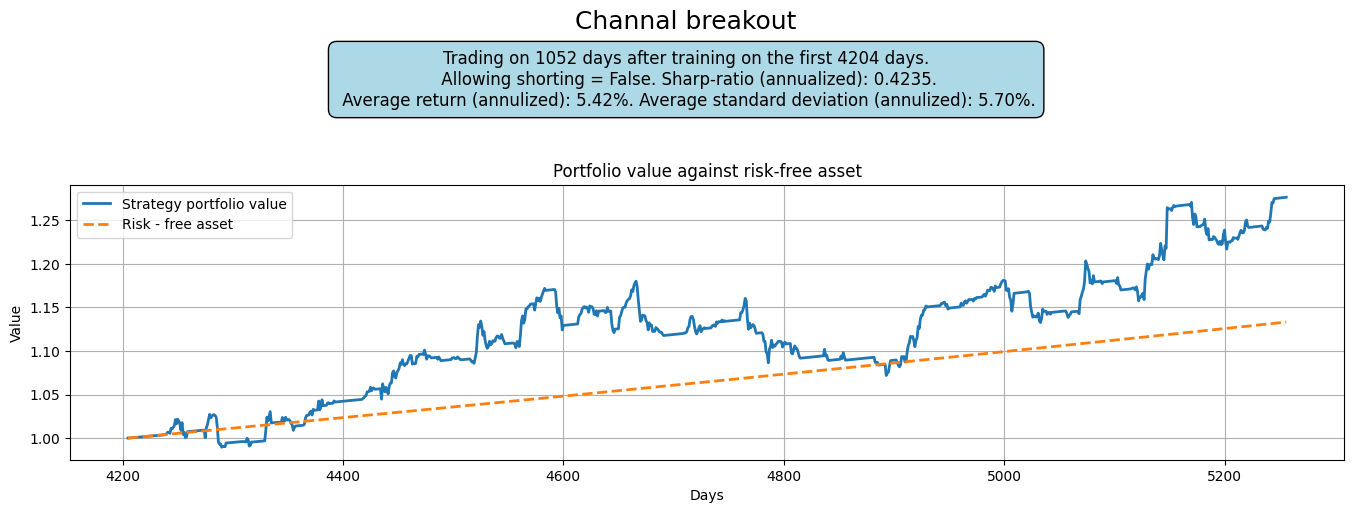

params 0.05, 4, 5, 0.001, 15 checked _0.05_4_5_0.001_15
	 sharp ratio portfolie: 0.4235475013556741
			 0.04193216113435609 0.0334597129015337
	 sharp ratio gurkor: 1.2532134169159006
			 0.0592663678847601 0.15252380847985125
	 sharp ratio guitars: 0.3885712563529996
			 0.1081900335598531 0.11870186219565987
	 sharp ratio slingshots: 0.911443439543688
			 0.007442387369260312 0.15093088704608534
	 sharp ratio stocks: 0.049309902796687656
			 -0.012074478194617839 0.17555981432729245
	 sharp ratio sugar: -0.06877700481106482
			 0.05053501904382328 0.04963227833519887
	 sharp ratio water: 1.0181885808772997
			 -0.038604240197360286 0.15413006117928132
	 sharp ratio tranquillity: -0.25046535310497625


In [ ]:
#sharp_ratios_chan_3 = {}
#print(best_cb_hps) #[[0.05, 4, 5, 0.001, 15]]
for channal_size, days_above, sell_after, above_value, look_back in [[0.05, 4, 5, 0.001, 15]]:
  combine_str = f"_{channal_size}_{days_above}_{sell_after}_{above_value}_{look_back}"
  finance_data_local = test_data.copy()
  cs = 0

  for name in finance_names:
    finance_data_local, cs_1 = channal_breakout(finance_data_local, name, c = channal_size, d = days_above, k = sell_after, x = above_value, j = look_back, combine_str = combine_str)
    cs += cs_1
  if cs == 0:
    print("no found")
    #sharp_ratios_chan_3[combine_str] = -999.
    continue
  print("\t\t\tsa")
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, rebalancing_interval=50000, maximum_in_one_stock=0.5)

  sharp_ratios_bd2, mean_v, std_v = get_sharpe_ratio_v2(finance_data_local, 252, combine_str = combine_str)
  title_v = "Channal breakout"
  plot_time_series(finance_data_local['day'].to_numpy(), finance_data_local["portfolie_value"+combine_str].to_numpy()*1e-2, sharp_ratios_bd2 , mean_v , std_v, title_v)

  print(f"params {channal_size}, {days_above}, {sell_after}, {above_value}, {look_back} checked", combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd2}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


# Buy dip strategy
Similar to mean reversion

First a bit old code

In [ ]:
"""#maximum_in_one_stock = [0]
days_look_backs = [5, 10, 15]#, 20, 30, 40, 50]
streangth_volis = [1.2, 1.4, 1.6, 1.8, 2.0]#, 2.2, 2.4]
days_max_to_sells = [5, 10, 20]#, 30]

print(len(days_look_backs) * len(streangth_volis) * len(days_max_to_sells))
best_bd_hps = []
for i1 in days_look_backs:
  for i2 in streangth_volis:
    for i3 in days_max_to_sells:
          best_bd_hps.append([i1, i2, i3])"""

45


In [ ]:
"""sharp_ratios_bd_1 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_bd_hps:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_local = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local = buy_dip(finance_data_local, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_1[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_1[combine_str]}")
  #for name in finance_names:
  #  finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")
"""

233
412
264
420
271
443
252
426
284
506
245
394
276
470
params 5 1.2 5 checked _5_1.2_5_bd
			 1.1228358189718122 0.44271371763505474
	 sharp ratio portfolie: 2.5362571211254115
233
413
264
421
271
443
252
426
284
511
245
395
276
470
params 5 1.2 10 checked _5_1.2_10_bd
			 1.1233858450027445 0.43702774564490526
	 sharp ratio portfolie: 2.5705137859039286
233
413
264
421
271
443
252
426
284
511
245
395
276
470
params 5 1.2 20 checked _5_1.2_20_bd
			 1.1233858450027445 0.43702774564490526
	 sharp ratio portfolie: 2.5705137859039286
107
166
126
175
118
172
103
141
139
206
106
145
125
197
params 5 1.4 5 checked _5_1.4_5_bd
			 0.4757440687208918 0.17513080520148727
	 sharp ratio portfolie: 2.7165070598148064
107
166
126
175
118
172
103
141
139
206
106
145
125
197
params 5 1.4 10 checked _5_1.4_10_bd
			 0.4757440687208918 0.17513080520148727
	 sharp ratio portfolie: 2.7165070598148064
107
166
126
175
118
172
103
141
139
206
106
145
125
197
params 5 1.4 20 checked _5_1.4_20_bd
			 0.47574

In [ ]:
"""sorted_d = dict(sorted(sharp_ratios_bd_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)"""

_10_1.6_10_bd 3.476747242527863
_10_1.4_10_bd 3.4602261901182856
_10_1.6_5_bd 3.3755781398815894
_10_1.6_20_bd 3.3610711994077813
_10_1.4_5_bd 3.304493835192094
_10_1.4_20_bd 3.2938421702726526
_10_1.8_20_bd 2.870515531704915
_10_1.2_5_bd 2.7305594861364497
_10_1.8_5_bd 2.7236798185664766
_5_1.4_5_bd 2.7165070598148064
_5_1.4_10_bd 2.7165070598148064
_5_1.4_20_bd 2.7165070598148064
_10_1.8_10_bd 2.6649949561841293
_5_1.2_10_bd 2.5705137859039286
_5_1.2_20_bd 2.5705137859039286
_5_1.2_5_bd 2.5362571211254115
_10_1.2_20_bd 2.457394647258044
_10_1.2_10_bd 2.4561652461461922
_10_2.0_20_bd 2.0187697429050186
_10_2.0_10_bd 1.9711186306262143
_5_1.6_5_bd 1.9518148947570844
_5_1.6_10_bd 1.9518148947570844
_5_1.6_20_bd 1.9518148947570844
_15_1.6_5_bd 1.7028997809053352
_10_2.0_5_bd 1.6565973414037527
_15_1.8_5_bd 1.5014384437099373
_15_1.4_5_bd 1.4390271782136221
_15_2.0_5_bd 1.1896972113607884
_15_1.8_20_bd 1.186516758030725
_15_2.0_20_bd 1.18571999243087
_15_2.0_10_bd 1.085863469278568
_15_1.

In [ ]:
"""#maximum_in_one_stock = [0]
days_look_backs = [4, 5, 6, 7, 8, 9, 10]
streangth_volis = [1., 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7]
days_max_to_sells = [5, 10, 20, 30]

print(len(days_look_backs) * len(streangth_volis) * len(days_max_to_sells))
best_bd_hps = []
for i1 in days_look_backs:
  for i2 in streangth_volis:
    for i3 in days_max_to_sells:
          best_bd_hps.append([i1, i2, i3])
          """

224


In [ ]:
"""
sharp_ratios_bd_1 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_bd_hps:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_local = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local = buy_dip(finance_data_local, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_1[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_1[combine_str]}")
  #for name in finance_names:
  #  finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")
"""

406
571
428
578
447
589
432
594
434
610
376
499
437
590
params 4 1.0 5 checked _4_1.0_5_bd
			 1.9296830520020434 0.8133422835409999
	 sharp ratio portfolie: 2.3725350212961964
406
573
428
578
447
589
432
594
434
611
376
499
437
590
params 4 1.0 10 checked _4_1.0_10_bd
			 1.9332868434089758 0.8147482659889977
	 sharp ratio portfolie: 2.372864017160219
406
573
428
578
447
589
432
594
434
611
376
499
437
590
params 4 1.0 20 checked _4_1.0_20_bd
			 1.9332868434089758 0.8147482659889977
	 sharp ratio portfolie: 2.372864017160219
406
573
428
578
447
589
432
594
434
611
376
499
437
590
params 4 1.0 30 checked _4_1.0_30_bd
			 1.9332868434089758 0.8147482659889977
	 sharp ratio portfolie: 2.372864017160219
304
412
322
423
326
414
307
402
330
430
275
350
312
409
params 4 1.1 5 checked _4_1.1_5_bd
			 1.3514237571551644 0.5719857482004667
	 sharp ratio portfolie: 2.3626878141752656
304
413
322
423
326
414
307
402
330
430
275
350
312
409
params 4 1.1 10 checked _4_1.1_10_bd
			 1.3515258230995

KeyboardInterrupt: 

In [ ]:
"""sorted_d = dict(sorted(sharp_ratios_bd_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)"""

In [ ]:
"""
print(days_look_backs)
print(streangth_volis)
print(days_max_to_sells)

for sss in days_max_to_sells:
  M = np.array([[sharp_ratios_bd_1[f"_{s}_{ss}_{sss}_bd"] for s in days_look_backs] for ss in streangth_volis])

  plt.imshow(M, interpolation='nearest')
  plt.colorbar()
  plt.show()

print("\n")
"""

New code with a big grid search

In [ ]:
#maximum_in_one_stock = [0]
days_look_backs = [5, 10, 15]#, 20, 30, 40, 50]
streangth_volis = [1.2, 1.4, 1.6, 1.8, 2.0, 2.2]#, 2.2, 2.4]
days_max_to_sells = [5, 10, 20]#, 30]

print(len(days_look_backs) * len(streangth_volis) * len(days_max_to_sells))
best_bd_hps = []
for i1 in days_look_backs:
  for i2 in streangth_volis:
    for i3 in days_max_to_sells:
          best_bd_hps.append([i1, i2, i3])

54


In [ ]:
sharp_ratios_bd_1 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_bd_hps:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_local = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local = buy_dip(finance_data_local, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_1[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_1[combine_str]}")
  #for name in finance_names:
  #  finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


902
1428
887
1428
916
1395
1032
1609
1011
1589
882
1391
958
1558
params 5 1.2 5 checked _5_1.2_5_bd
			 0.060897638940935056 0.1140953431117956
	 sharp ratio portfolie: 0.533743422650168
902
1428
887
1428
916
1395
1032
1609
1011
1589
882
1392
958
1559
params 5 1.2 10 checked _5_1.2_10_bd
			 0.06077817338089097 0.11411744753767093
	 sharp ratio portfolie: 0.5325931721424779
902
1428
887
1428
916
1395
1032
1609
1011
1589
882
1392
958
1559
params 5 1.2 20 checked _5_1.2_20_bd
			 0.06077817338089097 0.11411744753767093
	 sharp ratio portfolie: 0.5325931721424779
759
1367
761
1362
791
1339
885
1548
853
1519
750
1327
803
1475
params 5 1.4 5 checked _5_1.4_5_bd
			 0.06772413753307478 0.11308894628848039
	 sharp ratio portfolie: 0.5988572690412749
759
1368
761
1363
791
1343
885
1550
853
1519
750
1329
803
1476
params 5 1.4 10 checked _5_1.4_10_bd
			 0.06817366815900387 0.11277461085959414
	 sharp ratio portfolie: 0.6045125550810455
759
1368
761
1363
791
1343
885
1550
853
1519
750
1329
803
1

In [ ]:
sorted_d = dict(sorted(sharp_ratios_bd_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_5_1.8_10_bd 0.6082122466777815
_5_1.8_20_bd 0.6082122466777815
_5_1.4_10_bd 0.6045125550810455
_5_1.4_20_bd 0.6045125550810455
_5_1.4_5_bd 0.5988572690412749
_10_1.8_5_bd 0.5917187616066536
_5_1.8_5_bd 0.5886772143359842
_5_1.6_10_bd 0.5808675204989583
_5_1.6_20_bd 0.5808675204989583
_5_1.6_5_bd 0.576876231814926
_5_2.2_10_bd 0.5388860206925232
_5_2.2_20_bd 0.5388860206925232
_5_1.2_5_bd 0.533743422650168
_5_1.2_10_bd 0.5325931721424779
_5_1.2_20_bd 0.5325931721424779
_10_2.0_5_bd 0.5101618961654806
_5_2.0_10_bd 0.5070350422443947
_5_2.0_20_bd 0.5070350422443947
_10_1.6_5_bd 0.4990865549214456
_5_2.0_5_bd 0.49392928249763857
_5_2.2_5_bd 0.48728702607299573
_10_1.6_20_bd 0.4816084170038197
_10_1.6_10_bd 0.4802816314418686
_10_1.8_20_bd 0.4704608132231109
_10_1.8_10_bd 0.46729344605939616
_10_1.4_20_bd 0.45477952070864675
_10_1.4_10_bd 0.4499228390671701
_10_1.2_20_bd 0.4277552065190903
_10_1.2_10_bd 0.4226662090983877
_10_1.2_5_bd 0.4223041578551914
_10_1.4_5_bd 0.4112004571409261
_10_

In [ ]:
#maximum_in_one_stock = [0]
days_look_backs = [5, 7, 10, 15]
streangth_volis = [1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.5, 3.0, 3.5, 4.0]
days_max_to_sells = [5, 10, 20]

print(len(days_look_backs) * len(streangth_volis) * len(days_max_to_sells))
best_bd_hps = []
for i1 in days_look_backs:
  for i2 in streangth_volis:
    for i3 in days_max_to_sells:
          best_bd_hps.append([i1, i2, i3])

144


In [ ]:
sharp_ratios_bd_1 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_bd_hps:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_local = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local = buy_dip(finance_data_local, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_1[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_1[combine_str]}")
  #for name in finance_names:
  #  finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


759
1367
761
1362
791
1339
885
1548
853
1519
750
1327
803
1475
params 5 1.4 5 checked _5_1.4_5_bd
			 0.06772413753307478 0.11308894628848039
	 sharp ratio portfolie: 0.5988572690412749
759
1368
761
1363
791
1343
885
1550
853
1519
750
1329
803
1476
params 5 1.4 10 checked _5_1.4_10_bd
			 0.06817366815900387 0.11277461085959414
	 sharp ratio portfolie: 0.6045125550810455
759
1368
761
1363
791
1343
885
1550
853
1519
750
1329
803
1476
params 5 1.4 20 checked _5_1.4_20_bd
			 0.06817366815900387 0.11277461085959414
	 sharp ratio portfolie: 0.6045125550810455
699
1347
718
1331
739
1318
805
1508
800
1507
686
1302
733
1436
params 5 1.5 5 checked _5_1.5_5_bd
			 0.06184134883757883 0.10961038918658546
	 sharp ratio portfolie: 0.5641924027138406
699
1349
718
1334
739
1322
805
1510
800
1507
686
1305
733
1437
params 5 1.5 10 checked _5_1.5_10_bd
			 0.06270978209906032 0.10938904628906948
	 sharp ratio portfolie: 0.5732729576354895
699
1349
718
1334
739
1322
805
1510
800
1507
686
1305
733
1437
p

In [ ]:
sorted_d = dict(sorted(sharp_ratios_bd_1.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_7_4.0_20_bd 0.801226245536331
_7_2.0_5_bd 0.748307530037606
_7_2.1_5_bd 0.7276026546307558
_7_2.1_20_bd 0.7274128448476128
_7_2.0_10_bd 0.7222460248736509
_7_2.1_10_bd 0.7211861796006473
_7_2.0_20_bd 0.7162933966818992
_7_2.5_20_bd 0.7139991405983173
_7_1.9_5_bd 0.6911671051121971
_7_2.5_10_bd 0.683469321766728
_7_4.0_10_bd 0.6794926223112645
_7_1.9_20_bd 0.6621662099964434
_7_1.9_10_bd 0.6613854065308689
_5_1.9_10_bd 0.6303027316802791
_5_1.9_20_bd 0.6303027316802791
_5_1.7_10_bd 0.6258186287186609
_5_1.7_20_bd 0.6258186287186609
_7_1.8_5_bd 0.6205212800239049
_7_1.8_20_bd 0.6162180079736576
_7_1.8_10_bd 0.615676924353477
_5_1.7_5_bd 0.615355874378415
_10_4.0_20_bd 0.612176216185955
_5_1.8_10_bd 0.6082122466777815
_5_1.8_20_bd 0.6082122466777815
_5_1.4_10_bd 0.6045125550810455
_5_1.4_20_bd 0.6045125550810455
_5_1.9_5_bd 0.6024228452150293
_5_1.4_5_bd 0.5988572690412749
_10_1.8_5_bd 0.5917187616066536
_5_1.8_5_bd 0.5886772143359842
_5_1.6_10_bd 0.5808675204989583
_5_1.6_20_bd 0.580867

[5, 7, 10, 15]
[1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.5, 3.0, 3.5, 4.0]
[5, 10, 20]


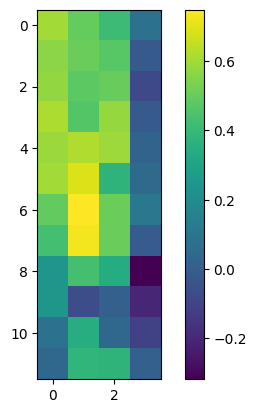

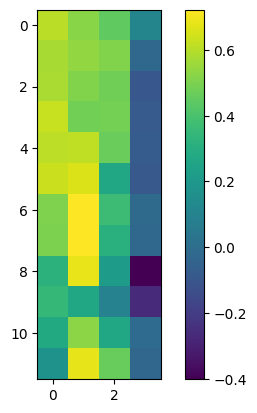

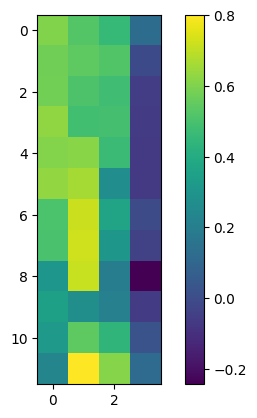

In [ ]:
print(days_look_backs)
print(streangth_volis)
print(days_max_to_sells)

for sss in days_max_to_sells:
  M = np.array([[sharp_ratios_bd_1[f"_{s}_{ss}_{sss}_bd"] for s in days_look_backs] for ss in streangth_volis])

  plt.imshow(M, interpolation='nearest')
  plt.colorbar()
  plt.show()

print("\n")

Smaller grid search (more step between have been used)

In [ ]:
#maximum_in_one_stock = [0]
days_look_backs1 = [4]#[3, 4, 5, 8, 9, 10]
streangth_volis1 = [1.5, 1.525, 1.55, 1.575, 1.6, 1.625, 1.65, 1.675, 1.7]#[1.5, 1.60, 1.7, 3.5, 4.0, 5.0]
days_max_to_sells1 = [5, 10, 20, 30, 50]

print(len(days_look_backs1) * len(streangth_volis1) * len(days_max_to_sells1))
best_bd_hps1 = []
for i1 in days_look_backs1:
  for i2 in streangth_volis1:
    for i3 in days_max_to_sells1:
          best_bd_hps1.append([i1, i2, i3])

45


In [ ]:
sharp_ratios_bd_2 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_bd_hps1:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_local = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local = buy_dip(finance_data_local, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_2[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_2[combine_str]}")
  #for name in finance_names:
  #  finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


729
1374
736
1342
772
1317
806
1474
823
1515
713
1321
769
1434
params 4 1.5 5 checked _4_1.5_5_bd
			 0.08002714480708138 0.1070827132347257
	 sharp ratio portfolie: 0.7473395321209465
729
1375
736
1344
772
1317
806
1477
823
1515
713
1324
769
1434
params 4 1.5 10 checked _4_1.5_10_bd
			 0.08099665981603807 0.10635100607615
	 sharp ratio portfolie: 0.7615974949784906
729
1375
736
1344
772
1317
806
1477
823
1515
713
1324
769
1434
params 4 1.5 20 checked _4_1.5_20_bd
			 0.08099665981603807 0.10635100607615
	 sharp ratio portfolie: 0.7615974949784906
729
1375
736
1344
772
1317
806
1477
823
1515
713
1324
769
1434
params 4 1.5 30 checked _4_1.5_30_bd
			 0.08099665981603807 0.10635100607615
	 sharp ratio portfolie: 0.7615974949784906
729
1375
736
1344
772
1317
806
1477
823
1515
713
1324
769
1434
params 4 1.5 50 checked _4_1.5_50_bd
			 0.08099665981603807 0.10635100607615
	 sharp ratio portfolie: 0.7615974949784906
717
1369
724
1337
757
1309
786
1468
807
1514
708
1320
753
1421
params 4 1.5

In [ ]:
sorted_d = dict(sorted(sharp_ratios_bd_2.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_4_1.6_10_bd 0.8537148223391482
_4_1.6_20_bd 0.8537148223391482
_4_1.6_30_bd 0.8537148223391482
_4_1.6_50_bd 0.8537148223391482
_4_1.625_10_bd 0.850115690682043
_4_1.625_20_bd 0.850115690682043
_4_1.625_30_bd 0.850115690682043
_4_1.625_50_bd 0.850115690682043
_4_1.6_5_bd 0.8403339099096413
_4_1.625_5_bd 0.8361696790796531
_4_1.65_10_bd 0.8323301422710981
_4_1.65_20_bd 0.8323301422710981
_4_1.65_30_bd 0.8323301422710981
_4_1.65_50_bd 0.8323301422710981
_4_1.65_5_bd 0.8162782458394131
_4_1.675_10_bd 0.8158400946543893
_4_1.675_20_bd 0.8158400946543893
_4_1.675_30_bd 0.8158400946543893
_4_1.675_50_bd 0.8158400946543893
_4_1.7_10_bd 0.80959999098479
_4_1.7_20_bd 0.80959999098479
_4_1.7_30_bd 0.80959999098479
_4_1.7_50_bd 0.80959999098479
_4_1.675_5_bd 0.8002427862068586
_4_1.55_10_bd 0.8001850212004071
_4_1.55_20_bd 0.8001850212004071
_4_1.55_30_bd 0.8001850212004071
_4_1.55_50_bd 0.8001850212004071
_4_1.575_10_bd 0.7981599233075679
_4_1.575_20_bd 0.7981599233075679
_4_1.575_30_bd 0.798159

[4]
[1.5, 1.525, 1.55, 1.575, 1.6, 1.625, 1.65, 1.675, 1.7]
[5, 10, 20, 30, 50]


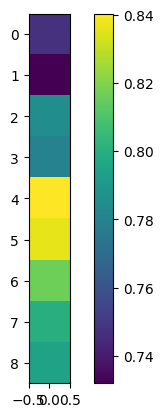

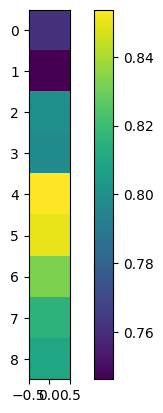

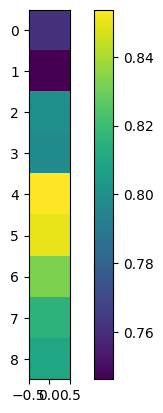

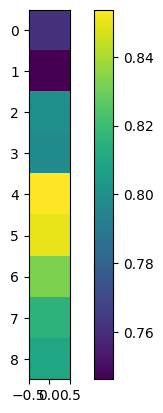

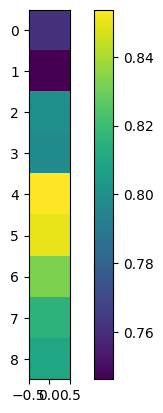

In [ ]:
print(days_look_backs1)
print(streangth_volis1)
print(days_max_to_sells1)

for sss in days_max_to_sells1:
  M = np.array([[sharp_ratios_bd_2[f"_{s}_{ss}_{sss}_bd"] for s in days_look_backs1] for ss in streangth_volis1])

  plt.imshow(M, interpolation='nearest')
  plt.colorbar()
  plt.show()

print("\n") #4, 9  4.5, 10

In [ ]:
#maximum_in_one_stock = [0]
days_look_backs2 = [4, 9, 10]
streangth_volis2 = [1.6, 4., 4.5]
days_max_to_sells2 = [3, 5, 7, 10, 12, 15, 17, 20, 22, 25, 27, 30, 35, 40, 50, 55, 60]

print(len(days_look_backs2) * len(streangth_volis2) * len(days_max_to_sells2))
best_bd_hps2 = []
for i1 in days_look_backs2:
  for i2 in streangth_volis2:
    for i3 in days_max_to_sells2:
          best_bd_hps2.append([i1, i2, i3])

153


In [ ]:
sharp_ratios_bd_3 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_bd_hps2:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_local = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local = buy_dip(finance_data_local, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_3[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_3[combine_str]}")
  #for name in finance_names:
  #  finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
  #  print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


679
1317
693
1293
714
1277
739
1402
757
1460
674
1258
716
1367
params 4 1.6 3 checked _4_1.6_3_bd
			 0.09235427518948953 0.10432750703787734
	 sharp ratio portfolie: 0.8852341804348801
679
1341
693
1315
714
1284
739
1424
757
1483
674
1283
716
1392
params 4 1.6 5 checked _4_1.6_5_bd
			 0.08709339512395749 0.10364141455784212
	 sharp ratio portfolie: 0.8403339099096413
679
1343
693
1317
714
1284
739
1427
757
1483
674
1288
716
1392
params 4 1.6 7 checked _4_1.6_7_bd
			 0.08798661659353153 0.10306324113297148
	 sharp ratio portfolie: 0.8537148223391482
679
1343
693
1317
714
1284
739
1427
757
1483
674
1288
716
1392
params 4 1.6 10 checked _4_1.6_10_bd
			 0.08798661659353153 0.10306324113297148
	 sharp ratio portfolie: 0.8537148223391482
679
1343
693
1317
714
1284
739
1427
757
1483
674
1288
716
1392
params 4 1.6 12 checked _4_1.6_12_bd
			 0.08798661659353153 0.10306324113297148
	 sharp ratio portfolie: 0.8537148223391482
679
1343
693
1317
714
1284
739
1427
757
1483
674
1288
716
1392
par

In [ ]:
sorted_d = dict(sorted(sharp_ratios_bd_3.items(), key=lambda x: -x[1]))
for key, value in sorted_d.items():
  print(key, value)

_10_4.5_22_bd 1.007337949481467
_10_4.5_20_bd 0.9995257720472142
_10_4.5_25_bd 0.9922203425651874
_10_4.5_27_bd 0.9922203425651874
_10_4.5_30_bd 0.9922203425651874
_10_4.5_35_bd 0.9922203425651874
_10_4.5_40_bd 0.9922203425651874
_10_4.5_50_bd 0.9922203425651874
_10_4.5_55_bd 0.9922203425651874
_10_4.5_60_bd 0.9922203425651874
_10_4.5_17_bd 0.8937471798233664
_4_1.6_3_bd 0.8852341804348801
_4_1.6_7_bd 0.8537148223391482
_4_1.6_10_bd 0.8537148223391482
_4_1.6_12_bd 0.8537148223391482
_4_1.6_15_bd 0.8537148223391482
_4_1.6_17_bd 0.8537148223391482
_4_1.6_20_bd 0.8537148223391482
_4_1.6_22_bd 0.8537148223391482
_4_1.6_25_bd 0.8537148223391482
_4_1.6_27_bd 0.8537148223391482
_4_1.6_30_bd 0.8537148223391482
_4_1.6_35_bd 0.8537148223391482
_4_1.6_40_bd 0.8537148223391482
_4_1.6_50_bd 0.8537148223391482
_4_1.6_55_bd 0.8537148223391482
_4_1.6_60_bd 0.8537148223391482
_10_4.5_15_bd 0.8467011785563031
_9_4.0_30_bd 0.8421662314596596
_9_4.0_35_bd 0.8421662314596596
_9_4.0_40_bd 0.8421662314596596

The first 4.5 have to few trades to be valid

In [ ]:
best_hyper_bd = [[4, 1.6, 3]]#, [10, 4.5, 22]]#, [9, 4.0, 30]

In [ ]:
sharp_ratios_bd_4 = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_hyper_bd:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_local = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local = buy_dip(finance_data_local, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_4[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_4[combine_str]}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")
  print(finance_data_local["portfolie_value" + combine_str].to_numpy())

679
1317
693
1293
714
1277
739
1402
757
1460
674
1258
716
1367
params 4 1.6 3 checked _4_1.6_3_bd
			 0.09235427518948953 0.10432750703787734
	 sharp ratio portfolie: 0.8852341804348801
			 0.0046375478338423525 0.06019565223162057
	 sharp ratio gurkor: 0.07704124238072903
			 0.043228436389543434 0.25812141817777
	 sharp ratio guitars: 0.16747326391865594
			 0.007080554171780506 0.18214730219050757
	 sharp ratio slingshots: 0.03887268209097583
			 -0.033721714535568784 0.22957808602405672
	 sharp ratio stocks: -0.1468855983581778
			 -0.03946019967202914 0.2209854198486274
	 sharp ratio sugar: -0.17856472023837114
			 2.650809792238979e-06 0.05179534393445959
	 sharp ratio water: 5.117853441794385e-05
			 0.026064750902750993 0.2130171849513356
	 sharp ratio tranquillity: 0.1223598504914313
[100.         100.         100.01173037 ... 590.7241801  590.42058019
 587.36071129]
17
159
13
110
10
56
16
116
13
139
20
159
21
223
params 10 4.5 22 checked _10_4.5_22_bd
			 0.023843721607801675

Testing

In [ ]:
sharp_ratios_bd_v = {}
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_hyper_bd:
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_local = test_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local = buy_dip(finance_data_local, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd_v[combine_str] = get_sharpe_ratio(finance_data_local, 252, combine_str = combine_str)

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd_v[combine_str]}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


153
295
177
317
156
279
177
328
171
316
167
311
185
371
params 4 1.6 3 checked _4_1.6_3_bd
			 0.17116935174062256 0.08977528001013235
	 sharp ratio portfolie: 1.906642359915823
			 0.04184422316770388 0.03385499365920027
	 sharp ratio gurkor: 1.235983783926437
			 0.06973647919338327 0.15747264940878514
	 sharp ratio guitars: 0.44284819906950007
			 0.1216381486451731 0.12850613899637728
	 sharp ratio slingshots: 0.946555157560233
			 0.009016444262231704 0.15068919047977725
	 sharp ratio stocks: 0.059834711657315104
			 0.0018788989344952454 0.17286154418335112
	 sharp ratio sugar: 0.010869386498724848
			 0.05096792560261406 0.04986391804006029
	 sharp ratio water: 1.0221404094573319
			 -0.0135389222981562 0.1765905729501334
	 sharp ratio tranquillity: -0.07666843179663613


Plotting

679
1317
693
1293
714
1277
739
1402
757
1460
674
1258
716
1367
153
295
177
317
156
279
177
328
171
316
167
311
185
371
832
1614
871
1613
871
1559
918
1733
928
1776
842
1572
902
1742
params 4 1.6 3 checked _4_1.6_3_bd
			 0.11406949860054193 0.11545469874679025


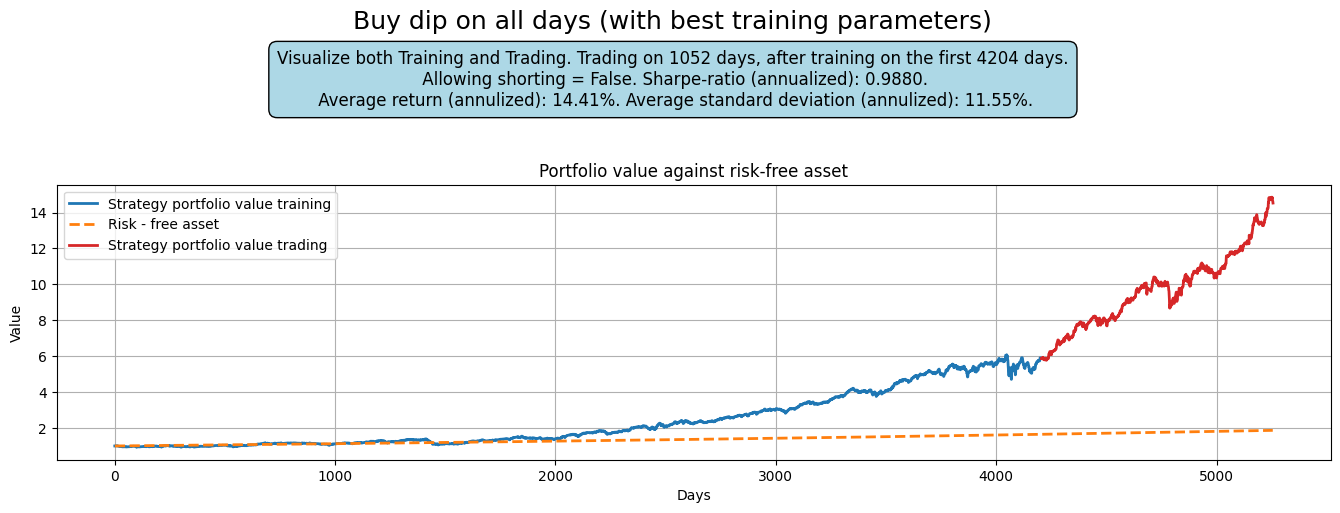

	 sharp ratio portfolie: 0.9880022193874822
			 0.010837218445622953 0.057651156202362476
	 sharp ratio gurkor: 0.18797920387898234
			 0.048195939835790014 0.2456788737431388
	 sharp ratio guitars: 0.19617453915137872
			 0.031595063417420535 0.19313076293101886
	 sharp ratio slingshots: 0.16359415215848055
			 -0.023584585293182143 0.2161667352427512
	 sharp ratio stocks: -0.1091036753027569
			 -0.029168607105503036 0.2170080501172181
	 sharp ratio sugar: -0.13441255792007462
			 0.00942469142447421 0.05408470294215177
	 sharp ratio water: 0.1742579863026099
			 0.020692314165192034 0.2256097522166034
	 sharp ratio tranquillity: 0.0917172859856065
17
159
13
110
10
56
16
116
13
139
20
159
21
223
2
10
2
9
2
17
4
33
4
22
5
36
4
36
19
169
15
119
12
73
20
149
17
161
25
214
25
259
params 10 4.5 22 checked _10_4.5_22_bd
			 0.020729802264507886 0.02679483409385945


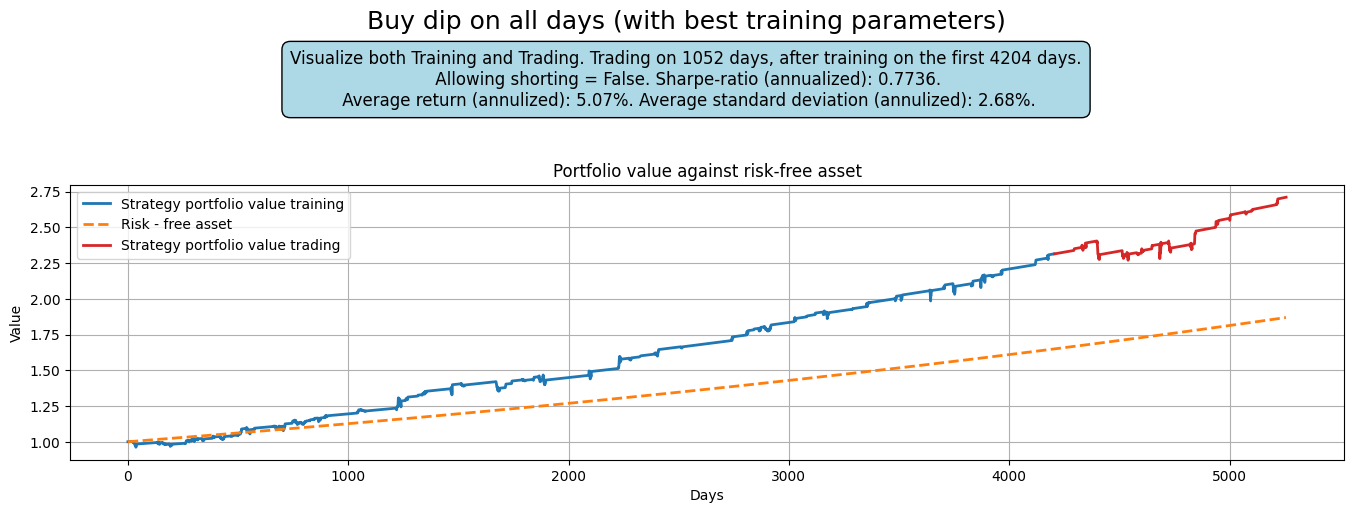

	 sharp ratio portfolie: 0.7736492113328113
			 0.015173797184072121 0.05311173301676476
	 sharp ratio gurkor: 0.28569576479988895
			 0.04530375673431337 0.2443028664535636
	 sharp ratio guitars: 0.18544095446757508
			 0.03079598443750483 0.19303127782709334
	 sharp ratio slingshots: 0.1595388311374603
			 -0.021058613446532558 0.2150772592989391
	 sharp ratio stocks: -0.09791185509418678
			 -0.021585696257982297 0.21243018118851367
	 sharp ratio sugar: -0.10161313301722806
			 0.00970502809278122 0.05208644581476526
	 sharp ratio water: 0.18632540464164435
			 0.02430190730811719 0.2246042474606551
	 sharp ratio tranquillity: 0.10819878779173248


In [ ]:
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_hyper_bd+ [[10, 4.5, 22]]: #8, 1.5, 5
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"

  finance_data_local0 = training_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local0 = buy_dip(finance_data_local0, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local0 = stocks_positions(finance_data_local0, finance_names, combine_str)

  finance_data_local0 = several_stock_trade(finance_data_local0, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)


  finance_data_local1 = test_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local1 = buy_dip(finance_data_local1, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local1 = stocks_positions(finance_data_local1, finance_names, combine_str)

  finance_data_local1 = several_stock_trade(finance_data_local1, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)


  finance_data_local2 = finance_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local2 = buy_dip(finance_data_local2, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local2 = stocks_positions(finance_data_local2, finance_names, combine_str)

  finance_data_local2 = several_stock_trade(finance_data_local2, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd2, mean_v, std_v = get_sharpe_ratio_v2(finance_data_local2, 252, combine_str = combine_str)
  plot_time_series_v2(finance_data_local0['day'].to_numpy(), finance_data_local0["portfolie_value"+combine_str].to_numpy()*1e-2, finance_data_local1['day'].to_numpy(), finance_data_local1["portfolie_value"+combine_str].to_numpy()*1e-2, sharp_ratios_bd2 , mean_v , std_v, "Buy dip on all days (with best training parameters)")

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd2}")
  for name in finance_names:
    finance_data_local2 = one_stock_trade(finance_data_local2, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local2, name, 252, combine_str = combine_str)}")


153
295
177
317
156
279
177
328
171
316
167
311
185
371
params 4 1.6 3 checked _4_1.6_3_bd
			 0.17116935174062256 0.08977528001013235


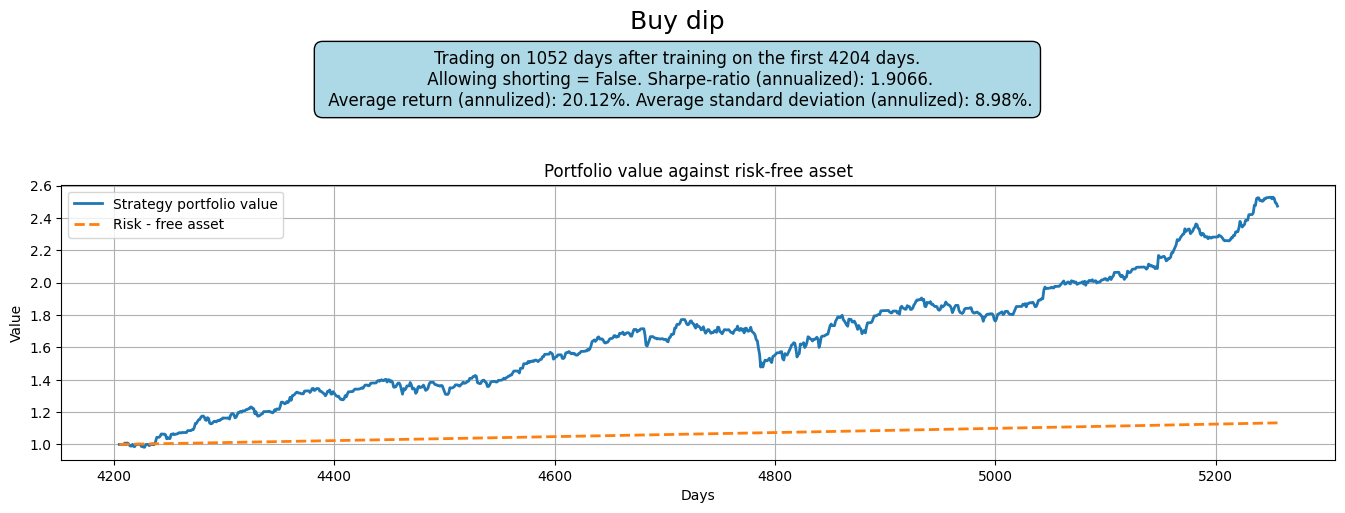

	 sharp ratio portfolie: 1.906642359915823
			 0.04184422316770388 0.03385499365920027
	 sharp ratio gurkor: 1.235983783926437
			 0.06973647919338327 0.15747264940878514
	 sharp ratio guitars: 0.44284819906950007
			 0.1216381486451731 0.12850613899637728
	 sharp ratio slingshots: 0.946555157560233
			 0.009016444262231704 0.15068919047977725
	 sharp ratio stocks: 0.059834711657315104
			 0.0018788989344952454 0.17286154418335112
	 sharp ratio sugar: 0.010869386498724848
			 0.05096792560261406 0.04986391804006029
	 sharp ratio water: 1.0221404094573319
			 -0.0135389222981562 0.1765905729501334
	 sharp ratio tranquillity: -0.07666843179663613


In [ ]:
#print(best_bd_hps)
for days_look_back, streangth_voli, days_max_to_sell in best_hyper_bd: #8, 1.5, 5
  combine_str = f"_{days_look_back}_{streangth_voli}_{days_max_to_sell}_bd"
  finance_data_local = test_data.copy()
  cs = 0

  #for name in finance_names:
  finance_data_local = buy_dip(finance_data_local, finance_names, d = days_look_back, k = streangth_voli, max_k = days_max_to_sell, combine_str = combine_str)
  finance_data_local = stocks_positions(finance_data_local, finance_names, combine_str)

  finance_data_local = several_stock_trade(finance_data_local, finance_names, combine_str = combine_str, rebalancing_interval=50000, replacing_weight=2., maximum_in_one_stock=0.5)

  print(f"params {days_look_back} {streangth_voli} {days_max_to_sell} checked", combine_str)
  sharp_ratios_bd2, mean_v, std_v = get_sharpe_ratio_v2(finance_data_local, 252, combine_str = combine_str)
  plot_time_series(finance_data_local['day'].to_numpy(), finance_data_local["portfolie_value"+combine_str].to_numpy()*1e-2, sharp_ratios_bd2 , mean_v , std_v, "Buy dip")

  print(f"\t sharp ratio portfolie: {sharp_ratios_bd2}")
  for name in finance_names:
    finance_data_local = one_stock_trade(finance_data_local, name, combine_str)
    print(f"\t sharp ratio {name}: {get_sharpe_ratio_one_stock(finance_data_local, name, 252, combine_str = combine_str)}")


#old code following few cells

In [ ]:
#print(finance_data)
#print(finance_names)

      Unnamed: 0   day    gurkor   guitars  slingshots     stocks     sugar  \
0              0     1  6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2  6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3  6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4  6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5  6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...       ...       ...         ...        ...       ...   
5451        5451  5452       NaN       NaN         NaN        NaN       NaN   
5452        5452  5453       NaN       NaN         NaN        NaN       NaN   
5453        5453  5454       NaN       NaN         NaN        NaN       NaN   
5454        5454  5455       NaN       NaN         NaN        NaN       NaN   
5455        5455  5456       NaN       NaN         NaN        NaN       NaN   

         water  tranquillity  
0     3.896149      

In [ ]:
#for name in finance_names:
#  finance_data = remove_1000(finance_data, name)

[ 6.31581555  6.825179    9.27880519  9.05006504 11.37014512] [ 6.26452498  6.85266821  9.181506    9.04200502 11.46444389]
[2.83043642 5.74900107 4.85888389 6.81445677 5.05114593] [2.85406559 5.41987344 4.85304529 6.82222064 4.90162681]
[2.05786636 3.39560267 3.81753475 4.92829802 3.06994825] [2.07016982 3.44239554 3.88330984 4.92515297 3.00913931]
[9.10307757 8.68991977 6.27277201 5.13249983 4.63075894] [8.83745388 8.8367195  6.20489274 5.0972318  4.54038977]
[3.57234686 3.39488235 2.07917243 3.30055146 1.760932  ] [3.64148906 3.23149229 2.07161867 3.30825403 1.72400296]
[3.97410653 4.69767736 5.89565424 6.21961548 6.6929798 ] [3.99621039 4.704141   5.88280296 6.20774392 6.7114342 ]
[ 7.46344565 10.34647171 10.41322314 18.65861411 10.20343293] [ 7.40623013 10.29561348 10.40686586 19.16719644  9.89192626]


In [ ]:
#periods = [[4, 15],
#           [7, 25],
#           [14, 50],
#           [25, 100],
#           [50, 200]]

In [ ]:
#finance_data_buy = finance_data.copy()

#for i, name in enumerate(finance_names):
#  for short_window, long_window in periods:
#    finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window, long_window)
  #finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window = 4, long_window = 15)
  #finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window = 7, long_window = 25)
  #finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window = 14, long_window = 50)
  #finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window = 25, long_window = 100)
  #finance_data_buy = moving_avarage_cross_over(finance_data_buy, name, short_window = 50, long_window = 200)


In [ ]:
#params_grid = []
#count = 0
#for k in [50]:#[1, 5, 10]:
#  for d in [2]:#[1, 2, 3]:
#    for x in [0.005, 0.05]:#[0.001, 0.005, 0.01, 0.05]:
#      for c in [0.01, 0.05]:#[0.005, 0.01, 0.05, 0.1]:
#        for j in [5, 8]:#, 20, 25]:
#          params_grid.append([k, d, x, c, j])
#          count += 1
#print(count)

8


In [ ]:
#
#for i in range(len(params_grid)):
#  for j, name in enumerate(finance_names):#
#
# #   print(i)
# #   print(params_grid[i])
#    combine_str = "_" + "_".join([str(j) for j in params_grid[i]])
#    finance_data_buy = channal_breakout(finance_data_buy, name, x = params_grid[i][2], d = params_grid[i][1], j = params_grid[i][4], c = params_grid[i][3], k = params_grid[i][0], combine_str=combine_str)

0
[50, 2, 0.005, 0.01, 5]
793 897
0
[50, 2, 0.005, 0.01, 5]
1232 1400
0
[50, 2, 0.005, 0.01, 5]
1287 1309
0
[50, 2, 0.005, 0.01, 5]
776 612
0
[50, 2, 0.005, 0.01, 5]
1397 1154
0
[50, 2, 0.005, 0.01, 5]
685 592
0
[50, 2, 0.005, 0.01, 5]
1094 2267
1
[50, 2, 0.005, 0.01, 8]
495 669
1
[50, 2, 0.005, 0.01, 8]
395 280
1
[50, 2, 0.005, 0.01, 8]
219 372
1
[50, 2, 0.005, 0.01, 8]
51 0
1
[50, 2, 0.005, 0.01, 8]
51 153
1
[50, 2, 0.005, 0.01, 8]
587 732
1
[50, 2, 0.005, 0.01, 8]
436 282
2
[50, 2, 0.005, 0.05, 5]
0 0
2
[50, 2, 0.005, 0.05, 5]
1189 1387
2
[50, 2, 0.005, 0.05, 5]
1154 1028
2
[50, 2, 0.005, 0.05, 5]
1520 2565
2
[50, 2, 0.005, 0.05, 5]
1200 1642
2
[50, 2, 0.005, 0.05, 5]
0 0
2
[50, 2, 0.005, 0.05, 5]
891 1452
3
[50, 2, 0.005, 0.05, 8]
0 0
3
[50, 2, 0.005, 0.05, 8]
1045 1711
3
[50, 2, 0.005, 0.05, 8]
988 1625
3
[50, 2, 0.005, 0.05, 8]
1899 2509
3
[50, 2, 0.005, 0.05, 8]
1433 2066
3
[50, 2, 0.005, 0.05, 8]
0 0
3
[50, 2, 0.005, 0.05, 8]
942 1658
4
[50, 2, 0.05, 0.01, 5]
0 0
4
[50, 2, 0.05

In [ ]:
#print(finance_data_buy)

      Unnamed: 0   day    gurkor   guitars  slingshots     stocks     sugar  \
0              0     1  6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2  6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3  6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4  6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5  6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...       ...       ...         ...        ...       ...   
5451        5451  5452       NaN       NaN         NaN        NaN       NaN   
5452        5452  5453       NaN       NaN         NaN        NaN       NaN   
5453        5453  5454       NaN       NaN         NaN        NaN       NaN   
5454        5454  5455       NaN       NaN         NaN        NaN       NaN   
5455        5455  5456       NaN       NaN         NaN        NaN       NaN   

         water  tranquillity  gurkor_signal_4_15  .

In [ ]:
#for short_window, long_window in periods:
#  long_window_text = "_" + str(long_window)
#  short_window_text = "_" + str(short_window)
#  combine_str = short_window_text + long_window_text
#  finance_data_buy = get_return_portfolie(finance_data_buy, finance_names, combine_str = combine_str)
#  print(f"short window {short_window}, long window {long_window} checked")

short window 4, long window 15 checked
short window 7, long window 25 checked
short window 14, long window 50 checked
short window 25, long window 100 checked
short window 50, long window 200 checked


In [ ]:
#for i in range(len(params_grid)):
#    print(i)
#    print(params_grid[i])
#    combine_str = "_" + "_".join([str(j) for j in params_grid[i]])
#    finance_data_buy = get_return_portfolie(finance_data_buy, finance_names, False, combine_str= combine_str, lend_possible = True)
#    print(combine_str," checked")

0
[50, 2, 0.005, 0.01, 5]
_50_2_0.005_0.01_5  checked
1
[50, 2, 0.005, 0.01, 8]
_50_2_0.005_0.01_8  checked
2
[50, 2, 0.005, 0.05, 5]
_50_2_0.005_0.05_5  checked
3
[50, 2, 0.005, 0.05, 8]
_50_2_0.005_0.05_8  checked
4
[50, 2, 0.05, 0.01, 5]
_50_2_0.05_0.01_5  checked
5
[50, 2, 0.05, 0.01, 8]
_50_2_0.05_0.01_8  checked
6
[50, 2, 0.05, 0.05, 5]


/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name + "_change" + combine_str] = df[name]/df[name].shift(1)
/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name + "_change" + combine_str] = df[name]/df[name].shift(1)
/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axi

_50_2_0.05_0.05_5  checked
7
[50, 2, 0.05, 0.05, 8]


/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name + "_change" + combine_str] = df[name]/df[name].shift(1)
/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name + "_change" + combine_str] = df[name]/df[name].shift(1)
/tmp/ipykernel_2727/2382786547.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axi

_50_2_0.05_0.05_8  checked


In [ ]:
#sharp_ratios_2 = {}
#for averaging_time in [1, 5, 21, 63, 252]:
#  print(f"Averaging time: {averaging_time}\n\t\tshort,  long,   sharpratio")
#  for i in range(len(params_grid)):
#    print(i)
#    combine_str = "_" + "_".join([str(j) for j in params_grid[i]])
#    print(combine_str," checked")
#    sharp_ratios_2[combine_str] = get_sharpe_ratio(finance_data_buy, finance_names, averaging_time, combine_str = combine_str)
#    print(f"\t\t "+combine_str+f": \t{sharp_ratios_2[combine_str]:4f}")
#print("\n", sharp_ratios_2)

Averaging time: 1
		short,  long,   sharpratio
0
_50_2_0.005_0.01_5  checked
247 5256
1.0002320062660313 0.00827811433947272
		 _50_2_0.005_0.01_5: 	0.013856
1
_50_2_0.005_0.01_8  checked
247 5256
1.0001404505415228 0.004309093255922443
		 _50_2_0.005_0.01_8: 	0.005372
2
_50_2_0.005_0.05_5  checked
247 5256
0.9999638897836165 0.011818216018397007
		 _50_2_0.005_0.05_5: 	-0.012981
3
_50_2_0.005_0.05_8  checked
247 5256
1.0001342050049762 0.01072560718934694
		 _50_2_0.005_0.05_8: 	0.001576
4
_50_2_0.05_0.01_5  checked
247 5256
1.0001173037138344 1.354472090042691e-14
		 _50_2_0.05_0.01_5: 	 nan
5
_50_2_0.05_0.01_8  checked
247 5256
1.0001173037138344 1.354472090042691e-14
		 _50_2_0.05_0.01_8: 	 nan
6
_50_2_0.05_0.05_5  checked
247 5256
1.0001173037138344 1.354472090042691e-14
		 _50_2_0.05_0.05_5: 	 nan
7
_50_2_0.05_0.05_8  checked
247 5256
1.0001173037138344 1.354472090042691e-14
		 _50_2_0.05_0.05_8: 	 nan
Averaging time: 5
		short,  long,   sharpratio
0
_50_2_0.005_0.01_5  checked
2

/tmp/ipykernel_2727/2382786547.py:112: RuntimeWarning: invalid value encountered in scalar divide
  return np.mean(returns - cost_rent) / np.std(returns - cost_rent)


247 5256
0.9998096237964129 0.02572763954498904
		 _50_2_0.005_0.05_5: 	-0.030202
3
_50_2_0.005_0.05_8  checked
247 5256
1.0006613259670891 0.024200740341866055
		 _50_2_0.005_0.05_8: 	0.003085
4
_50_2_0.05_0.01_5  checked
247 5256
1.0005866561869274 2.5757174171303632e-14
		 _50_2_0.05_0.01_5: 	-inf
5
_50_2_0.05_0.01_8  checked
247 5256
1.0005866561869274 2.5757174171303632e-14
		 _50_2_0.05_0.01_8: 	-inf
6
_50_2_0.05_0.05_5  checked
247 5256
1.0005866561869274 2.5757174171303632e-14
		 _50_2_0.05_0.05_5: 	-inf
7
_50_2_0.05_0.05_8  checked
247 5256


/tmp/ipykernel_2727/2382786547.py:112: RuntimeWarning: divide by zero encountered in scalar divide
  return np.mean(returns - cost_rent) / np.std(returns - cost_rent)


1.0005866561869274 2.5757174171303632e-14
		 _50_2_0.05_0.05_8: 	-inf
Averaging time: 21
		short,  long,   sharpratio
0
_50_2_0.005_0.01_5  checked
247 5256
1.0048432047051248 0.03666374314495092
		 _50_2_0.005_0.01_5: 	0.064831
1
_50_2_0.005_0.01_8  checked
247 5256
1.0028279741965007 0.022360762534957977
		 _50_2_0.005_0.01_8: 	0.016176
2
_50_2_0.005_0.05_5  checked
247 5256
0.9987240467673694 0.05303055550421627
		 _50_2_0.005_0.05_5: 	-0.070567
3
_50_2_0.005_0.05_8  checked
247 5256
1.0021942315002283 0.04962808717764808
		 _50_2_0.005_0.05_8: 	-0.005482
4
_50_2_0.05_0.01_5  checked
247 5256
1.0024662697723024 8.659739592076221e-14
		 _50_2_0.05_0.01_5: 	-inf
5
_50_2_0.05_0.01_8  checked
247 5256
1.0024662697723024 8.659739592076221e-14
		 _50_2_0.05_0.01_8: 	-inf
6
_50_2_0.05_0.05_5  checked
247 5256
1.0024662697723024 8.659739592076221e-14
		 _50_2_0.05_0.05_5: 	-inf
7
_50_2_0.05_0.05_8  checked
247 5256
1.0024662697723024 8.659739592076221e-14
		 _50_2_0.05_0.05_8: 	-inf
Averagi

In [ ]:
#print(finance_data_buy)

      Unnamed: 0   day    gurkor   guitars  slingshots     stocks     sugar  \
0              0     1  6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2  6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3  6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4  6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5  6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...       ...       ...         ...        ...       ...   
5451        5451  5452       NaN       NaN         NaN        NaN       NaN   
5452        5452  5453       NaN       NaN         NaN        NaN       NaN   
5453        5453  5454       NaN       NaN         NaN        NaN       NaN   
5454        5454  5455       NaN       NaN         NaN        NaN       NaN   
5455        5455  5456       NaN       NaN         NaN        NaN       NaN   

         water  tranquillity  gurkor_signal_4_15  .

In [ ]:
#finance_data_buy = get_return_portfolie_buy_and_hold(finance_data_buy, finance_names, weighting="active")

In [ ]:
#for averaging_time in [1, 5, 21, 63, 252]:
#  print(finance_data_buy.keys()[2:].to_list())
#  print(get_sharpe_ratio(finance_data_buy, finance_names, averaging_time, combine_str = "_buy_and_hold"))

['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity', 'gurkor_signal_4_15', 'gurkor_signal_7_25', 'gurkor_signal_14_50', 'gurkor_signal_25_100', 'gurkor_signal_50_200', 'guitars_signal_4_15', 'guitars_signal_7_25', 'guitars_signal_14_50', 'guitars_signal_25_100', 'guitars_signal_50_200', 'slingshots_signal_4_15', 'slingshots_signal_7_25', 'slingshots_signal_14_50', 'slingshots_signal_25_100', 'slingshots_signal_50_200', 'stocks_signal_4_15', 'stocks_signal_7_25', 'stocks_signal_14_50', 'stocks_signal_25_100', 'stocks_signal_50_200', 'sugar_signal_4_15', 'sugar_signal_7_25', 'sugar_signal_14_50', 'sugar_signal_25_100', 'sugar_signal_50_200', 'water_signal_4_15', 'water_signal_7_25', 'water_signal_14_50', 'water_signal_25_100', 'water_signal_50_200', 'tranquillity_signal_4_15', 'tranquillity_signal_7_25', 'tranquillity_signal_14_50', 'tranquillity_signal_25_100', 'tranquillity_signal_50_200', 'gurkor_change_4_15', 'guitars_change_4_15', 'slingshots_change_4_15',

In [ ]:
#finance_data_buy = get_return_portfolie_buy_and_hold(finance_data_buy, finance_names, weighting="equal")

In [ ]:
#print(finance_data_buy)

      Unnamed: 0   day    gurkor   guitars  slingshots     stocks     sugar  \
0              0     1  6.154653  2.794285    2.136536  10.653684  3.324896   
1              1     2  6.189623  2.843068    2.113582  10.674465  3.355736   
2              2     3  6.168641  2.839644    2.116336  10.822372  3.336461   
3              3     4  6.156401  2.823384    2.096137  10.848804  3.288274   
4              4     5  6.124929  2.832798    2.099810  10.860731  3.303694   
...          ...   ...       ...       ...         ...        ...       ...   
5451        5451  5452       NaN       NaN         NaN        NaN       NaN   
5452        5452  5453       NaN       NaN         NaN        NaN       NaN   
5453        5453  5454       NaN       NaN         NaN        NaN       NaN   
5454        5454  5455       NaN       NaN         NaN        NaN       NaN   
5455        5455  5456       NaN       NaN         NaN        NaN       NaN   

         water  tranquillity  gurkor_signal_4_15  .

In [ ]:
#for averaging_time in [1, 5, 21, 63, 252]:
#  print(finance_data_buy.keys()[2:].to_list())
#  print(get_sharpe_ratio(finance_data_buy, finance_names, averaging_time, combine_str = "_buy_and_hold"))

['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity', 'gurkor_signal_4_15', 'gurkor_signal_7_25', 'gurkor_signal_14_50', 'gurkor_signal_25_100', 'gurkor_signal_50_200', 'guitars_signal_4_15', 'guitars_signal_7_25', 'guitars_signal_14_50', 'guitars_signal_25_100', 'guitars_signal_50_200', 'slingshots_signal_4_15', 'slingshots_signal_7_25', 'slingshots_signal_14_50', 'slingshots_signal_25_100', 'slingshots_signal_50_200', 'stocks_signal_4_15', 'stocks_signal_7_25', 'stocks_signal_14_50', 'stocks_signal_25_100', 'stocks_signal_50_200', 'sugar_signal_4_15', 'sugar_signal_7_25', 'sugar_signal_14_50', 'sugar_signal_25_100', 'sugar_signal_50_200', 'water_signal_4_15', 'water_signal_7_25', 'water_signal_14_50', 'water_signal_25_100', 'water_signal_50_200', 'tranquillity_signal_4_15', 'tranquillity_signal_7_25', 'tranquillity_signal_14_50', 'tranquillity_signal_25_100', 'tranquillity_signal_50_200', 'gurkor_change_4_15', 'guitars_change_4_15', 'slingshots_change_4_15',

In [ ]:
#sharp_ratios = {}
#for averaging_time in [1, 5, 21, 63, 252]:
#  print(f"Averaging time: {averaging_time}\n\t\tshort,  long,   sharpratio")
#  for short_window, long_window in periods:
#    sharp_ratios[str(averaging_time) + f"_{short_window}_{long_window}"] = get_sharpe_ratio(finance_data_buy, finance_names, averaging_time, short_window=short_window, long_window = long_window)
#    print(f"\t\t{short_window}, \t{long_window}: \t{sharp_ratios[str(averaging_time) + f"_{short_window}_{long_window}"]:4f}")
#print("\n", sharp_ratios)

Averaging time: 1
		short,  long,   sharpratio
247 5256
247          NaN
248          NaN
249     0.993350
250     0.999181
251     0.997611
          ...   
5251    1.003575
5252    0.992058
5253    1.006518
5254    0.993149
5255    1.004019
Name: total_return_per_day_4_15, Length: 5009, dtype: float64
1.0000983376617676 0.006851374711672563
		4, 	15: 	-0.002768
247 5256
247          NaN
248          NaN
249     0.993350
250     0.999181
251     1.000640
          ...   
5251    1.006765
5252    0.992995
5253    0.992073
5254    0.994029
5255    0.996857
Name: total_return_per_day_7_25, Length: 5009, dtype: float64
1.000207390201076 0.006774786398690723
		7, 	25: 	0.013297
247 5256
247          NaN
248          NaN
249     0.995306
250     0.999534
251     1.002426
          ...   
5251    1.006765
5252    0.992995
5253    0.992073
5254    0.994029
5255    0.989631
Name: total_return_per_day_14_50, Length: 5009, dtype: float64
1.0002935652402452 0.006276966364460393
		14, 	50: 	0.0280

In [ ]:
#print(get_sharpe_ratio(finance_data_buy, finance_names, short_window=14, long_window = 50))
#print(get_sharpe_ratio(finance_data_buy, finance_names, short_window=25, long_window=100))
#print(get_sharpe_ratio(finance_data_buy, finance_names, short_window=50, long_window=200))

247 5256
247          NaN
248          NaN
249     0.995306
250     0.999534
251     1.002426
          ...   
5251    1.006765
5252    0.992995
5253    0.992073
5254    0.994029
5255    0.989631
Name: total_return_per_day_14_50, Length: 5009, dtype: float64
1.0058757675172763 0.02779391412431211
0.12267065839388956
247 5256
247          NaN
248          NaN
249     0.993088
250     0.996686
251     1.003033
          ...   
5251    1.002469
5252    0.995013
5253    0.995096
5254    0.995570
5255    0.993239
Name: total_return_per_day_25_100, Length: 5009, dtype: float64
1.0057501039257424 0.029681498991708244
0.11063572477778248
247 5256
247          NaN
248          NaN
249     0.993262
250     0.995719
251     1.005293
          ...   
5251    1.002469
5252    0.995013
5253    0.995096
5254    0.995570
5255    0.993239
Name: total_return_per_day_50_200, Length: 5009, dtype: float64
1.0045568028507206 0.029393679939237083
0.07112185622005386


In [ ]:
#print(get_sharpe_ratio(finance_data_buy, finance_names, 252, short_window=14, long_window = 50))
#print(get_sharpe_ratio(finance_data_buy, finance_names, 252, short_window=25, long_window=100))
#print(get_sharpe_ratio(finance_data_buy, finance_names, 252, short_window=50, long_window=200))

247 5256
247          NaN
248          NaN
249     0.995306
250     0.999534
251     1.002426
          ...   
5251    1.006765
5252    0.992995
5253    0.992073
5254    0.994029
5255    0.989631
Name: total_return_per_day_14_50, Length: 5009, dtype: float64
1.0661574633935589 0.09422964602613895
0.38371643021484864
247 5256
247          NaN
248          NaN
249     0.993088
250     0.996686
251     1.003033
          ...   
5251    1.002469
5252    0.995013
5253    0.995096
5254    0.995570
5255    0.993239
Name: total_return_per_day_25_100, Length: 5009, dtype: float64
1.0599607436889489 0.10954322563331934
0.27350612980156425
247 5256
247          NaN
248          NaN
249     0.993262
250     0.995719
251     1.005293
          ...   
5251    1.002469
5252    0.995013
5253    0.995096
5254    0.995570
5255    0.993239
Name: total_return_per_day_50_200, Length: 5009, dtype: float64
1.043082803417262 0.09782947483359708
0.13373069250872666


# The LSTM

In [1]:
import torch
from torch import nn, optim
from torch.amp import GradScaler, autocast
import torch.nn.functional as F

In [2]:
torch.backends.cudnn.benchmark = True

torch.backends.cudnn.deterministic = False

torch.set_default_dtype(torch.float32)

print(f"Using device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"cudnn.benchmark enabled: {torch.backends.cudnn.benchmark}")

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


Using device: cuda
cudnn.benchmark enabled: True


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [4]:
class LSTM6(nn.Module):
    def __init__(self, input_size=2, size_hidden=8, num_layers=3,
                 dropout_layers_lstm=0.2, dropout_out=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=size_hidden,
            num_layers=num_layers,
            dropout=dropout_layers_lstm if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.eps = 1e-7
        self.norm = nn.LayerNorm(size_hidden, eps=self.eps)
        self.fc = nn.Linear(size_hidden, 1)
        self.dropout = nn.Dropout(dropout_out)

        self.num_layers = num_layers
        self.size_hidden = size_hidden
        self.hidden_state = None

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and len(param.shape) > 1:
                if 'lstm' in name:
                    nn.init.xavier_uniform_(param)
                elif 'fc' in name:
                    nn.init.xavier_uniform_(param, gain=0.1)
            elif 'bias' in name:
                nn.init.zeros_(param)

    def forward(self, x):
        # Safety check for NaN inputs
        if torch.isnan(x).any():
            print("Warning: NaN in input!")
            return torch.zeros(x.size(0), 1, device=x.device)

        x = torch.clamp(x, min=-10, max=10)

        if self.hidden_state is None:
            self.hidden_state = self.init_hidden(x.size(0), x.device)
        else:
            h, c = self.hidden_state
            if h.size(1) != x.size(0):
                self.hidden_state = self.init_hidden(x.size(0), x.device)

        out, hidden_new = self.lstm(x, self.hidden_state)
        out = torch.clamp(out, min=-100, max=100)

        out = self.norm(out)
        out = out[:, -1, :]

        out = self.dropout(out)
        out = self.fc(out)

        out = torch.clamp(out, min=-50, max=50)
        self.hidden_state = (hidden_new[0].detach(), hidden_new[1].detach())

        return out

    def init_hidden(self, batch_size, device=None):
        if device is None:
            device = next(self.parameters()).device

        h0 = torch.randn(self.num_layers, batch_size, self.size_hidden, device=device) * 0.01
        c0 = torch.randn(self.num_layers, batch_size, self.size_hidden, device=device) * 0.01

        self.hidden_state = (h0, c0)
        return (h0, c0)

    def reset_hidden(self):
        self.hidden_state = None

In [5]:
def make_windows(data_x, labels_y, seq_len, delta_init=0):
    T = data_x.shape[0]
    if T < seq_len + delta_init:
        raise ValueError("I think")
    starts = torch.arange(delta_init, T - seq_len + 1)
    x_windows = torch.stack([data_x[i:i + seq_len] for i in starts])
    y_windows = torch.stack([labels_y[i + seq_len - 1] for i in starts]) # minus one for correctness
    return x_windows, y_windows


In [6]:
import copy

In [7]:
def train_model(model, data_x, data_y, data_x_val, data_y_val, freq, num_epochs=100, learning_rate=1e-4, seq_len=5, warmup_days=10, decay=0.01):
    model.to(device)

    all_windows_x = []
    all_windows_y = []
    for stock in range(len(data_x)):
        window_x, window_y = make_windows(data_x[stock], data_y[stock], seq_len)
        if len(window_x) > warmup_days:
            all_windows_x.append(window_x.to(device, non_blocking=True))
            all_windows_y.append(window_y.to(device, non_blocking=True).float())

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=decay)
    scaler = GradScaler()
    pos_weight = torch.tensor([(1 - freq) / freq], dtype=torch.float32, device=device)

    best_val_loss = float('inf')
    best_model = None

    for epoch in range(num_epochs):
        model.train()

        stock_order = torch.randperm(len(all_windows_x), device=device)

        epoch_loss = 0.0
        epoch_samples = 0

        for stock_pos in range(len(stock_order)):
            stock_idx = stock_order[stock_pos].item()

            window_x = all_windows_x[stock_idx]
            window_y = all_windows_y[stock_idx]

            model.reset_hidden()

            with torch.no_grad():
                for i in range(0, warmup_days, 16):
                    batch_end = min(i + 16, warmup_days)
                    _ = model(window_x[i:batch_end])

            logits = torch.empty(len(window_x)-warmup_days, device=device)
            targets = window_y[warmup_days:]

            pos = 0
            batch_size = 32
            for i in range(warmup_days, len(window_x), batch_size):
                batch_end = min(i + batch_size, len(window_x))
                data = window_x[i:batch_end]

                with autocast(device_type='cuda'):
                    batch_logits = model(data).squeeze(1)

                batch_len = batch_logits.shape[0]
                logits[pos:pos + batch_len] = batch_logits
                pos += batch_len

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type='cuda'):
                loss = F.binary_cross_entropy_with_logits(
                    logits,
                    targets,
                    pos_weight=pos_weight,
                    reduction='mean'
                )

            scaler.scale(loss).backward()

            epoch_loss += loss.item() * logits.shape[0]
            epoch_samples += logits.shape[0]

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

            scaler.step(optimizer)
            scaler.update()


            if (stock_pos + 1) % 10 == 0:
                print(f"\t\tStock {stock_pos + 1}/{len(all_windows_x)}")

        avg_epoch_loss = epoch_loss / epoch_samples

        val_loss = evaluate_model(model, data_x_val, data_y_val, freq, seq_len, warmup_days)
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_epoch_loss:.4}, Val Loss: {val_loss:.4}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())

    if best_model is not None:
        model.load_state_dict(best_model)

    return model


def evaluate_model(model, data_x_val, data_y_val, freq, seq_len, warmup_days):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    pos_weight = torch.tensor([(1 - freq) / freq], dtype=torch.float32, device=device)

    with torch.no_grad():
        for stock_idx in range(len(data_x_val)):
            window_x, window_y = make_windows(data_x_val[stock_idx], data_y_val[stock_idx], seq_len)

            if len(window_x) <= warmup_days:
                continue
            window_x = window_x.to(device, non_blocking=True)
            window_y = window_y.to(device, non_blocking=True).float()

            model.reset_hidden()

            # Warmup
            for i in range(0, warmup_days, 32):
                batch_end = min(i + 32, warmup_days)
                _ = model(window_x[i:batch_end])

            batch_size = 64
            for i in range(warmup_days, len(window_x), batch_size):
                batch_end = min(i + batch_size, len(window_x))

                logits = model(window_x[i:batch_end])
                logits = logits.squeeze(1)

                loss = F.binary_cross_entropy_with_logits(
                    logits, window_y[i:batch_end],
                    pos_weight=pos_weight,
                    reduction='sum'
                )

                total_loss += loss.item()
                total_samples += (batch_end - i)

    return total_loss / total_samples if total_samples > 0 else float('inf')

In [84]:
def predict_avg_return_on_investment(model, stock_params_normilized, stock_params_non_normilized, threshold=0.5, batch_size=1, seq_len=10):
  predictions = np.zeros(stock_params_non_normilized.size(0) - 11)
  model.eval()
  with torch.no_grad():
            window_x, window_y = make_windows(stock_params_normilized, torch.zeros(stock_params_normilized.size(0)), seq_len, delta_init=0)
            window_x = window_x.to(device, non_blocking=True)
            window_y = window_y.to(device, non_blocking=True).float()
            model.eval()
            model.reset_hidden()

            for i in range(0, 10, 10):
                _ = model(window_x[0:10])

            batch_size = 32  # Large batch for evaluation
            for i in range(0, len(window_x), batch_size):
                batch_end = min(10+ i + batch_size, len(window_x)-1)

                logits = model(window_x[10+i:batch_end])
                logits = logits.squeeze(1)

                predictions[i:batch_end-10] = logits.cpu().numpy().reshape(-1,)
  return_on_investment = ((stock_params_non_normilized[11:,0])/(stock_params_non_normilized[10:-1,0])).numpy()

  decisions = (1/(1+np.exp(-predictions)) > threshold).astype(int)
  profit_sum = np.sum(return_on_investment[decisions == 1])
  returns =  np.where(decisions == 1, return_on_investment, 1.03**(1/252))
  return profit_sum, np.shape(return_on_investment[decisions == 1])[0], returns

In [9]:
"""
def combine_params(json_data, stock_name, stock_name2, after_split=0):
    adj_close = json_data.get(stock_name).to_numpy()
    target = json_data.get(stock_name + "_t").to_numpy()
    adj_close2 = json_data.get(stock_name2).to_numpy()
    target2 = json_data.get(stock_name2 + "_t").to_numpy()

    nan_idx = np.where(np.isnan(adj_close))[0]
    nan_idx_t = np.where(np.isnan(target))[0]
    nan_idx_2 = np.where(np.isnan(adj_close))[0]
    nan_idx_t_2 = np.where(np.isnan(target))[0]

    nan_idx = np.concatenate((nan_idx, nan_idx_t))
    nan_idx = np.unique(nan_idx)
    print(len(nan_idx), len(nan_idx_2))
    if len(nan_idx) == 0 and len(nan_idx_2) == 0:
      pass
    elif len(nan_idx) == 0:
      i2_min = min(nan_idx_2)
      i2_max = max(nan_idx_2)
      intervalls = [[0, i2_min], [(i2_max + 1), len(adj_close)]]
      adj_close = adj_close[intervalls[after_split][0]:intervalls[after_split][1]]
      target = target[intervalls[after_split][0]:intervalls[after_split][1]]
      adj_close2 = adj_close2[intervalls[after_split][0]:intervalls[after_split][1]]
      target2 = target2[intervalls[after_split][0]:intervalls[after_split][1]]
    elif len(nan_idx_2) == 0:
      i1_min = min(nan_idx)
      i1_max = max(nan_idx)
      intervalls = [[0, i1_min], [(i1_max + 1) , len(adj_close)]]
      adj_close = adj_close[intervalls[after_split][0]:intervalls[after_split][1]]
      target = target[intervalls[after_split][0]:intervalls[after_split][1]]
      adj_close2 = adj_close2[intervalls[after_split][0]:intervalls[after_split][1]]
      target2 = target2[intervalls[after_split][0]:intervalls[after_split][1]]

    else:
      i1_min = min(nan_idx)
      i1_max = max(nan_idx)

      i2_min = min(nan_idx_2)
      i2_max = max(nan_idx_2)
      if i1_min > i2_min:
          i1_min, i2_min = i2_min, i1_min
          i1_max, i2_max = i2_max, i1_max

      l0 = i1_min - 0
      l1 = i2_min - (i1_max + 1)
      l2 = len(adj_close) - (i2_max + 1)
      m = min(l0, l1, l2)
      if l0 == m:
        intervalls = [[(i1_max + 1), i2_min], [(i2_max + 1) , len(adj_close)]]
      elif l1 == m:
        intervalls = [[0, i1_min], [(i2_max + 1) , len(adj_close)]]
      else:
        intervalls = [[i1_min, (i1_max + 1)], [0, i1_min]]

      adj_close = adj_close[intervalls[after_split][0]:intervalls[after_split][1]]
      target = target[intervalls[after_split][0]:intervalls[after_split][1]]
      adj_close2 = adj_close2[intervalls[after_split][0]:intervalls[after_split][1]]
      target2 = target2[intervalls[after_split][0]:intervalls[after_split][1]]

    size_volume = len(adj_close)
    x_data = np.zeros((size_volume, 2), dtype=np.float64)
    y_data = np.zeros(size_volume, dtype=np.int64)
    x_data[:, 0] = np.array(adj_close)
    x_data[:, 1] = np.array(adj_close2)

    y_data = np.where((target > 1.005) & (target > target2), 1, 0).astype(int)
    print(y_data.shape, x_data.shape)
    print("\t", stock_name, x_data.shape, y_data.shape, y_data.sum())
    return x_data, y_data
"""

In [49]:

def combine_params_e(json_data, stock_name):
    adj_close = json_data.get(stock_name).to_numpy()
    target = json_data.get(stock_name + "_t").to_numpy()

    size_volume = len(adj_close)
    x_data = np.zeros((size_volume, 4), dtype=np.float64)
    y_data = np.zeros(size_volume, dtype=np.int64)
    x_data[:, 0] = np.array(adj_close)
    x_data[:, 1] = np.array(adj_close)
    x_data[:, 2] = np.array(adj_close)
    x_data[:, 3] = np.array(adj_close)
    for k in range(4):
      o = x_data[0, k]
      for i in range(x_data[:, k].size):
        if np.isnan(x_data[i, k]):
          x_data[i, k] = o
        else:
          o = x_data[i, k]
    print(target)
    y_data = np.where(target > 1.005,1,0).astype(int)
    print(y_data.shape, x_data.shape)
    print("\t", stock_name, x_data.shape, y_data.shape, y_data.sum())
    return x_data, y_data


In [50]:
"""def normalize_one_stock(price_volume, lookback_days=20):

    n_days = price_volume.shape[0] - 1
    normalized = torch.zeros_like(price_volume[:-1])

    for today in range(n_days):
            normalized[today, 0] = price_volume[max(today, 1), 0]/(price_volume[max(today-1, 0), 0] + 1e-8) - 1
    return normalized"""

In [101]:
def normalize_one_stock_e(price_volume, lookback_days_g=[0, 1, 36, 83]):
    print(price_volume)
    n_days = price_volume.shape[0] - 1
    normalized = torch.zeros_like(price_volume[:-1])
    for k in range(4):
            lookback_days = lookback_days_g[k]
#      if k == 0:
#        if lookback_days != 0:
#          normalized[:lookback_days+1, k] =  0#price_volume[0, k]
#        else:
#          normalized[0, 0] = 0
#        for today in range(lookback_days + 1, n_days):
#              if price_volume[today - lookback_days, k] == torch.nan:
#                normalized[today, k] = 0
#              else:
#                  normalized[today, k] = np.log(max(1e-8, price_volume[today - lookback_days, k]/(price_volume[today - lookback_days - 1, k]+1e-8)))
#      else:
            f = price_volume[0, k]
            normalized[:lookback_days, k] = f
            for today in range(lookback_days, n_days):
                normalized[today, k] = price_volume[today - lookback_days, k]
    return normalized

In [102]:
finance_data = pd.read_csv('spiff_data-2.csv')
finance_names = finance_data.keys()[2:].to_list()

In [103]:
finance_data = remove_last_days(finance_data)
for name in finance_names:
  finance_data[name+"_t"] = (finance_data[name].shift(-1) / finance_data[name] ).astype(float)
training_data, test_data =  training_test_split(finance_data, part_slit=0.8)
training_data, valid_data =  training_test_split(training_data, part_slit=0.8)

In [104]:
num_stocks = len(finance_names)
print(num_stocks)
stocks_name = finance_names

#creating torch tensors
train_data_input = [None for i in range(num_stocks * (1) * 1)]
val_data_input = [None for i in range(num_stocks * (1) * 1)]
test_data_input = [None for i in range(num_stocks * (1) * 1)]

train_data_target = [None for i in range(num_stocks * (1) *1)]
val_data_target = [None for i in range(num_stocks * (1) * 1)]
test_data_target = [None for i in range(num_stocks * (1) * 1)]

for i, stock_name in enumerate(stocks_name):
      train_data_input[i] = torch.tensor(combine_params_e(training_data, stock_name)[0], dtype=torch.float32)
      val_data_input[i] = torch.tensor(combine_params_e(valid_data, stock_name)[0], dtype=torch.float32)
      test_data_input[i]  = torch.tensor(combine_params_e(test_data, stock_name)[0], dtype=torch.float32)

      train_data_target[i] = torch.tensor(combine_params_e(training_data, stock_name)[1], dtype=torch.float32)
      val_data_target[i] = torch.tensor(combine_params_e(valid_data, stock_name)[1], dtype=torch.float32)
      test_data_target[i]  = torch.tensor(combine_params_e(test_data, stock_name)[1], dtype=torch.float32)




7
[1.00568182 0.99661017 0.99801587 ... 0.99755043 1.00028889 1.00101083]
(3363,) (3363, 4)
	 gurkor (3363, 4) (3363,) 278
[9.99422966e-01 9.99422633e-01 9.97978047e-01 1.00101302e+00
 9.97686858e-01 1.00043472e+00 9.98117034e-01 1.00043535e+00
 1.00043516e+00 1.00318979e+00 1.00000000e+00 9.98554704e-01
 1.00188160e+00 9.96966195e-01 9.99855093e-01 9.98840580e-01
 1.00363319e+00 9.98262381e-01 9.96808819e-01 9.97235157e-01
 9.97373413e-01 1.00014631e+00 1.00014628e+00 1.00087758e+00
 9.98977057e-01 9.98683441e-01 1.00541966e+00 9.98251748e-01
 1.00598365e+00 9.98694328e-01 1.00116212e+00 9.95792223e-01
 1.00029142e+00 9.97523671e-01 1.00467290e+00 9.98110465e-01
 9.95194408e-01 9.98390401e-01 9.97068738e-01 1.00102896e+00
 9.98384728e-01 1.00029416e+00 1.00235260e+00 9.97212850e-01
 9.96175346e-01 1.00029533e+00 1.00206673e+00 9.96906305e-01
 9.96010049e-01 1.00000000e+00 1.00281899e+00 1.00295902e+00
 9.97787284e-01 9.99408634e-01 1.00073964e+00 1.00162602e+00
 9.95129870e-01 9.97627

In [105]:
# for inputs because raw inputs is very very very bad compared to also normilized
train_data_normilized = [normalize_one_stock_e(stock_serie).detach() for stock_serie in train_data_input]
val_data_normilized   = [normalize_one_stock_e(stock_serie).detach() for stock_serie in val_data_input]
test_data_normilized  = [normalize_one_stock_e(stock_serie).detach() for stock_serie in test_data_input]

tensor([[6.1547, 6.1547, 6.1547, 6.1547],
        [6.1896, 6.1896, 6.1896, 6.1896],
        [6.1686, 6.1686, 6.1686, 6.1686],
        ...,
        [9.3079, 9.3079, 9.3079, 9.3079],
        [9.2851, 9.2851, 9.2851, 9.2851],
        [9.2878, 9.2878, 9.2878, 9.2878]])
tensor([[2.7943, 2.7943, 2.7943, 2.7943],
        [2.8431, 2.8431, 2.8431, 2.8431],
        [2.8396, 2.8396, 2.8396, 2.8396],
        ...,
        [6.3577, 6.3577, 6.3577, 6.3577],
        [6.4135, 6.4135, 6.4135, 6.4135],
        [6.3164, 6.3164, 6.3164, 6.3164]])
tensor([[2.1365, 2.1365, 2.1365, 2.1365],
        [2.1136, 2.1136, 2.1136, 2.1136],
        [2.1163, 2.1163, 2.1163, 2.1163],
        ...,
        [4.6274, 4.6274, 4.6274, 4.6274],
        [4.6780, 4.6780, 4.6780, 4.6780],
        [4.6096, 4.6096, 4.6096, 4.6096]])
tensor([[10.6537, 10.6537, 10.6537, 10.6537],
        [10.6745, 10.6745, 10.6745, 10.6745],
        [10.8224, 10.8224, 10.8224, 10.8224],
        ...,
        [ 5.7530,  5.7530,  5.7530,  5.7530],
     

In [106]:
print(test_data_input, "\n", test_data_normilized)

[tensor([[11.1576, 11.1576, 11.1576, 11.1576],
        [11.2387, 11.2387, 11.2387, 11.2387],
        [11.2431, 11.2431, 11.2431, 11.2431],
        ...,
        [13.8003, 13.8003, 13.8003, 13.8003],
        [13.7736, 13.7736, 13.7736, 13.7736],
        [13.7919, 13.7919, 13.7919, 13.7919]]), tensor([[4.9308, 4.9308, 4.9308, 4.9308],
        [4.8634, 4.8634, 4.8634, 4.8634],
        [4.8364, 4.8364, 4.8364, 4.8364],
        ...,
        [8.1915, 8.1915, 8.1915, 8.1915],
        [8.1238, 8.1238, 8.1238, 8.1238],
        [8.0849, 8.0849, 8.0849, 8.0849]]), tensor([[3.0843, 3.0843, 3.0843, 3.0843],
        [3.0467, 3.0467, 3.0467, 3.0467],
        [3.0073, 3.0073, 3.0073, 3.0073],
        ...,
        [6.4443, 6.4443, 6.4443, 6.4443],
        [6.3710, 6.3710, 6.3710, 6.3710],
        [6.4190, 6.4190, 6.4190, 6.4190]]), tensor([[4.5092, 4.5092, 4.5092, 4.5092],
        [4.4018, 4.4018, 4.4018, 4.4018],
        [4.4696, 4.4696, 4.4696, 4.4696],
        ...,
        [6.6556, 6.6556, 6.6556, 6.

In [109]:
freq = np.array([(subpart.numpy()).sum() for subpart in train_data_target]).sum() / np.sum(np.array([(subpart.numpy()).shape[0] for subpart in train_data_target]))

print(freq)
model = LSTM6(input_size=4, size_hidden=16, dropout_layers_lstm=0.25, dropout_out=0.1, num_layers=2).to(device)

# compile it
if hasattr(torch, 'compile'):
    model = torch.compile(model)

0.24744063548702264


In [110]:
gamma = 2.0 #decrease the freq of hotspot (higher weight on wrong hotspotatos
train_model(model, train_data_normilized, train_data_target, val_data_normilized, val_data_target, freq/gamma, num_epochs=20, learning_rate=0.001, seq_len = 10, decay=0.001)

W0518 13:34:14.981000 6743 torch/_dynamo/convert_frame.py:1676] [1/8] torch._dynamo hit config.recompile_limit (8)
W0518 13:34:14.981000 6743 torch/_dynamo/convert_frame.py:1676] [1/8]    function: 'torch_dynamo_resume_in_forward_at_39' (/tmp/ipykernel_6743/682991008.py:39)
W0518 13:34:14.981000 6743 torch/_dynamo/convert_frame.py:1676] [1/8]    last reason: 1/7: tensor 'self.hidden_state[0]' dtype mismatch. expected Float, actual Half
W0518 13:34:14.981000 6743 torch/_dynamo/convert_frame.py:1676] [1/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0518 13:34:14.981000 6743 torch/_dynamo/convert_frame.py:1676] [1/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/compile/programming_model.recompilation.html


Epoch 1/50, Loss: 1.669, Val Loss: 1.702
Epoch 2/50, Loss: 1.602, Val Loss: 1.657
Epoch 3/50, Loss: 1.576, Val Loss: 1.626
Epoch 4/50, Loss: 1.566, Val Loss: 1.602
Epoch 5/50, Loss: 1.547, Val Loss: 1.59
Epoch 6/50, Loss: 1.546, Val Loss: 1.58
Epoch 7/50, Loss: 1.535, Val Loss: 1.577
Epoch 8/50, Loss: 1.536, Val Loss: 1.573
Epoch 9/50, Loss: 1.538, Val Loss: 1.569
Epoch 10/50, Loss: 1.534, Val Loss: 1.568
Epoch 11/50, Loss: 1.536, Val Loss: 1.566
Epoch 12/50, Loss: 1.535, Val Loss: 1.566
Epoch 13/50, Loss: 1.534, Val Loss: 1.565
Epoch 14/50, Loss: 1.533, Val Loss: 1.566
Epoch 15/50, Loss: 1.533, Val Loss: 1.565
Epoch 16/50, Loss: 1.534, Val Loss: 1.566
Epoch 17/50, Loss: 1.533, Val Loss: 1.565
Epoch 18/50, Loss: 1.535, Val Loss: 1.563
Epoch 19/50, Loss: 1.534, Val Loss: 1.563
Epoch 20/50, Loss: 1.533, Val Loss: 1.564
Epoch 21/50, Loss: 1.534, Val Loss: 1.563


KeyboardInterrupt: 

In [116]:
for theta in np.arange(0.684, 0.686, 0.0001):
  total_days= 0
  total_updates = 0
  avg_profit = 0
  for i in range(num_stocks):
    sum_profit, updates, return_ = predict_avg_return_on_investment(model, val_data_normilized[i], val_data_input[i], threshold=theta, batch_size=1, seq_len=10)

    avg_profit += np.mean(np.log(return_))#-np.log(1.03)/252*(return_.shape[0]-9)

    total_days += val_data_normilized[i].size(0)-9
    total_updates += updates

  ROI_day = avg_profit/num_stocks
  ROI_trade = avg_profit* total_days/total_updates/num_stocks
  print(f"{theta:.4f}\tROI_per day   \t\t", ROI_day)
  print(f"{theta:.4f}\tROI_per trade \t\t", ROI_trade)


0.6840	ROI_per day   		 -0.00031223238
0.6840	ROI_per trade 		 -0.00031642086
0.6841	ROI_per day   		 -0.00031223238
0.6841	ROI_per trade 		 -0.00031642086
0.6842	ROI_per day   		 -0.00031223238
0.6842	ROI_per trade 		 -0.00031642086
0.6843	ROI_per day   		 -0.00031223238
0.6843	ROI_per trade 		 -0.00031642086
0.6844	ROI_per day   		 -0.00031223238
0.6844	ROI_per trade 		 -0.00031642086
0.6845	ROI_per day   		 -0.00031223238
0.6845	ROI_per trade 		 -0.00031642086
0.6846	ROI_per day   		 -0.00031223238
0.6846	ROI_per trade 		 -0.00031642086
0.6847	ROI_per day   		 -0.00031223238
0.6847	ROI_per trade 		 -0.00031642086
0.6848	ROI_per day   		 -0.00031223238
0.6848	ROI_per trade 		 -0.00031642086
0.6849	ROI_per day   		 -0.00031223238
0.6849	ROI_per trade 		 -0.00031642086
0.6850	ROI_per day   		 -0.00031993524
0.6850	ROI_per trade 		 -0.00032696122
0.6851	ROI_per day   		 -0.00020415967
0.6851	ROI_per trade 		 -0.0002227301
0.6852	ROI_per day   		 -0.00022498569
0.6852	ROI_per trade 		 -0

In [148]:
ROI_day_per_company = [0,0]
ROI_day = [0,0]
ROI_trade = [0,0]
Trade_freq = [0,0]
for idx, theta in enumerate([0, 0.6852]):
  total_profit = 0
  total_days= 0
  total_updates = 0
  avg_profit = 0
  returns_all = None
  for i in range(num_stocks):
    sum_profit, updates, returns = predict_avg_return_on_investment(model, test_data_normilized[i], test_data_input[i], threshold=theta, batch_size=1, seq_len=10)
    if i == 0:
      returns_all = returns - 1.
    else:
      returns_all = returns_all+returns -1.

    total_profit += sum_profit.sum()
    avg_profit += np.mean(np.log(return_))

    total_days += test_data_normilized[i].size(0)-9
    total_updates += updates

  returns_all = returns_all/num_stocks + 1.
  ROI_day[idx] = np.mean(np.log(returns_all) - 1/252*np.log(1.03))
  ROI_trade[idx] = np.mean(np.log(returns_all) - 1/252*np.log(1.03))* total_days/total_updates
  rr = np.log(returns_all) - 1/252*np.log(1.03)
  print(rr)
  print(np.mean(rr)/np.std(rr) * (252**0.5))
  print(np.mean(rr)*252, np.std(rr)*np.sqrt(252))
  Trade_freq[idx] = total_updates/total_days

print("Test data day:")
print(f"           \t    log return per day     log return per trade        trading freq")
print(f"invest all days  \t{np.exp(ROI_day[0]+np.log(1.03)/252)-1:.5%} \t{ROI_trade[0]:.5%} \t\t{Trade_freq[0]:.2f}x")
print(f"invest with rules\t{np.exp(ROI_day[1]+np.log(1.03)/252)-1:.5%} \t{ROI_trade[1]:.5%}\t\t{Trade_freq[1]:.2f}x")
days = val_data_normilized[i].size(0)+1
print("Test data day:")
print(f"           \t    return per year           trading freq")
print(f"invest all days  \t{np.exp(252*ROI_day[0]+np.log(1.03))-1:.5%} \t\t{Trade_freq[0]:.2f}x")
print(f"invest with rules\t{np.exp(252*ROI_day[1]+np.log(1.03))-1:.5%} \t\t{Trade_freq[1]:.2f}x")

[ 0.00196872  0.0111582  -0.00589174 ... -0.0007134  -0.00405334
 -0.00459198]
0.936683700747753
0.0847859733877318 0.09051718666615775
[ 1.96871509e-03  1.11582023e-02 -5.89174499e-03 ... -1.76915382e-09
 -1.76915382e-09 -1.76915382e-09]
1.1934448981604726
0.09992982902472608 0.08373225205349143
Test data day:
           	    log return per day     log return per trade        trading freq
invest all days  	0.04539% 	0.03368% 		1.00x
invest with rules	0.05140% 	0.04782%		0.83x
Test data day:
           	    return per year           trading freq
invest all days  	12.11386% 		1.00x
invest with rules	13.82462% 		0.83x


1.0020882
1.0134512
1.0076159
1.0056224
1.0155095
1.026634
1.0302933
1.0270071
1.0363877
1.0303566
1.0345474
1.0340807
1.0343553
1.0465783
1.0434018
1.0306684
1.02279
1.0234241
1.025033
1.030859
1.0164628
1.010984
1.0217885
1.0344363
1.0317113
1.031686
1.0304971
1.0398033
1.0254953
1.0207803
1.0195241
1.016266
1.0064776
1.0092616
1.0098382
1.0143291
1.0249485
1.037795
1.0498124
1.0479546
1.0515459
1.0564715
1.0612739
1.0739485
1.0802124
1.0870512
1.0848613
1.0833467
1.0949715
1.1011132
1.1080602
1.1147205
1.1158392
1.1072791
1.1174213
1.1184545
1.1137993
1.1167153
1.1302469
1.1192251
1.1081572
1.1164637
1.1155939
1.12048
1.1253462
1.1297845
1.1269363
1.1242267
1.1201673
1.1248856
1.1220433
1.108388
1.1056846
1.1095024
1.112264
1.1190339
1.1276925
1.1329973
1.1378119
1.1353004
1.1322951
1.1380398
1.1495503
1.1537818
1.1496685
1.1457506
1.1507987
1.1499553
1.1441236
1.1436136
1.1480868
1.1503131
1.154334
1.145115
1.1339334
1.1331922
1.1418669
1.1464038
1.1535212
1.1567887
1.1598734
1.158

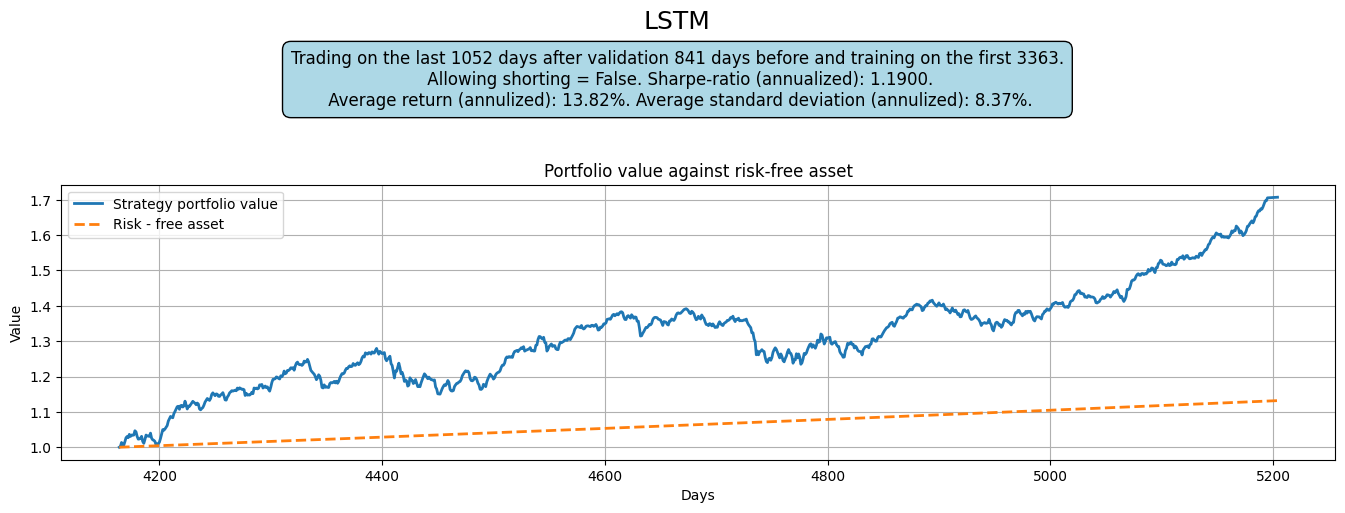

In [158]:
days = np.arange(5205-np.shape(returns_all)[0], 5205, 1)
returns_all_np = np.ones(np.shape(returns_all)[0])
k=1.
for i in range(1, np.shape(returns_all)[0]):
  k*= returns_all[i-1]
  returns_all_np[i] = k
  print(k)

if True:
  fig = plt.figure(figsize=(14,5))
  gs = fig.add_gridspec(1,1,height_ratios = [3], hspace = 0.4)

  fig.suptitle("LSTM", fontsize=18)

  sharp_text = (f"Trading on the last 1052 days after validation 841 days before and training on the first 3363.\n Allowing shorting = False. Sharpe-ratio (annualized): {1.19:.4f}.\n Average return (annulized): {0.1382:.2%}. Average standard deviation (annulized): {0.0837:.2%}.")

  fig.text(0.5, 0.9, sharp_text, fontsize = 12, ha = "center", va = "top", multialignment = "center", bbox = dict(facecolor = "lightblue",edgecolor = "black", boxstyle = "round,pad=0.5"))

  ax = fig.add_subplot(gs[0])
  ax.set_position([0.06, 0.08, 0.91, 0.55])
  ax.plot(days, returns_all_np, label = "Strategy portfolio value", linewidth = 2)
  risk_free = returns_all_np[0] * np.exp(0.03/252 * (days-days[0]))
  ax.plot(days, risk_free, label = "Risk - free asset", linestyle = "--", linewidth = 2)
  ax.set_title("Portfolio value against risk-free asset")
  ax.legend()
  ax.grid(True)
  ax.set_xlabel("Days")
  ax.set_ylabel("Value")
  plt.show()

# old

In [ ]:
"""
for name in finance_names:
  finance_data[name+"_t"] = (finance_data[name].shift(-1) / finance_data[name] ).astype(float)
training_data, test_data =  training_test_split(finance_data, part_slit=0.8)
training_data, valid_data =  training_test_split(training_data, part_slit=0.8)
"""

Index([1398, 1399, 1400, 1401, 1402, 1403, 1404, 1405, 1406, 1407,
       ...
       5446, 5447, 5448, 5449, 5450, 5451, 5452, 5453, 5454, 5455],
      dtype='int64', length=250)
0 5255
Index([1398, 1399, 1400, 1401, 1402, 1403, 1404, 1405, 1406, 1407, 1408, 1409,
       1410, 1411, 1412, 1413, 1414, 1415, 1416, 1417, 1418, 1419, 1420, 1421,
       1422, 1423, 1424, 1425, 1426, 1427, 1428, 1429, 1430, 1431, 1432, 1433,
       1434, 1435, 1436, 1437, 1438, 1439, 1440, 1441, 1442, 1443, 1444, 1445,
       1446, 1447],
      dtype='int64')
0 4204


In [ ]:
#print(test_data)

      Unnamed: 0   day     gurkor   guitars  slingshots    stocks     sugar  \
4204        4204  4205  11.157629  4.930754    3.084341  4.509189  1.854322   
4205        4205  4206  11.238734  4.863387    3.046735  4.401822  1.852360   
4206        4206  4207  11.243079  4.836440    3.007309  4.469612  1.830775   
4207        4207  4208  11.283631  4.715679    2.872653  4.524837  1.834700   
4208        4208  4209  11.277838  4.742626    2.901768  4.518365  1.789568   
...          ...   ...        ...       ...         ...       ...       ...   
5451        5451  5452        NaN       NaN         NaN       NaN       NaN   
5452        5452  5453        NaN       NaN         NaN       NaN       NaN   
5453        5453  5454        NaN       NaN         NaN       NaN       NaN   
5454        5454  5455        NaN       NaN         NaN       NaN       NaN   
5455        5455  5456        NaN       NaN         NaN       NaN       NaN   

         water  tranquillity  gurkor_t  guitars_t  

In [ ]:
"""
num_stocks = len(finance_names)
print(num_stocks)
stocks_name = finance_names

#creating torch tensors
train_data_input = [[] for i in range(num_stocks * (num_stocks-1) * 2)]
val_data_input = [[] for i in range(num_stocks * (num_stocks-1) * 2)]
test_data_input = [[] for i in range(num_stocks * (num_stocks-1) * 2)]

train_data_target = [[] for i in range(num_stocks * (num_stocks-1) * 2)]
val_data_target = [[] for i in range(num_stocks * (num_stocks-1) * 2)]
test_data_target = [[] for i in range(num_stocks * (num_stocks-1) * 2)]

for i, stock_name in enumerate(stocks_name):
  stocks2 = stocks_name.copy()
  stocks2.remove(stock_name)
  for j, stock_name2 in enumerate(stocks2):
    for k in range(2):
      train_data_input[2 * (i * (num_stocks - 1) + j) + k] = torch.tensor(combine_params(training_data, stock_name, stock_name2, k)[0], dtype=torch.float32)
      val_data_input[2 * (i * (num_stocks - 1) + j) + k] = torch.tensor(combine_params(valid_data, stock_name, stock_name2, 0)[0], dtype=torch.float32)
      test_data_input[2 * (i * (num_stocks - 1) + j) + k] = torch.tensor(combine_params(test_data, stock_name, stock_name2, 0)[0], dtype=torch.float32)


      train_data_target[2 * (i * (num_stocks - 1) + j) + k] = torch.tensor(combine_params(training_data, stock_name, stock_name2, k)[1], dtype=torch.float32)
      val_data_target[2 * (i * (num_stocks - 1) + j) + k] = torch.tensor(combine_params(valid_data, stock_name2, stock_name)[1], dtype=torch.float32)
      test_data_target[2 * (i * (num_stocks - 1) + j) + k]  = torch.tensor(combine_params(test_data, stock_name2, stock_name)[1], dtype=torch.float32)

      print(2 * (i * (num_stocks - 1) + j) + k)
  """

7
(197,) (197, 2)
	 gurkor (197, 2) (197,) 11
(841,) (841, 2)
	 gurkor (841, 2) (841,) 91
(1051,) (1051, 2)
	 gurkor (1051, 2) (1051,) 80
(197,) (197, 2)
	 gurkor (197, 2) (197,) 11
(841,) (841, 2)
	 guitars (841, 2) (841,) 261
(1051,) (1051, 2)
	 guitars (1051, 2) (1051,) 340
0
(3115,) (3115, 2)
	 gurkor (3115, 2) (3115,) 190
(841,) (841, 2)
	 gurkor (841, 2) (841,) 91
(1051,) (1051, 2)
	 gurkor (1051, 2) (1051,) 80
(3115,) (3115, 2)
	 gurkor (3115, 2) (3115,) 190
(841,) (841, 2)
	 guitars (841, 2) (841,) 261
(1051,) (1051, 2)
	 guitars (1051, 2) (1051,) 340
1
(197,) (197, 2)
	 gurkor (197, 2) (197,) 13
(841,) (841, 2)
	 gurkor (841, 2) (841,) 85
(1051,) (1051, 2)
	 gurkor (1051, 2) (1051,) 77
(197,) (197, 2)
	 gurkor (197, 2) (197,) 13
(841,) (841, 2)
	 slingshots (841, 2) (841,) 291
(1051,) (1051, 2)
	 slingshots (1051, 2) (1051,) 379
2
(3115,) (3115, 2)
	 gurkor (3115, 2) (3115,) 191
(841,) (841, 2)
	 gurkor (841, 2) (841,) 85
(1051,) (1051, 2)
	 gurkor (1051, 2) (1051,) 77
(3115,)

In [ ]:
# for inputs because raw inputs is very very very bad compared to also normilized
#train_data_normilized = [normalize_one_stock(stock_serie).detach() for stock_serie in train_data_input]
#val_data_normilized   = [normalize_one_stock(stock_serie).detach() for stock_serie in val_data_input]
#test_data_normilized  = [normalize_one_stock(stock_serie).detach() for stock_serie in test_data_input]

In [ ]:
#print(test_data_input, "\n", test_data_normilized)

[tensor([[11.1576,  4.9308],
        [11.2387,  4.8634],
        [11.2431,  4.8364],
        ...,
        [13.7986,  8.1341],
        [13.8003,  8.1915],
        [13.7736,  8.1238]]), tensor([[11.1576,  4.9308],
        [11.2387,  4.8634],
        [11.2431,  4.8364],
        ...,
        [13.7986,  8.1341],
        [13.8003,  8.1915],
        [13.7736,  8.1238]]), tensor([[11.1576,  3.0843],
        [11.2387,  3.0467],
        [11.2431,  3.0073],
        ...,
        [13.7986,  6.4060],
        [13.8003,  6.4443],
        [13.7736,  6.3710]]), tensor([[11.1576,  3.0843],
        [11.2387,  3.0467],
        [11.2431,  3.0073],
        ...,
        [13.7986,  6.4060],
        [13.8003,  6.4443],
        [13.7736,  6.3710]]), tensor([[11.1576,  4.5092],
        [11.2387,  4.4018],
        [11.2431,  4.4696],
        ...,
        [13.7986,  6.6779],
        [13.8003,  6.6556],
        [13.7736,  6.5933]]), tensor([[11.1576,  4.5092],
        [11.2387,  4.4018],
        [11.2431,  4.4696],


In [ ]:
"""
freq = np.array([(subpart.numpy()).sum() for subpart in train_data_target]).sum() / np.sum(np.array([(subpart.numpy()).shape[0] for subpart in train_data_target]))

print(freq)
model = LSTM6(input_size=2, size_hidden=12, dropout_layers_lstm=0., dropout_out=0.05, num_layers=1).to(device)

# compile it
if hasattr(torch, 'compile'):
    model = torch.compile(model)
    """

0.2139406487232574


In [ ]:
#gamma = 2 #decrease the freq of hotspot (higher weight on wrong hotspotatos%
#train_model(model, train_data_normilized, train_data_target, val_data_normilized, val_data_target, freq/gamma, num_epochs=20, learning_rate=0.001, seq_len = 10, decay=0.001)

/tmp/ipykernel_30499/2407525012.py:13: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler()
/tmp/ipykernel_30499/2407525012.py:49: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:49: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:49: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:58: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:58: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:49: UserWarning: CUDA is no

		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 1/20, Loss: 1.633, Val Loss: 1.629


/tmp/ipykernel_30499/2407525012.py:49: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):
/tmp/ipykernel_30499/2407525012.py:58: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):


		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 2/20, Loss: 1.592, Val Loss: 1.631
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 3/20, Loss: 1.589, Val Loss: 1.62
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 4/20, Loss: 1.586, Val Loss: 1.622
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 5/20, Loss: 1.589, Val Loss: 1.625
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 6/20, Loss: 1.589, Val Loss: 1.62
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84
		Stock 70/84
		Stock 80/84
Epoch 7/20, Loss: 1.586, Val Loss: 1.622
		Stock 10/84
		Stock 20/84
		Stock 30/84
		Stock 40/84
		Stock 50/84
		Stock 60/84


OptimizedModule(
  (_orig_mod): LSTM6(
    (lstm): LSTM(2, 12, batch_first=True)
    (norm): LayerNorm((12,), eps=1e-07, elementwise_affine=True)
    (fc): Linear(in_features=12, out_features=1, bias=True)
    (dropout): Dropout(p=0.05, inplace=False)
  )
)

In [ ]:
#for theta in np.arange(0.69, 0.7, 0.0001):
#  total_profit = 0
#  total_days= 0
#  total_updates = 0
##  avg_profit = 0
#  for i in range(num_stocks):
##    sum_profit, updates, _ = predict_avg_return_on_investment(model, val_data_normilized[i], val_data_input[i], threshold=theta, batch_size=1, seq_len=10)
#    total_profit += sum_profit
#
#    avg_profit += sum_profit/(val_data_normilized[i].size(0)-9)
##
#    total_days += val_data_normilized[i].size(0)-9
#    total_updates += updates
#
#  avg_profit_per_stock = avg_profit/num_stocks
#  ROI_day = total_profit/total_days
#  ROI_trade = total_profit/total_updates
#
#  print(f"{theta:.4f}\tROI_per day   \t\t", ROI_day)
##  print(f"{theta:.4f}\tROI_per trade \t\t", ROI_trade)
#  print("ROI_per day averaging stock \t",   avg_profit_per_stock)

0.6900	ROI_per day   		 0.00024975877
0.6900	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6901	ROI_per day   		 0.00024975877
0.6901	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6902	ROI_per day   		 0.00024975877
0.6902	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6903	ROI_per day   		 0.00024975877
0.6903	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6904	ROI_per day   		 0.00024975877
0.6904	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6905	ROI_per day   		 0.00024975877
0.6905	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6906	ROI_per day   		 0.00024975877
0.6906	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6907	ROI_per day   		 0.00024975877
0.6907	ROI_per trade 		 0.0002531092
ROI_per day averaging stock 	 0.00024975874
0.6908	ROI_per day   		 0.00024975877
0.6908	ROI

/tmp/ipykernel_30499/253134971.py:17: RuntimeWarning: invalid value encountered in scalar divide
  ROI_trade = total_profit/total_updates


0.6929	ROI_per day   		 0.0
0.6929	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6930	ROI_per day   		 0.0
0.6930	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6931	ROI_per day   		 0.0
0.6931	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6932	ROI_per day   		 0.0
0.6932	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6933	ROI_per day   		 0.0
0.6933	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6934	ROI_per day   		 0.0
0.6934	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6935	ROI_per day   		 0.0
0.6935	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6936	ROI_per day   		 0.0
0.6936	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6937	ROI_per day   		 0.0
0.6937	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6938	ROI_per day   		 0.0
0.6938	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6939	ROI_per day   		 0.0
0.6939	ROI_per trade 		 nan
ROI_per day averaging stock 	 0.0
0.6940	ROI

KeyboardInterrupt: 

In [ ]:
"""
ROI_day_per_company = [0,0]
ROI_day = [0,0]
ROI_trade = [0,0]
Trade_freq = [0,0]
for idx, theta in enumerate([0, 0.6927]):
  total_profit = 0
  total_days= 0
  total_updates = 0
  avg_profit = 0
  returns_all = np.array([])
  for i in range(num_stocks):
    sum_profit, updates, returns = predict_avg_return_on_investment(model, test_data_normilized[i], test_data_input[i], threshold=theta, batch_size=1, seq_len=10)
    total_profit += sum_profit.sum()
    avg_profit += sum_profit/(test_data_normilized[i].size(0)-10)
    total_days += test_data_normilized[i].size(0)-10
    total_updates += updates
    returns_all = np.concatenate((returns_all, returns))

  print(np.mean(returns_all - ((1.03)**(1/252)-1))/np.std(returns_all - ((1.03)**(1/252)-1)))

  ROI_day[idx] = total_profit/total_days

  ROI_day_per_company[idx] = avg_profit/num_stocks

  ROI_trade[idx] = total_profit/total_updates
  Trade_freq[idx] = total_updates/total_days

print("Test data day:")
print(f"           \t    return per day     return per trade    return per day per stock      trading freq")
print(f"invest all days  \t{ROI_day[0]*100:.3f} % \t{ROI_trade[0]*100:.3f} % \t\t {ROI_day_per_company[0]*100:.3f}% \t\t{Trade_freq[0]:.2f}x")
print(f"invest with rules\t{ROI_day[1]*100:.3f} % \t{ROI_trade[1]*100:.3f} % \t\t {ROI_day_per_company[1]*100:.3f}% \t\t{Trade_freq[1]:.2f}x")
days = val_data_normilized[i].size(0)+1

print("\n\nTest data (yearly returns) :")
print(f"           \t    return per year     return per trade    return per day per stock      trading freq")
print(f"invest all days  \t{(1+ROI_day[0])**days *100-100:.3f} % \t{(1+ROI_trade[0])**days *100-100:.3f} % \t\t {(1+ROI_day_per_company[0])**days *100-100:.3f}% \t\t{Trade_freq[0]:.2f}x")
print(f"invest with rules\t{(1+ROI_day[1])**days *100-100:.3f} % \t{(1+ ROI_trade[1])**days *100-100:.3f} % \t\t {(1+ ROI_day_per_company[1])**days *100-100:.3f}% \t\t{Trade_freq[1]:.2f}x")
"""

0.027682533586499303
0.14776123494099633
Test data day:
           	    return per day     return per trade    return per day per stock      trading freq
invest all days  	0.022 % 	0.022 % 		 0.022% 		1.00x
invest with rules	0.023 % 	0.023 % 		 0.023% 		0.98x


Test data (yearly returns) :
           	    return per year     return per trade    return per day per stock      trading freq
invest all days  	20.207 % 	20.207 % 		 20.207% 		1.00x
invest with rules	21.102 % 	21.613 % 		 21.102% 		0.98x
